In [ ]:
# Step 1: Import required libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning, UndefinedMetricWarning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from scipy.optimize import differential_evolution

warnings.filterwarnings(
    "ignore",
    message="'force_all_finite' was renamed to 'ensure_all_finite'",
)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [2]:
# Step 2: Load the dataset
data_path = 'final_preprocessed_data.csv'
if not Path(data_path).is_file():
    raise FileNotFoundError(f"Dataset not found at {data_path}. Please ensure the file is in the project directory.")
data = pd.read_csv(data_path)

# Display the first few rows of the dataset for inspection
data.head()


,Unnamed: 0,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,...,MONTH_3,MONTH_4,MONTH_5,MONTH_6,MONTH_7,MONTH_8,MONTH_9,MONTH_10,MONTH_11,MONTH_12
0,0,44.0,2,2,5.0,71.0,90.0,41.0,240.0,0.0,...,0,0,0,0,0,0,0,0,1,0
1,1,40.0,2,3,6.0,106.0,128.0,82.0,572.0,0.0,...,0,0,0,0,1,0,0,0,0,0
2,2,17.0,3,4,9.0,243.0,270.0,244.0,1475.0,10.0,...,0,0,1,0,0,0,0,0,0,0
3,3,60.0,2,2,3.0,75.0,104.0,41.0,240.0,0.0,...,0,0,0,0,0,0,0,0,0,1
4,4,33.0,4,4,5.0,98.0,118.0,80.0,572.0,0.0,...,0,0,0,0,0,0,0,0,1,0


In [3]:
data['FLIGHT_STATUS'].value_counts()

FLIGHT_STATUS
0    43239
1    43239
Name: count, dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86478 entries, 0 to 86477
Columns: 219 entries, Unnamed: 0 to MONTH_12
dtypes: float64(15), int64(204)
memory usage: 144.5 MB


In [ ]:
# Step 3: Split data into features (X) and target (y)
X = data.drop('FLIGHT_STATUS', axis=1)  # Replace 'FLIGHT_STATUS' if the actual target column name differs
y = data['FLIGHT_STATUS']

# Remove constant (zero-variance) features to avoid warnings during feature selection
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping {len(constant_cols)} constant feature(s) before scaling.")
    X = X.drop(columns=constant_cols)

# Step 4: Preprocessing - Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [6]:
# Step 5: Feature Selection using ANOVA
# Select the top 20 features using ANOVA
selector = SelectKBest(score_func=f_classif, k=20)  # Adjust 'k' as needed
X_selected = selector.fit_transform(X_scaled, y)

# Check which features were selected
selected_features = X.columns[selector.get_support()]
print("Selected Features:")
print(selected_features)


Selected Features:
Index(['TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ELAPSED_TIME',
       'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'CARRIER_DELAY', 'NAS_DELAY',
       'LATE_AIRCRAFT_DELAY', 'origin_humidity', 'dest_humidity',
       'OP_CARRIER_Southwest Airlines', 'origin_city_new york',
       'origin_condition_text_Sunny', 'dest_condition_text_Sunny',
       'CRS_DEP_TIME_2', 'CRS_DEP_TIME_4', 'CRS_ARR_TIME_2', 'CRS_ARR_TIME_4'],
      dtype='object')


C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [44 53 99] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [7]:
# Step 6: Clustering using DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust eps and min_samples as needed
clusters = dbscan.fit_predict(X_selected)

# Add cluster information to the original dataframe
X['Cluster'] = clusters

# Display the number of samples in each cluster
print(X['Cluster'].value_counts())


Cluster
-1       17542
 8        4189
 18       3059
 4        2597
 0        2447
         ...  
 463         4
 1461        4
 1517        3
 1512        3
 1521        3
Name: count, Length: 1551, dtype: int64


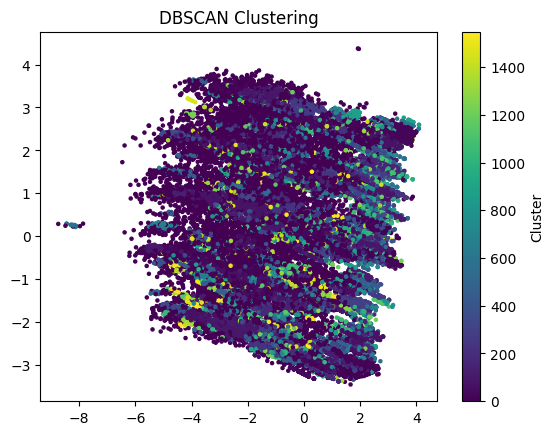

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=5)
plt.colorbar(label='Cluster')
plt.title('DBSCAN Clustering')
plt.show()


In [9]:
from sklearn.cluster import DBSCAN
import numpy as np

# Iterate through different eps and min_samples values
for eps in [0.3, 0.4, 0.5, 0.6]:
    for min_samples in [3, 5, 7]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X_selected)
        num_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        print(f"eps: {eps}, min_samples: {min_samples}, Number of clusters: {num_clusters}")


eps: 0.3, min_samples: 3, Number of clusters: 4295


eps: 0.3, min_samples: 5, Number of clusters: 2457


eps: 0.3, min_samples: 7, Number of clusters: 1495


eps: 0.4, min_samples: 3, Number of clusters: 3098


eps: 0.4, min_samples: 5, Number of clusters: 1874


...

eps: 0.5, min_samples: 5, Number of clusters: 1550


eps: 0.5, min_samples: 7, Number of clusters: 1062


eps: 0.6, min_samples: 3, Number of clusters: 1790


eps: 0.6, min_samples: 5, Number of clusters: 1219


eps: 0.6, min_samples: 7, Number of clusters: 863


In [10]:
import hdbscan

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5)
clusters = hdbscan_model.fit_predict(X_selected)
print(f"Number of clusters: {len(set(clusters)) - (1 if -1 in clusters else 0)}")


C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Number of clusters: 3450


In [11]:
# Add HDBSCAN clusters to the feature set for analysis
X['Cluster'] = clusters
X['Cluster'].value_counts().head()

Cluster
-1       16172
 819      2516
 3053     1754
 2901     1753
 108      1193
Name: count, dtype: int64

Cluster
-1      36363
 17      2492
 8       1935
 0       1529
 73      1257
        ...  
 903        7
 907        7
 918        7
 222        7
 858        6
Name: count, Length: 924, dtype: int64


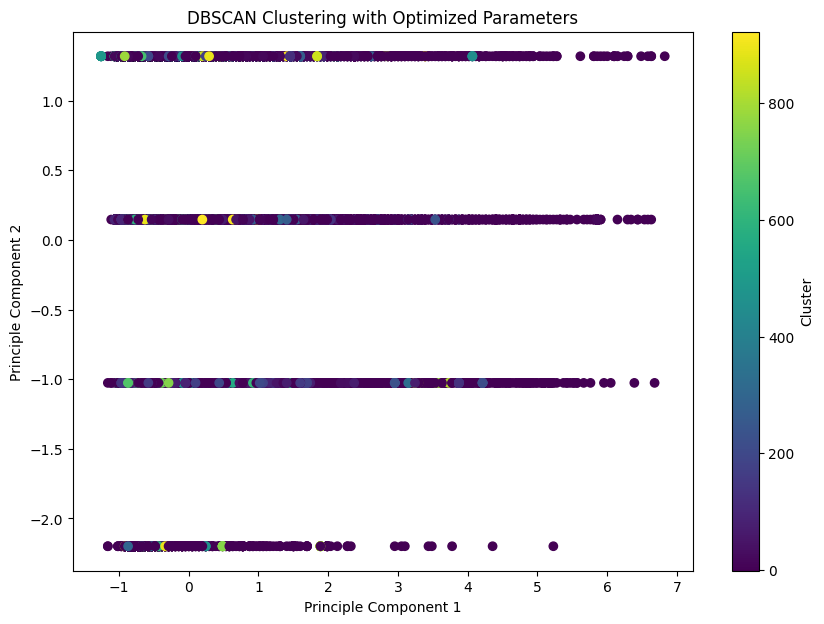

In [12]:
from sklearn.cluster import DBSCAN
import numpy as np

# Optimized DBSCAN parameters
dbscan = DBSCAN(eps=0.4, min_samples=10)  # Adjusted eps and min_samples
clusters = dbscan.fit_predict(X_selected)

# Add cluster information to the original dataframe
X['Cluster'] = clusters

# Display the number of samples in each cluster
print(X['Cluster'].value_counts())

# Visualize the clusters
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_selected[:, 0], X_selected[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter, label='Cluster')
plt.title('DBSCAN Clustering with Optimized Parameters')
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')
plt.show()


In [13]:
X.head()

,Unnamed: 0,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,...,MONTH_4,MONTH_5,MONTH_6,MONTH_7,MONTH_8,MONTH_9,MONTH_10,MONTH_11,MONTH_12,Cluster
0,0,44.0,2,2,5.0,71.0,90.0,41.0,240.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,1,40.0,2,3,6.0,106.0,128.0,82.0,572.0,0.0,...,0,0,0,1,0,0,0,0,0,1
2,2,17.0,3,4,9.0,243.0,270.0,244.0,1475.0,10.0,...,0,1,0,0,0,0,0,0,0,739
3,3,60.0,2,2,3.0,75.0,104.0,41.0,240.0,0.0,...,0,0,0,0,0,0,0,0,1,2
4,4,33.0,4,4,5.0,98.0,118.0,80.0,572.0,0.0,...,0,0,0,0,0,0,0,1,0,3


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


def build_stratified_kfold(y_values, max_splits=5):
    class_counts = pd.Series(y_values).value_counts()
    if len(class_counts) < 2:
        return None
    min_count = int(class_counts.min())
    if min_count < 2:
        return None
    n_splits = min(max_splits, min_count)
    if n_splits < 2:
        return None
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)


# Iterate through each cluster for training
for cluster in np.unique(clusters):
    if cluster == -1:
        continue  # Skip the noise points

    # Filter data for the current cluster
    X_cluster = X_selected[clusters == cluster]
    y_cluster = y[clusters == cluster]  # Replace `y` with the appropriate target variable

    skf = build_stratified_kfold(y_cluster)
    if skf is None:
        print(
            f"Cluster {cluster} does not have enough samples per class for stratified CV. Skipping..."
        )
        continue

    models = [
        ("RandomForest", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("LogisticRegression", LogisticRegression(max_iter=500, C=0.1, penalty="l2", random_state=42)),
    ]

    for model_name, model in models:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=FitFailedWarning)
                warnings.simplefilter("ignore", category=UndefinedMetricWarning)
                scores = cross_val_score(model, X_cluster, y_cluster, cv=skf, scoring="accuracy")
        except ValueError as err:
            print(f"Cluster {cluster} ({model_name}) - cross-validation failed: {err}. Skipping...")
            continue

        print(
            f"Cluster {cluster} ({model_name}) - Mean cross-validation accuracy: {np.mean(scores):.4f}"
        )
        model.fit(X_cluster, y_cluster)
        print(f"Trained {model_name} model for cluster {cluster}")



Cluster 0 - Mean cross-validation accuracy: 1.0000
Trained model for cluster 0
Cluster 0 - Mean cross-validation accuracy: 0.9529
Trained model for cluster 0
Cluster 1 has only one class in the target variable. Skipping...
Cluster 2 has only one class in the target variable. Skipping...


Cluster 3 - Mean cross-validation accuracy: 1.0000
Trained model for cluster 3
Cluster 3 - Mean cross-validation accuracy: 0.9620
Trained model for cluster 3
Cluster 4 has only one class in the target variable. Skipping...
Cluster 5 has only one class in the target variable. Skipping...
Cluster 6 has only one class in the target variable. Skipping...


Cluster 7 - Mean cross-validation accuracy: 0.9367
Trained model for cluster 7
Cluster 7 - Mean cross-validation accuracy: 0.6550
Trained model for cluster 7


Cluster 8 - Mean cross-validation accuracy: 1.0000
Trained model for cluster 8
Cluster 8 - Mean cross-validation accuracy: 0.9121
Trained model for cluster 8
Cluster 9 has only one class in the target variable. Skipping...


Cluster 10 - Mean cross-validation accuracy: 1.0000
Trained model for cluster 10
Cluster 10 - Mean cross-validation accuracy: 0.8765
Trained model for cluster 10
Cluster 11 has only one class in the target variable. Skipping...
Cluster 12 has only one class in the target variable. Skipping...


...

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\

Cluster 921 - Mean cross-validation accuracy: 0.9000
Trained model for cluster 921
Cluster 921 - Mean cross-validation accuracy: nan
Trained model for cluster 921


C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\

Cluster 922 - Mean cross-validation accuracy: 0.6000
Trained model for cluster 922
Cluster 922 - Mean cross-validation accuracy: 0.7000
Trained model for cluster 922


C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Cluster 0 - Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       281
           1       1.00      0.85      0.92       178

    accuracy                           0.94       459
   macro avg       0.96      0.93      0.94       459
weighted avg       0.95      0.94      0.94       459



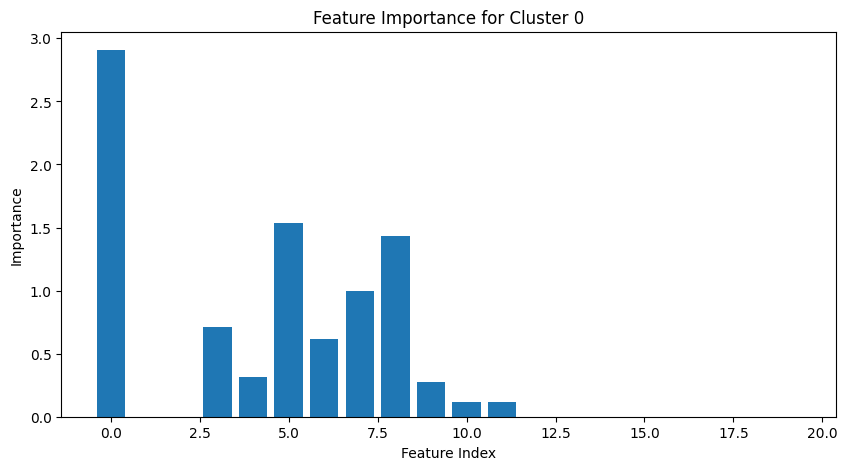

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 1 does not have enough samples for stratified splitting. Skipping...
Cluster 2 does not have enough samples for stratified splitting. Skipping...
Cluster 3 - Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       281
           1       0.00      0.00      0.00        11

    accuracy                           0.96       292
   macro avg       0.48      0.50      0.49       292
weighted avg       0.93      0.96      0.94       292



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


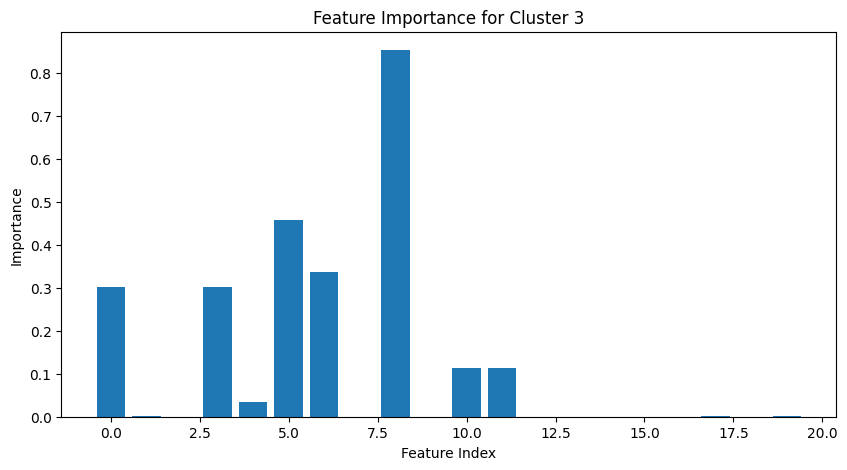

Cluster 4 does not have enough samples for stratified splitting. Skipping...
Cluster 5 does not have enough samples for stratified splitting. Skipping...
Cluster 6 does not have enough samples for stratified splitting. Skipping...
Cluster 7 - Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.62      1.00      0.77        15

    accuracy                           0.62        24
   macro avg       0.31      0.50      0.38        24
weighted avg       0.39      0.62      0.48        24



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

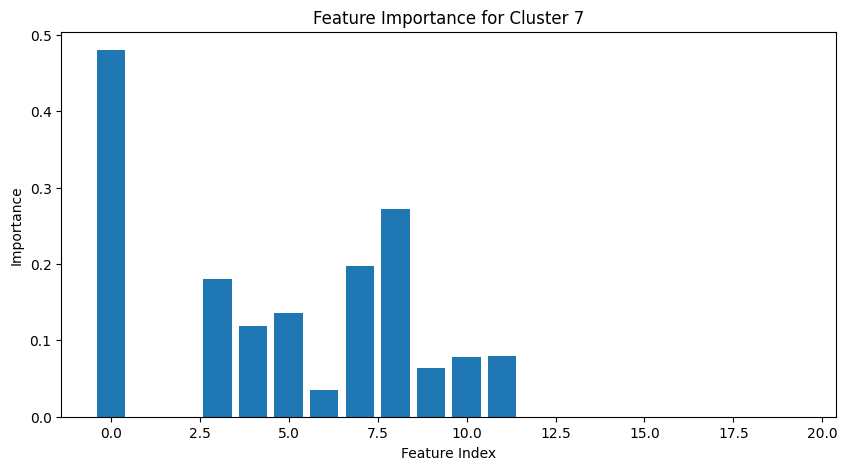

Cluster 8 - Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       328
           1       1.00      0.80      0.89       253

    accuracy                           0.91       581
   macro avg       0.93      0.90      0.91       581
weighted avg       0.93      0.91      0.91       581



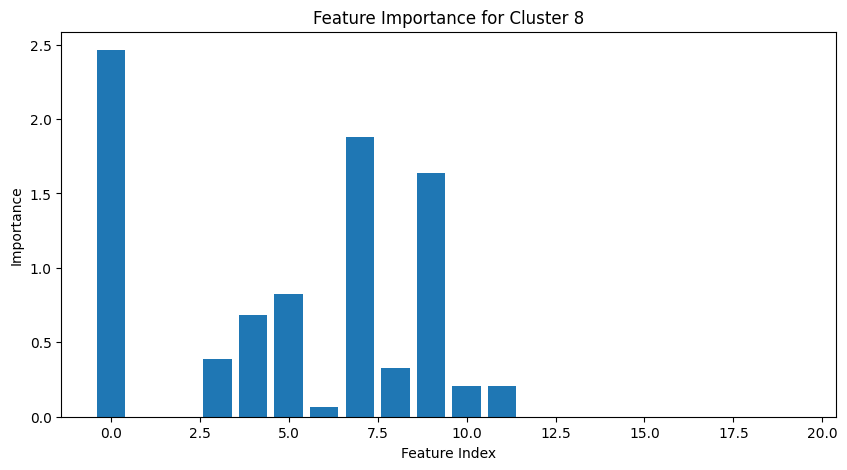

Cluster 9 does not have enough samples for stratified splitting. Skipping...


Cluster 10 - Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        47
           1       0.00      0.00      0.00         7

    accuracy                           0.87        54
   macro avg       0.44      0.50      0.47        54
weighted avg       0.76      0.87      0.81        54



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

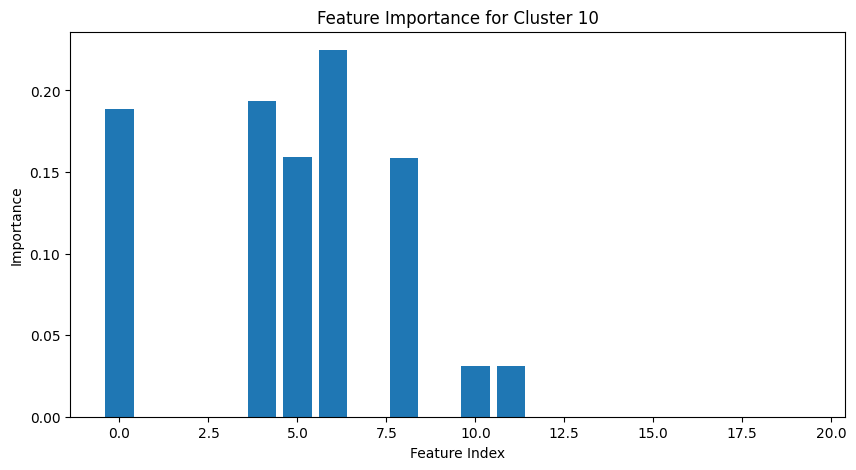

Cluster 11 does not have enough samples for stratified splitting. Skipping...
Cluster 12 does not have enough samples for stratified splitting. Skipping...
Cluster 13 - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00       140

    accuracy                           1.00       187
   macro avg       1.00      1.00      1.00       187
weighted avg       1.00      1.00      1.00       187



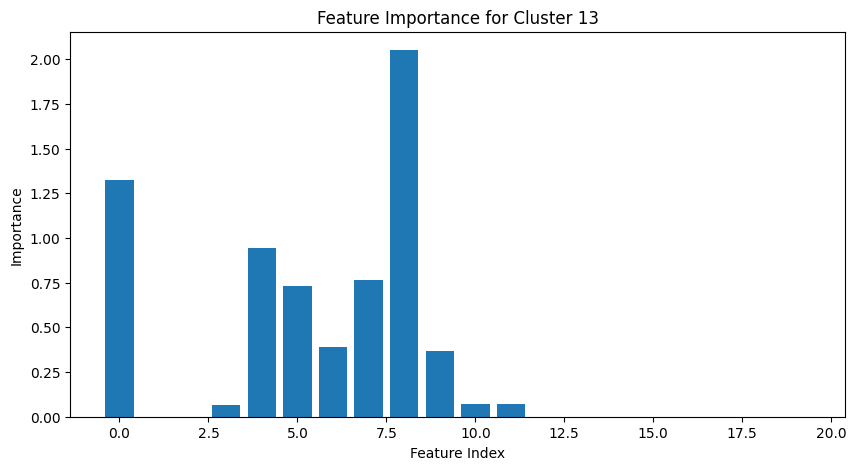

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 14 does not have enough samples for stratified splitting. Skipping...
Cluster 15 - Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       188
           1       0.00      0.00      0.00         3

    accuracy                           0.98       191
   macro avg       0.49      0.50      0.50       191
weighted avg       0.97      0.98      0.98       191



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


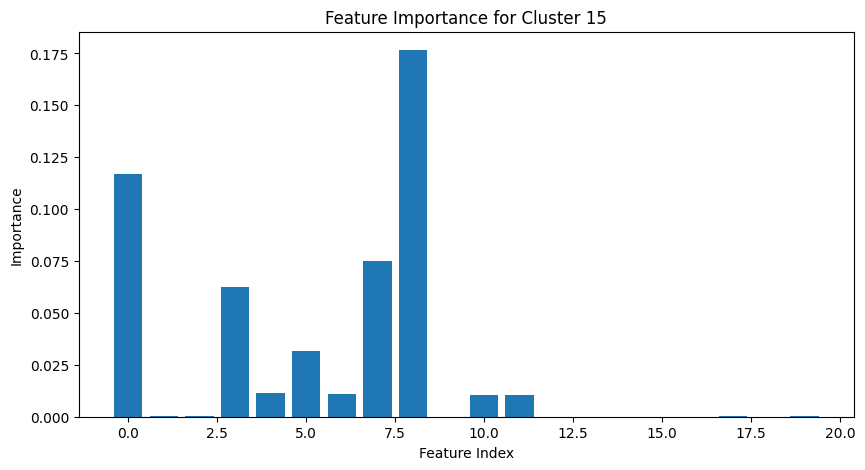

Cluster 16 does not have enough samples for stratified splitting. Skipping...
Cluster 17 does not have enough samples for stratified splitting. Skipping...
Cluster 18 does not have enough samples for stratified splitting. Skipping...
Cluster 19 does not have enough samples for stratified splitting. Skipping...
Cluster 20 does not have enough samples for stratified splitting. Skipping...
Cluster 21 does not have enough samples for stratified splitting. Skipping...
Cluster 22 does not have enough samples for stratified splitting. Skipping...
Cluster 23 - Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        37
           1       0.00      0.00      0.00         5

    accuracy                           0.88        42
   macro avg       0.44      0.50      0.47        42
weighted avg       0.78      0.88      0.83        42



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

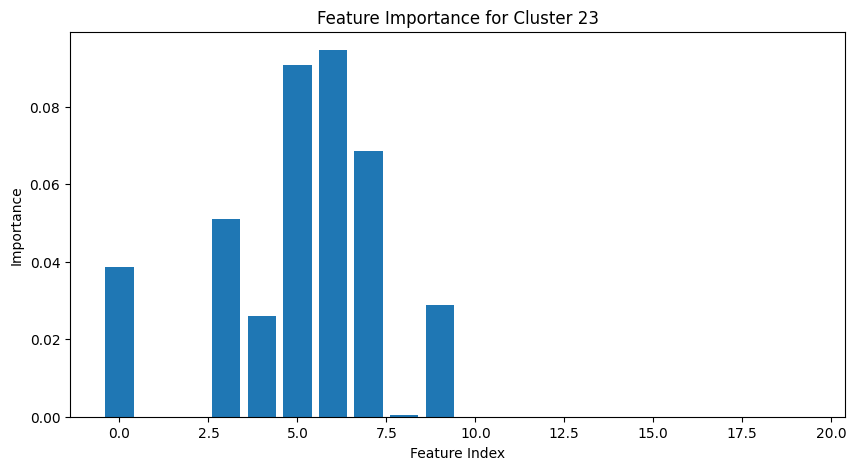

Cluster 24 - Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       0.00      0.00      0.00         1

    accuracy                           0.86         7
   macro avg       0.43      0.50      0.46         7
weighted avg       0.73      0.86      0.79         7



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

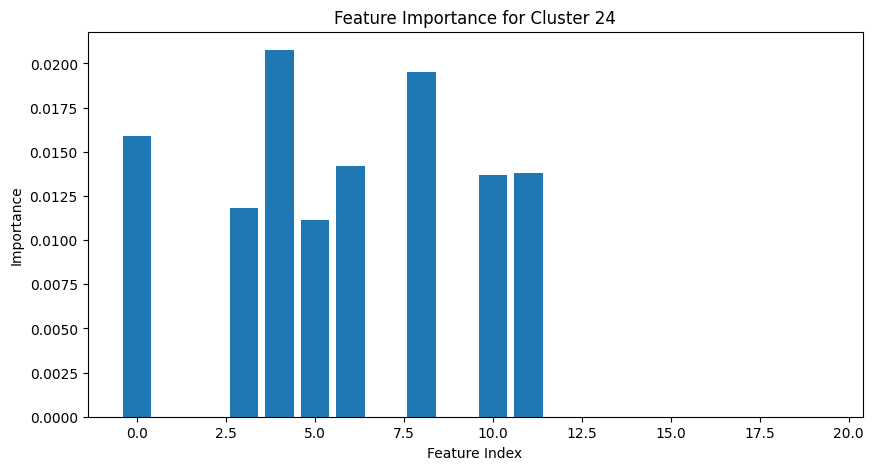

Cluster 25 - Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        29
           1       0.00      0.00      0.00         5

    accuracy                           0.85        34
   macro avg       0.43      0.50      0.46        34
weighted avg       0.73      0.85      0.79        34



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

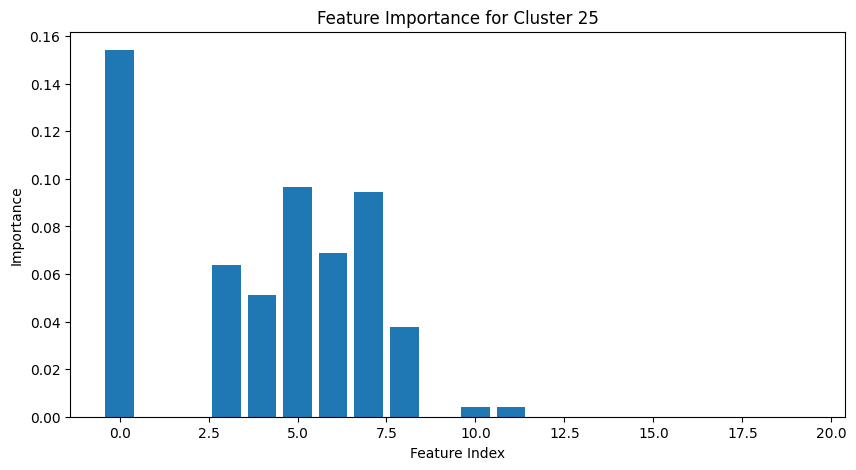

Cluster 26 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

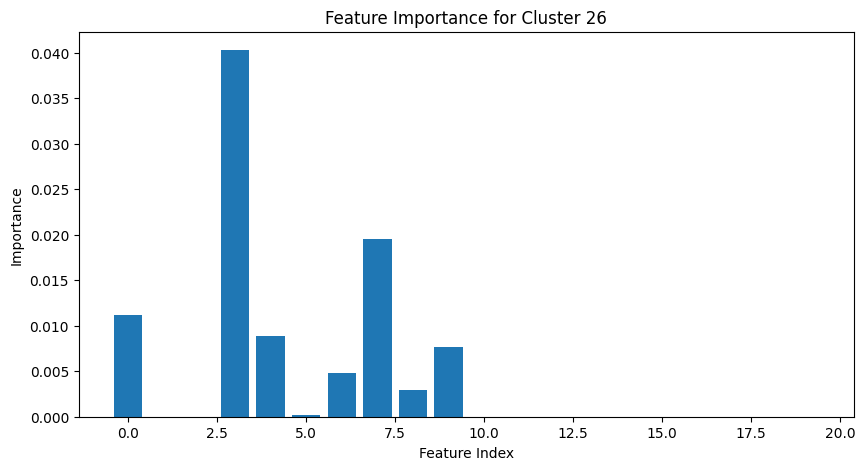

Cluster 27 does not have enough samples for stratified splitting. Skipping...
Cluster 28 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89       118
           1       0.69      0.27      0.39        33

    accuracy                           0.81       151
   macro avg       0.76      0.62      0.64       151
weighted avg       0.80      0.81      0.78       151



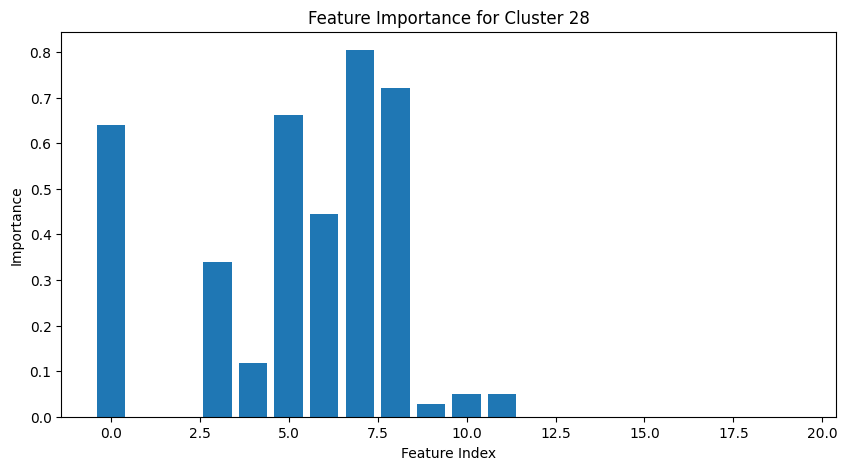

Cluster 29 does not have enough samples for stratified splitting. Skipping...
Cluster 30 - Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       141
           1       0.00      0.00      0.00         4

    accuracy                           0.97       145
   macro avg       0.49      0.50      0.49       145
weighted avg       0.95      0.97      0.96       145



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

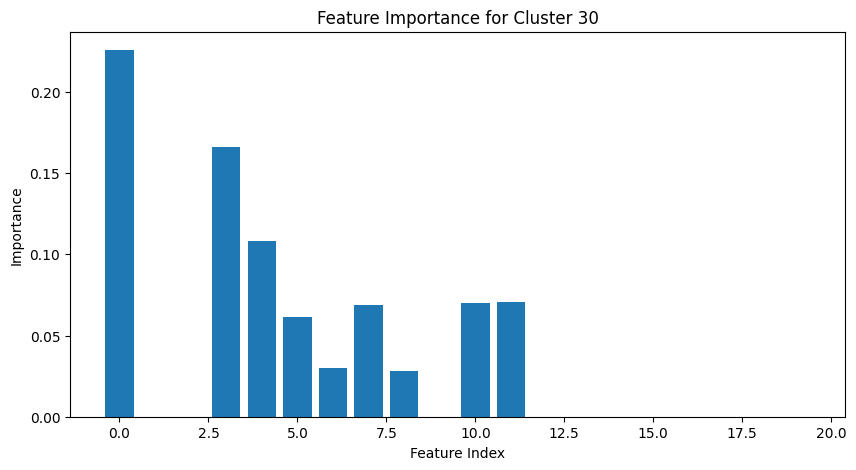

Cluster 31 does not have enough samples for stratified splitting. Skipping...
Cluster 32 - Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       0.00      0.00      0.00         1

    accuracy                           0.86         7
   macro avg       0.43      0.50      0.46         7
weighted avg       0.73      0.86      0.79         7



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

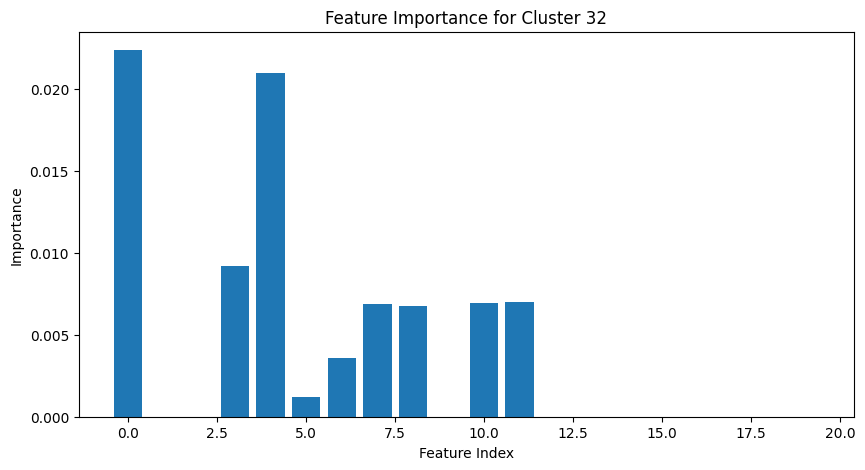

Cluster 33 - Classification Report:

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio


              precision    recall  f1-score   support

           0       0.92      1.00      0.96        47
           1       0.00      0.00      0.00         4

    accuracy                           0.92        51
   macro avg       0.46      0.50      0.48        51
weighted avg       0.85      0.92      0.88        51



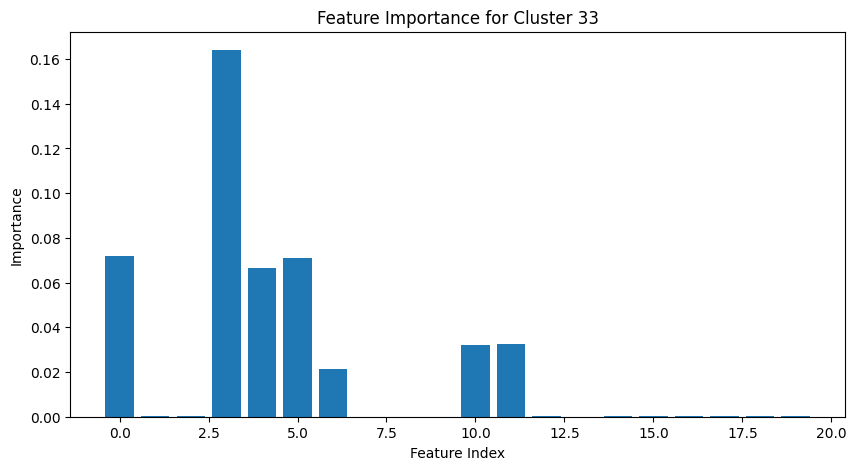

Cluster 34 does not have enough samples for stratified splitting. Skipping...
Cluster 35 does not have enough samples for stratified splitting. Skipping...
Cluster 36 does not have enough samples for stratified splitting. Skipping...
Cluster 37 - Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

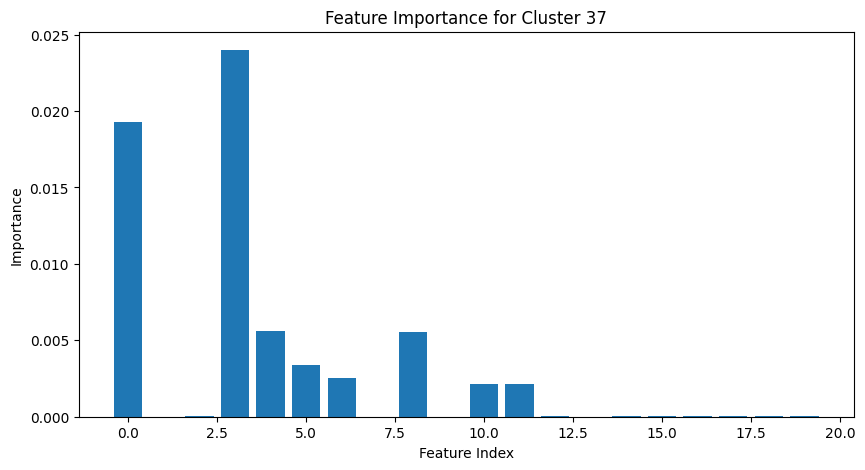

Cluster 38 does not have enough samples for stratified splitting. Skipping...
Cluster 39 does not have enough samples for stratified splitting. Skipping...
Cluster 40 does not have enough samples for stratified splitting. Skipping...
Cluster 41 does not have enough samples for stratified splitting. Skipping...
Cluster 42 does not have enough samples for stratified splitting. Skipping...
Cluster 43 does not have enough samples for stratified splitting. Skipping...
Cluster 44 - Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        47
           1       0.00      0.00      0.00         4

    accuracy                           0.92        51
   macro avg       0.46      0.50      0.48        51
weighted avg       0.85      0.92      0.88        51



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

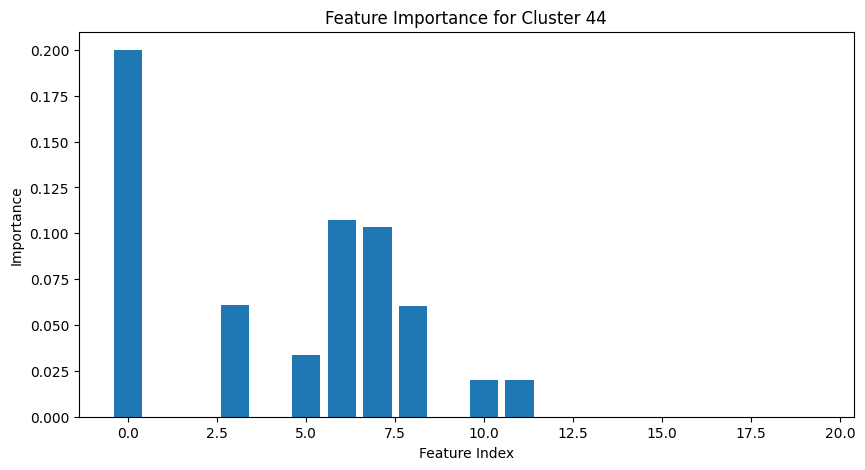

Cluster 45 does not have enough samples for stratified splitting. Skipping...


Cluster 46 - Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        79
           1       0.00      0.00      0.00         8

    accuracy                           0.91        87
   macro avg       0.45      0.50      0.48        87
weighted avg       0.82      0.91      0.86        87



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

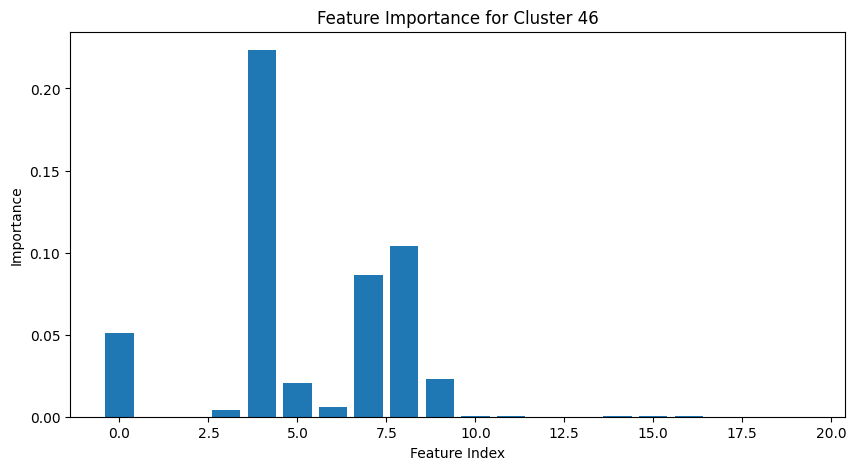

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 47 does not have enough samples for stratified splitting. Skipping...
Cluster 48 does not have enough samples for stratified splitting. Skipping...
Cluster 49 does not have enough samples for stratified splitting. Skipping...
Cluster 50 - Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        47
           1       0.00      0.00      0.00         5

    accuracy                           0.90        52
   macro avg       0.45      0.50      0.47        52
weighted avg       0.82      0.90      0.86        52



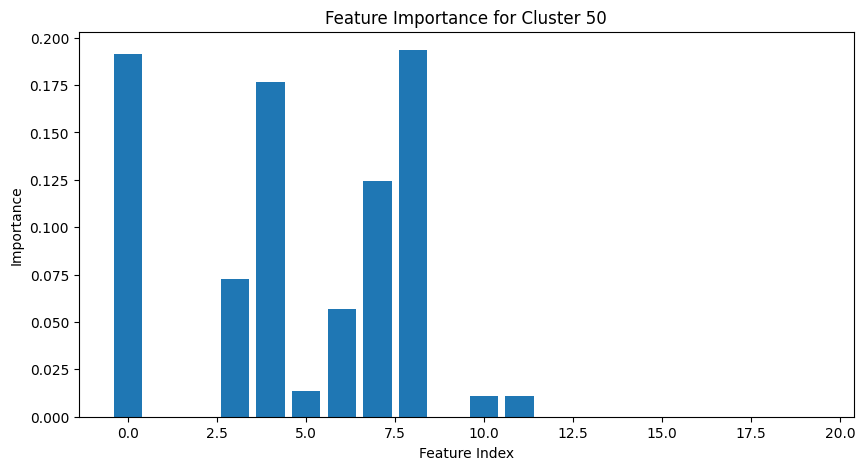

Cluster 51 - Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       144
           1       0.00      0.00      0.00         7

    accuracy                           0.95       151
   macro avg       0.48      0.50      0.49       151
weighted avg       0.91      0.95      0.93       151



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

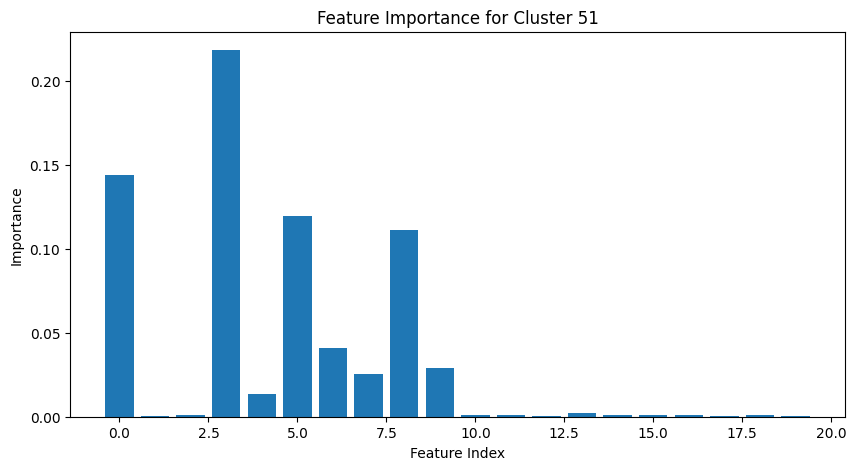

Cluster 52 does not have enough samples for stratified splitting. Skipping...
Cluster 53 does not have enough samples for stratified splitting. Skipping...
Cluster 54 does not have enough samples for stratified splitting. Skipping...
Cluster 55 does not have enough samples for stratified splitting. Skipping...
Cluster 56 - Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       230
           1       0.81      0.42      0.55        50

    accuracy                           0.88       280
   macro avg       0.85      0.70      0.74       280
weighted avg       0.87      0.88      0.86       280



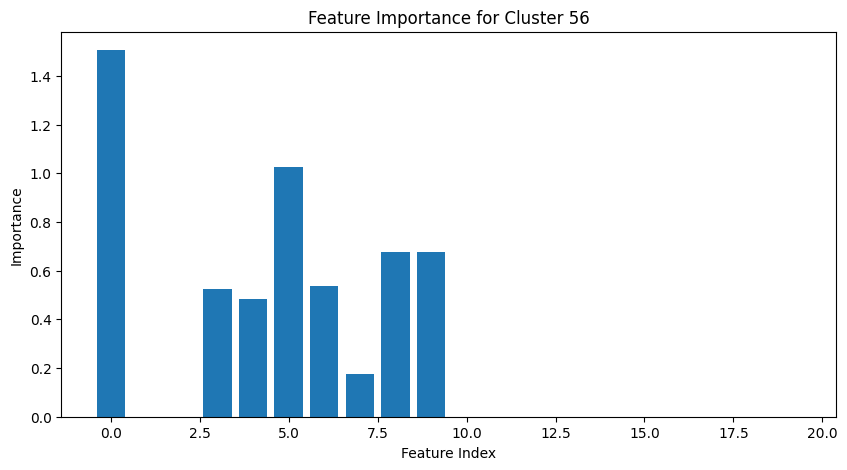

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 57 does not have enough samples for stratified splitting. Skipping...
Cluster 58 does not have enough samples for stratified splitting. Skipping...
Cluster 59 does not have enough samples for stratified splitting. Skipping...
Cluster 60 does not have enough samples for stratified splitting. Skipping...
Cluster 61 does not have enough samples for stratified splitting. Skipping...
Cluster 62 does not have enough samples for stratified splitting. Skipping...
Cluster 63 does not have enough samples for stratified splitting. Skipping...
Cluster 64 - Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        56
           1       0.00      0.00      0.00         4

    accuracy                           0.93        60
   macro avg       0.47      0.50      0.48        60
weighted avg       0.87      0.93      0.90        60



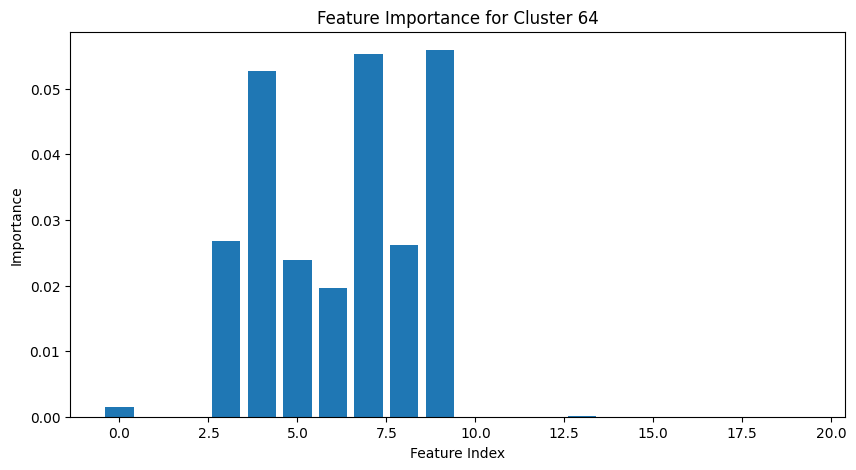

Cluster 65 does not have enough samples for stratified splitting. Skipping...
Cluster 66 does not have enough samples for stratified splitting. Skipping...
Cluster 67 does not have enough samples for stratified splitting. Skipping...
Cluster 68 - Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        44
           1       0.00      0.00      0.00         3

    accuracy                           0.94        47
   macro avg       0.47      0.50      0.48        47
weighted avg       0.88      0.94      0.91        47



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

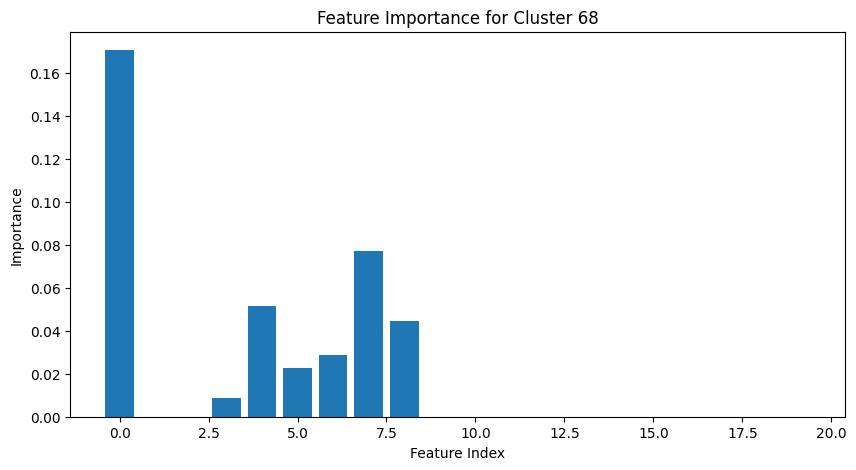

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 69 does not have enough samples for stratified splitting. Skipping...
Cluster 70 - Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        50
           1       0.00      0.00      0.00         2

    accuracy                           0.96        52
   macro avg       0.48      0.50      0.49        52
weighted avg       0.92      0.96      0.94        52



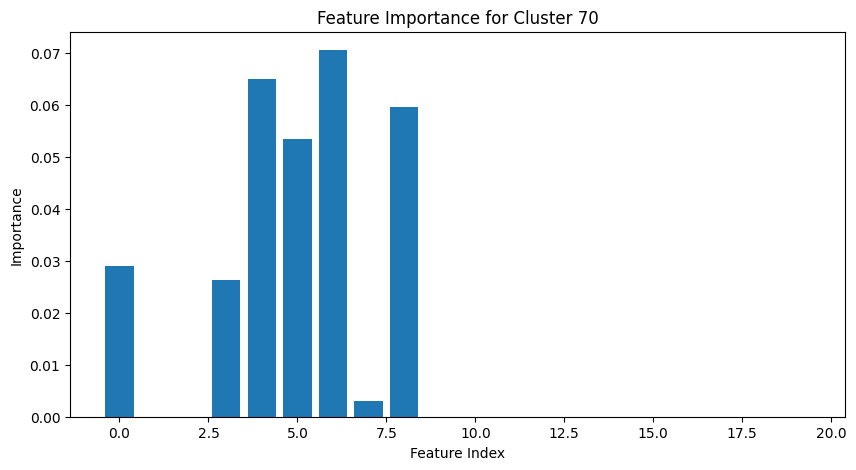

Cluster 71 does not have enough samples for stratified splitting. Skipping...

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio


Cluster 72 - Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        68
           1       0.00      0.00      0.00        17

    accuracy                           0.80        85
   macro avg       0.40      0.50      0.44        85
weighted avg       0.64      0.80      0.71        85



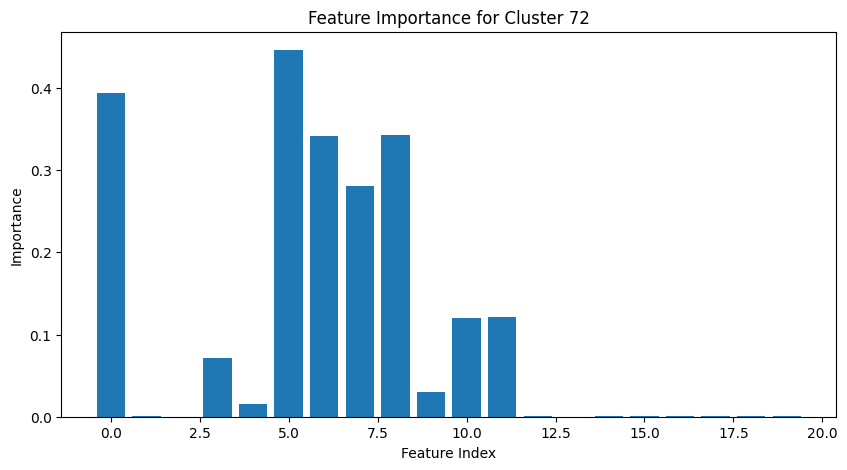

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 73 - Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       358
           1       0.00      0.00      0.00        20

    accuracy                           0.95       378
   macro avg       0.47      0.50      0.49       378
weighted avg       0.90      0.95      0.92       378



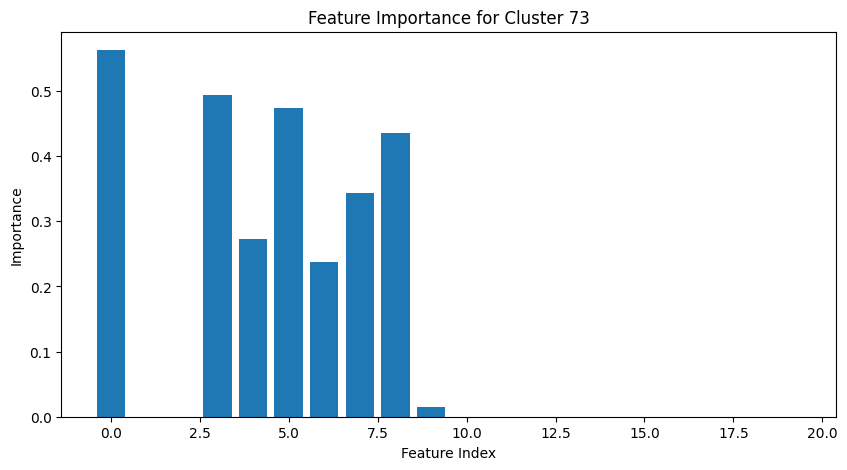

Cluster 74 does not have enough samples for stratified splitting. Skipping...
Cluster 75 - Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        47
           1       0.00      0.00      0.00         5

    accuracy                           0.90        52
   macro avg       0.45      0.50      0.47        52
weighted avg       0.82      0.90      0.86        52



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

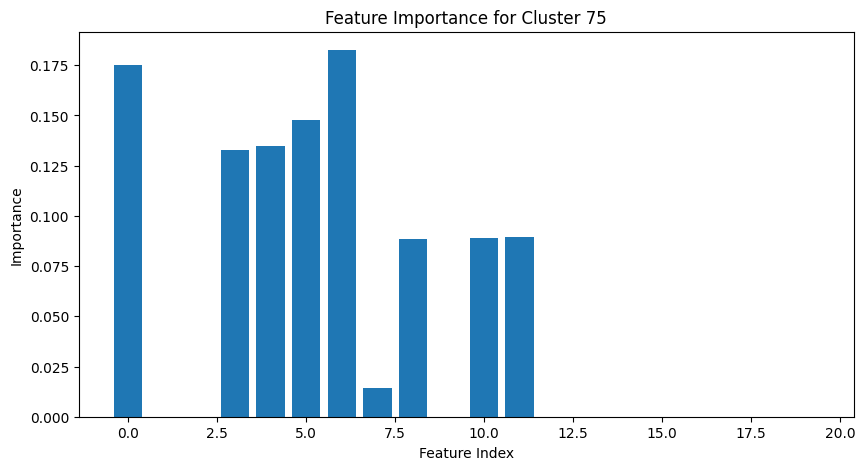

Cluster 76 does not have enough samples for stratified splitting. Skipping...
Cluster 77 does not have enough samples for stratified splitting. Skipping...
Cluster 78 does not have enough samples for stratified splitting. Skipping...
Cluster 79 does not have enough samples for stratified splitting. Skipping...
Cluster 80 does not have enough samples for stratified splitting. Skipping...
Cluster 81 does not have enough samples for stratified splitting. Skipping...
Cluster 82 does not have enough samples for stratified splitting. Skipping...
Cluster 83 - Classification Report:


C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        43
           1       0.00      0.00      0.00         2

    accuracy                           0.96        45
   macro avg       0.48      0.50      0.49        45
weighted avg       0.91      0.96      0.93        45



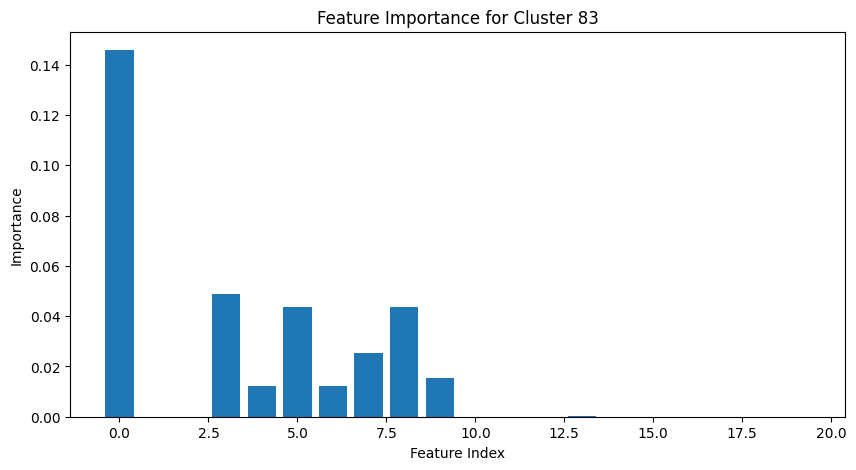

Cluster 84 does not have enough samples for stratified splitting. Skipping...
Cluster 85 does not have enough samples for stratified splitting. Skipping...
Cluster 86 - Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       105
           1       0.00      0.00      0.00        14

    accuracy                           0.88       119
   macro avg       0.44      0.50      0.47       119
weighted avg       0.78      0.88      0.83       119



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

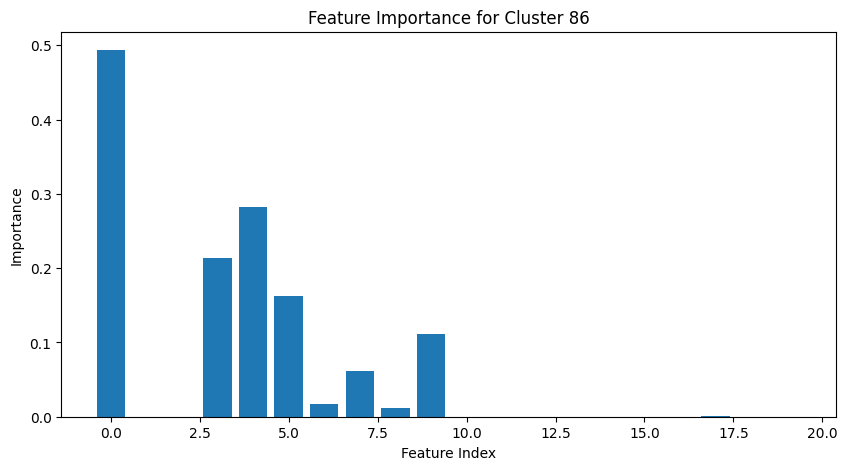

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 87 does not have enough samples for stratified splitting. Skipping...
Cluster 88 - Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        36
           1       0.00      0.00      0.00         2

    accuracy                           0.95        38
   macro avg       0.47      0.50      0.49        38
weighted avg       0.90      0.95      0.92        38



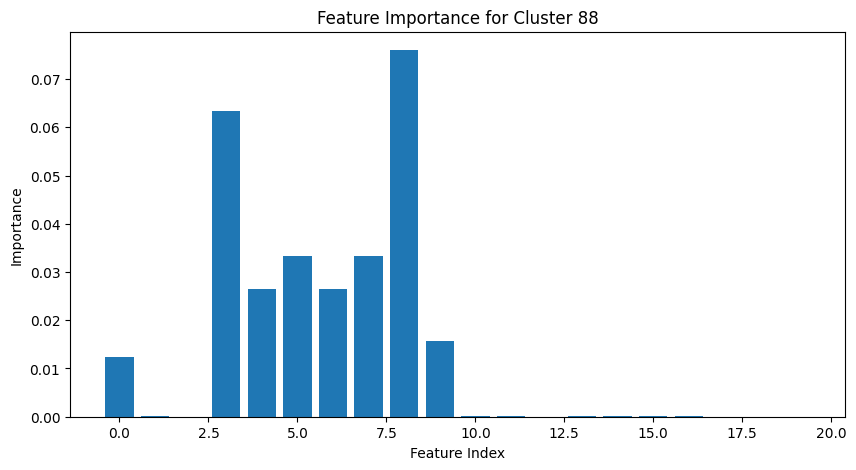

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 89 does not have enough samples for stratified splitting. Skipping...
Cluster 90 does not have enough samples for stratified splitting. Skipping...
Cluster 91 does not have enough samples for stratified splitting. Skipping...
Cluster 92 does not have enough samples for stratified splitting. Skipping...
Cluster 93 does not have enough samples for stratified splitting. Skipping...
Cluster 94 does not have enough samples for stratified splitting. Skipping...
Cluster 95 does not have enough samples for stratified splitting. Skipping...
Cluster 96 does not have enough samples for stratified splitting. Skipping...
Cluster 97 does not have enough samples for stratified splitting. Skipping...
Cluster 98 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        94
           1       0.00      0.00      0.00        19

    accuracy                           0.83       113
   macro avg       0.42      0.50      0.45 

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


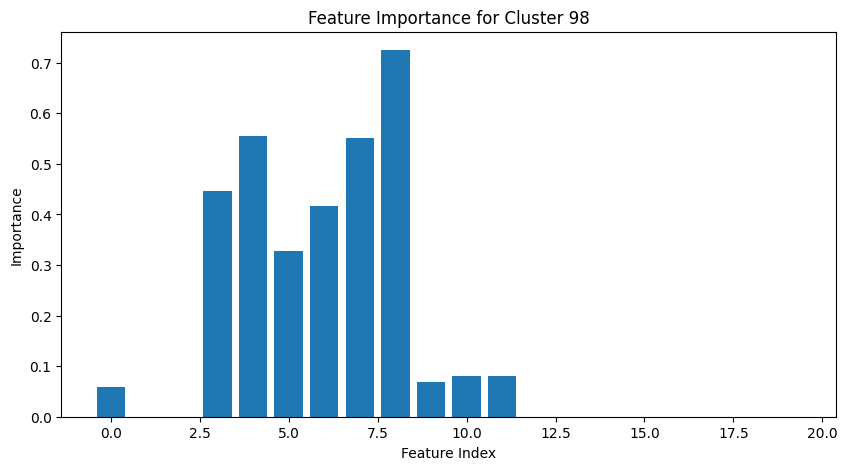

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 99 does not have enough samples for stratified splitting. Skipping...
Cluster 100 does not have enough samples for stratified splitting. Skipping...
Cluster 101 does not have enough samples for stratified splitting. Skipping...
Cluster 102 - Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        14
           1       0.00      0.00      0.00         2

    accuracy                           0.88        16
   macro avg       0.44      0.50      0.47        16
weighted avg       0.77      0.88      0.82        16



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


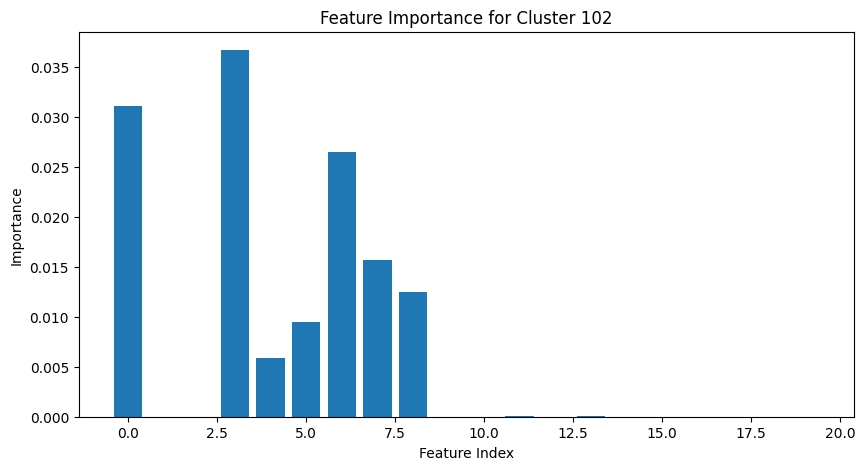

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 103 does not have enough samples for stratified splitting. Skipping...
Cluster 104 does not have enough samples for stratified splitting. Skipping...
Cluster 105 - Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        94
           1       0.00      0.00      0.00         4

    accuracy                           0.96        98
   macro avg       0.48      0.50      0.49        98
weighted avg       0.92      0.96      0.94        98



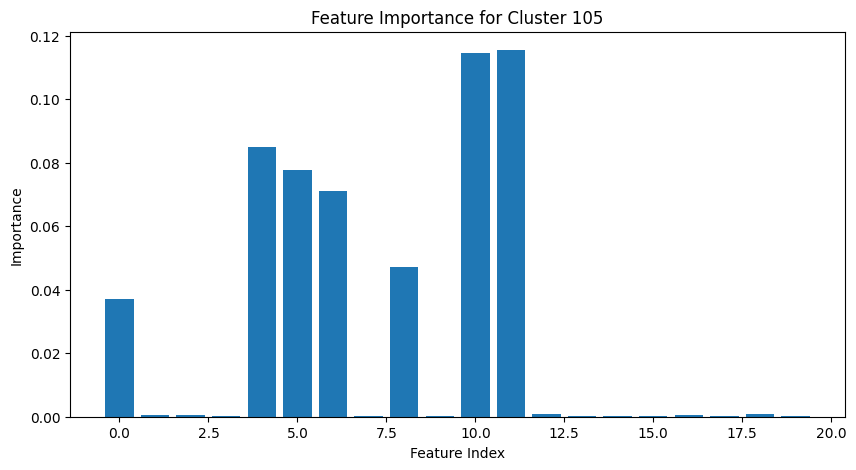

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 106 does not have enough samples for stratified splitting. Skipping...
Cluster 107 does not have enough samples for stratified splitting. Skipping...
Cluster 108 does not have enough samples for stratified splitting. Skipping...
Cluster 109 does not have enough samples for stratified splitting. Skipping...
Cluster 110 does not have enough samples for stratified splitting. Skipping...
Cluster 111 does not have enough samples for stratified splitting. Skipping...
Cluster 112 does not have enough samples for stratified splitting. Skipping...
Cluster 113 does not have enough samples for stratified splitting. Skipping...
Cluster 114 does not have enough samples for stratified splitting. Skipping...
Cluster 115 does not have enough samples for stratified splitting. Skipping...
Cluster 116 - Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       187
           1       0.00      0.00      0.00         2

    accur

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


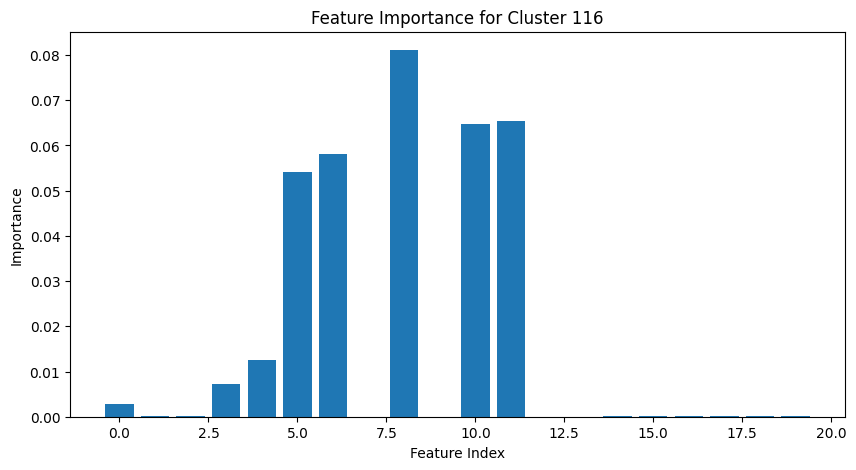

Cluster 117 does not have enough samples for stratified splitting. Skipping...
Cluster 118 does not have enough samples for stratified splitting. Skipping...
Cluster 119 does not have enough samples for stratified splitting. Skipping...
Cluster 120 does not have enough samples for stratified splitting. Skipping...
Cluster 121 does not have enough samples for stratified splitting. Skipping...
Cluster 122 does not have enough samples for stratified splitting. Skipping...
Cluster 123 - Classification Report:


C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.00      0.00      0.00         1

    accuracy                           0.97        37
   macro avg       0.49      0.50      0.49        37
weighted avg       0.95      0.97      0.96        37



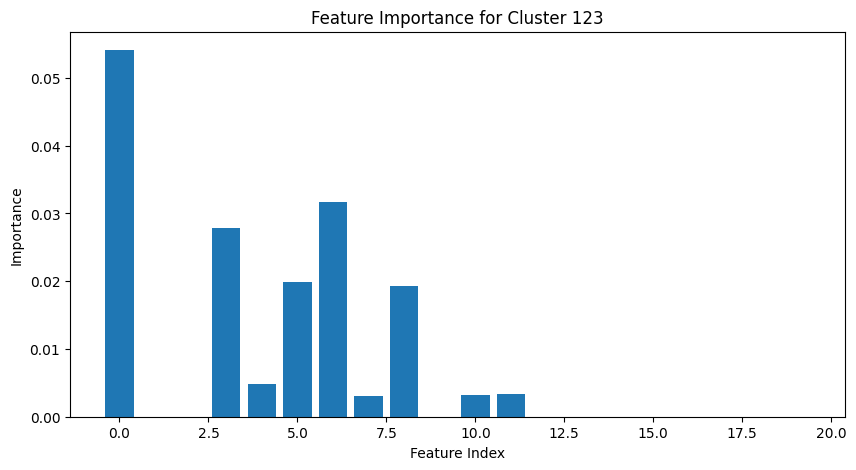

Cluster 124 - Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.86      1.00      0.93        50

    accuracy                           0.86        58
   macro avg       0.43      0.50      0.46        58
weighted avg       0.74      0.86      0.80        58



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

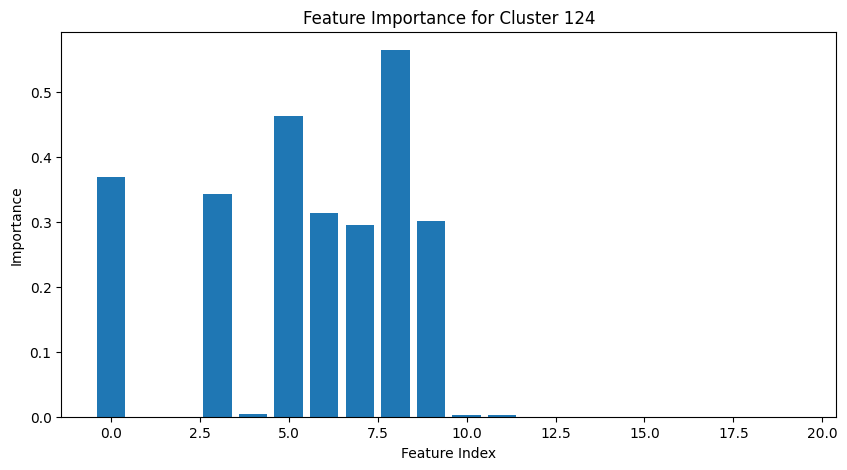

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 125 does not have enough samples for stratified splitting. Skipping...
Cluster 126 does not have enough samples for stratified splitting. Skipping...
Cluster 127 does not have enough samples for stratified splitting. Skipping...
Cluster 128 - Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.76      1.00      0.86        34

    accuracy                           0.76        45
   macro avg       0.38      0.50      0.43        45
weighted avg       0.57      0.76      0.65        45



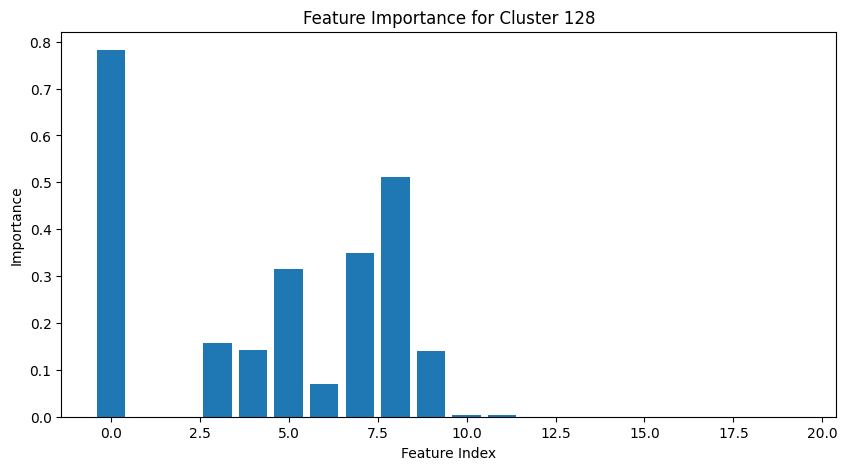

Cluster 129 does not have enough samples for stratified splitting. Skipping...
Cluster 130 does not have enough samples for stratified splitting. Skipping...
Cluster 131 does not have enough samples for stratified splitting. Skipping...
Cluster 132 does not have enough samples for stratified splitting. Skipping...
Cluster 133 does not have enough samples for stratified splitting. Skipping...
Cluster 134 does not have enough samples for stratified splitting. Skipping...
Cluster 135 does not have enough samples for stratified splitting. Skipping...
Cluster 136 does not have enough samples for stratified splitting. Skipping...
Cluster 137 does not have enough samples for stratified splitting. Skipping...
Cluster 138 does not have enough samples for stratified splitting. Skipping...
Cluster 139 does not have enough samples for stratified splitting. Skipping...
Cluster 140 - Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

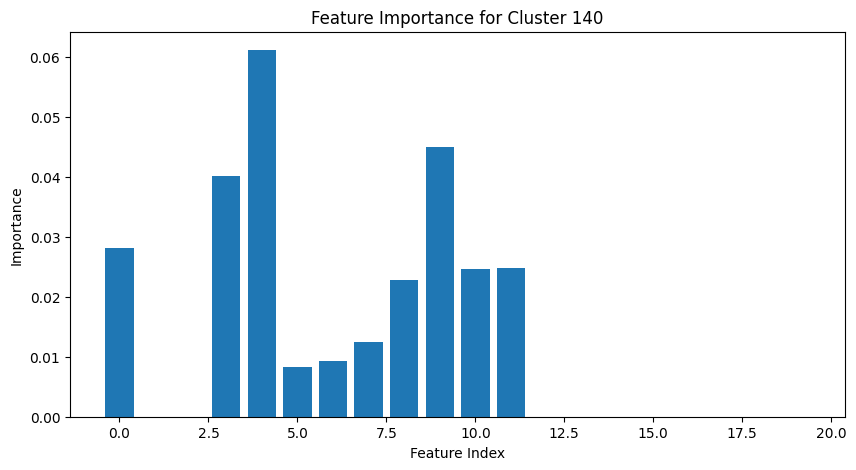

Cluster 141 does not have enough samples for stratified splitting. Skipping...
Cluster 142 does not have enough samples for stratified splitting. Skipping...
Cluster 143 does not have enough samples for stratified splitting. Skipping...
Cluster 144 does not have enough samples for stratified splitting. Skipping...
Cluster 145 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

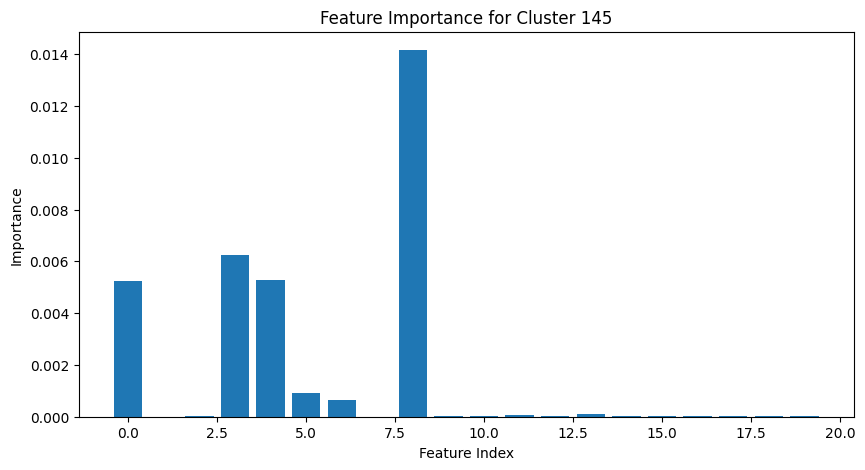

Cluster 146 does not have enough samples for stratified splitting. Skipping...
Cluster 147 does not have enough samples for stratified splitting. Skipping...
Cluster 148 - Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       0.00      0.00      0.00         1

    accuracy                           0.86         7
   macro avg       0.43      0.50      0.46         7
weighted avg       0.73      0.86      0.79         7



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

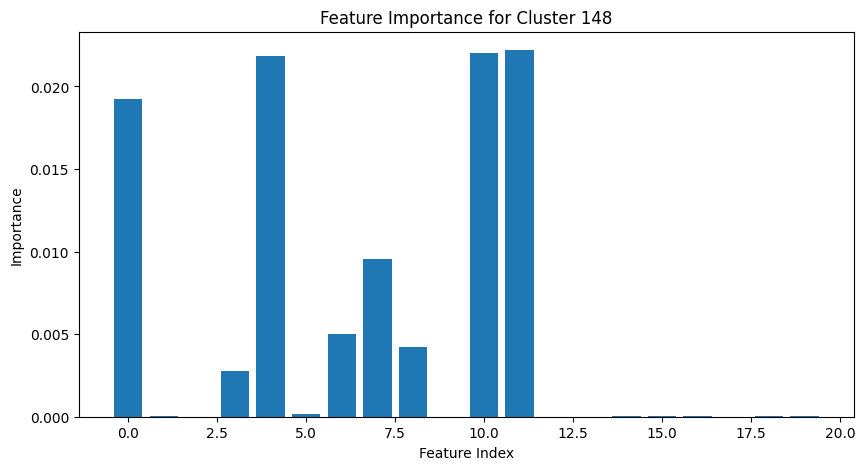

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 149 does not have enough samples for stratified splitting. Skipping...
Cluster 150 does not have enough samples for stratified splitting. Skipping...
Cluster 151 does not have enough samples for stratified splitting. Skipping...
Cluster 152 does not have enough samples for stratified splitting. Skipping...
Cluster 153 does not have enough samples for stratified splitting. Skipping...
Cluster 154 does not have enough samples for stratified splitting. Skipping...
Cluster 155 does not have enough samples for stratified splitting. Skipping...
Cluster 156 does not have enough samples for stratified splitting. Skipping...
Cluster 157 - Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        47
           1       0.00      0.00      0.00         4

    accuracy                           0.92        51
   macro avg       0.46      0.50      0.48        51
weighted avg       0.85      0.92      0.88        51



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


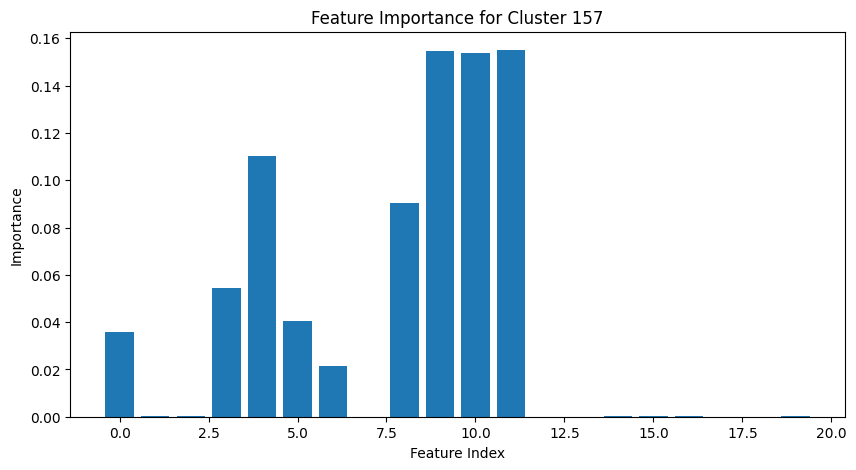

Cluster 158 - Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        51
           1       0.00      0.00      0.00         1

    accuracy                           0.98        52
   macro avg       0.49      0.50      0.50        52
weighted avg       0.96      0.98      0.97        52



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

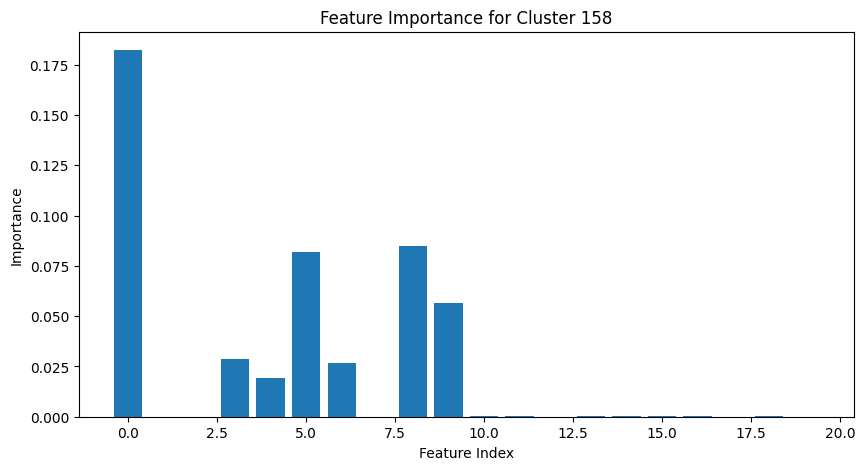

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 159 does not have enough samples for stratified splitting. Skipping...
Cluster 160 does not have enough samples for stratified splitting. Skipping...
Cluster 161 does not have enough samples for stratified splitting. Skipping...
Cluster 162 - Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       0.00      0.00      0.00         1

    accuracy                           0.95        19
   macro avg       0.47      0.50      0.49        19
weighted avg       0.90      0.95      0.92        19



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


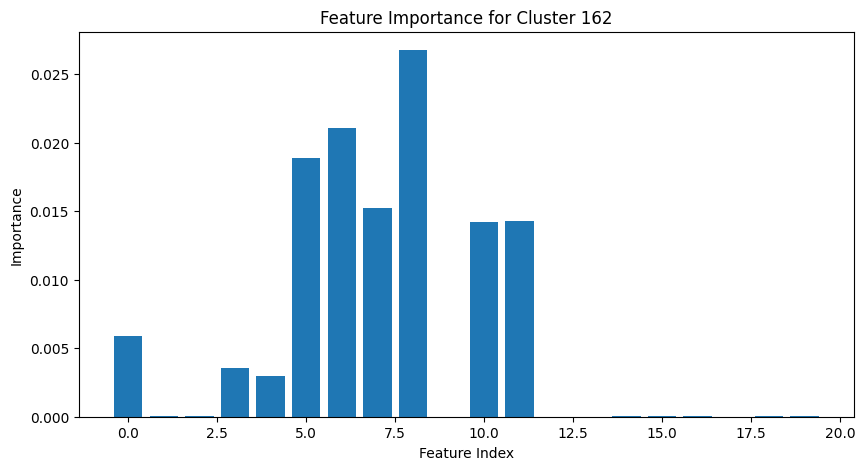

Cluster 163 does not have enough samples for stratified splitting. Skipping...
Cluster 164 - Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        94
           1       0.00      0.00      0.00         3

    accuracy                           0.97        97
   macro avg       0.48      0.50      0.49        97
weighted avg       0.94      0.97      0.95        97



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

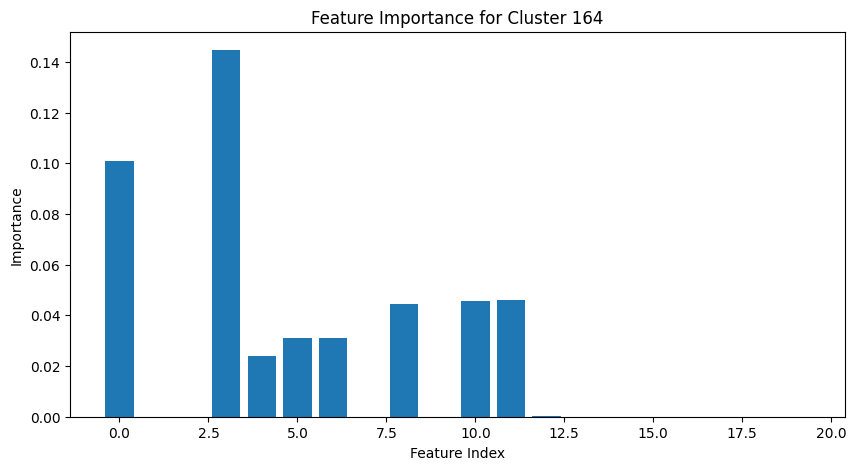

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 165 - Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         9
           1       0.00      0.00      0.00         3

    accuracy                           0.75        12
   macro avg       0.38      0.50      0.43        12
weighted avg       0.56      0.75      0.64        12



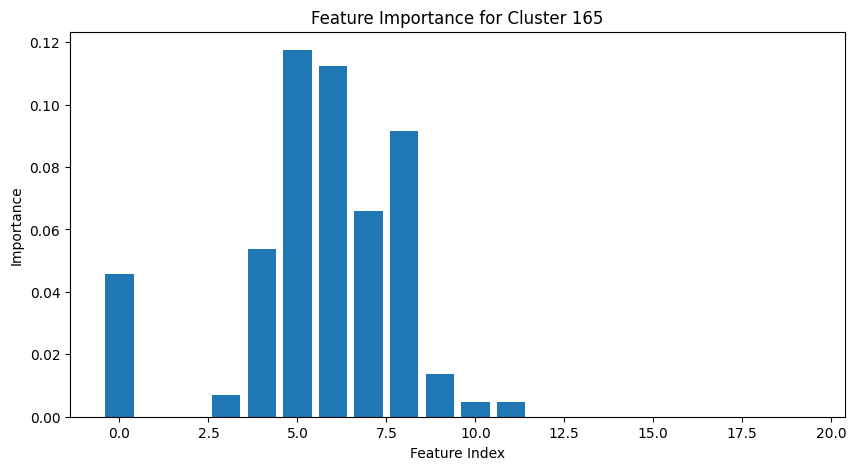

Cluster 166 does not have enough samples for stratified splitting. Skipping...
Cluster 167 does not have enough samples for stratified splitting. Skipping...
Cluster 168 does not have enough samples for stratified splitting. Skipping...
Cluster 169 - Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        36
           1       1.00      0.57      0.73        21

    accuracy                           0.84        57
   macro avg       0.90      0.79      0.81        57
weighted avg       0.87      0.84      0.83        57



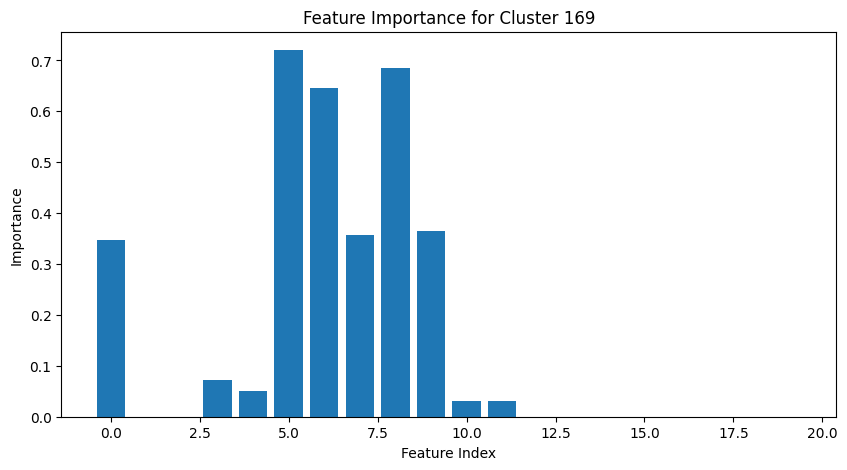

Cluster 170 does not have enough samples for stratified splitting. Skipping...
Cluster 171 does not have enough samples for stratified splitting. Skipping...
Cluster 172 does not have enough samples for stratified splitting. Skipping...
Cluster 173 does not have enough samples for stratified splitting. Skipping...
Cluster 174 does not have enough samples for stratified splitting. Skipping...
Cluster 175 does not have enough samples for stratified splitting. Skipping...
Cluster 176 does not have enough samples for stratified splitting. Skipping...
Cluster 177 does not have enough samples for stratified splitting. Skipping...
Cluster 178 does not have enough samples for stratified splitting. Skipping...
Cluster 179 does not have enough samples for stratified splitting. Skipping...
Cluster 180 does not have enough samples for stratified splitting. Skipping...
Cluster 181 - Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

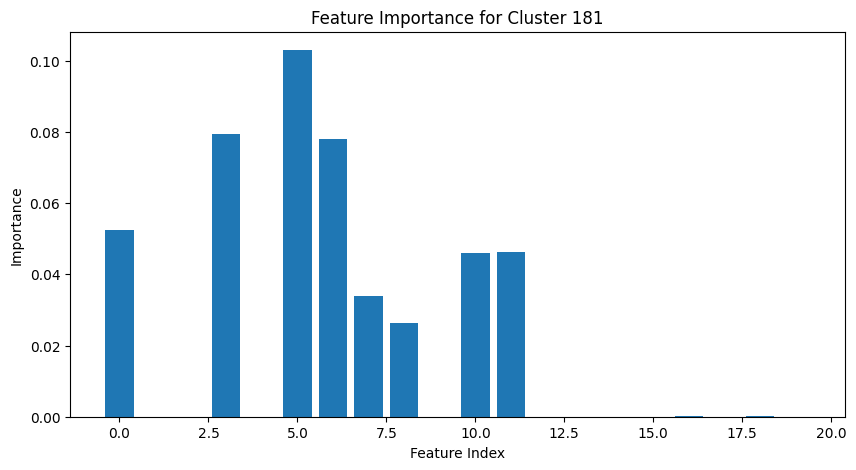

Cluster 182 does not have enough samples for stratified splitting. Skipping...
Cluster 183 does not have enough samples for stratified splitting. Skipping...
Cluster 184 does not have enough samples for stratified splitting. Skipping...
Cluster 185 does not have enough samples for stratified splitting. Skipping...
Cluster 186 does not have enough samples for stratified splitting. Skipping...
Cluster 187 does not have enough samples for stratified splitting. Skipping...
Cluster 188 does not have enough samples for stratified splitting. Skipping...
Cluster 189 does not have enough samples for stratified splitting. Skipping...
Cluster 190 does not have enough samples for stratified splitting. Skipping...
Cluster 191 does not have enough samples for stratified splitting. Skipping...
Cluster 192 does not have enough samples for stratified splitting. Skipping...
Cluster 193 - Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

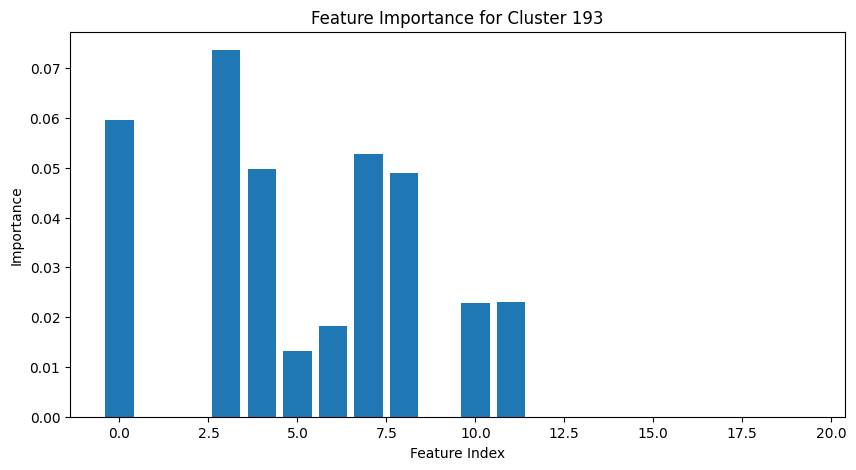

Cluster 194 - Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       0.00      0.00      0.00         2

    accuracy                           0.91        22
   macro avg       0.45      0.50      0.48        22
weighted avg       0.83      0.91      0.87        22



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

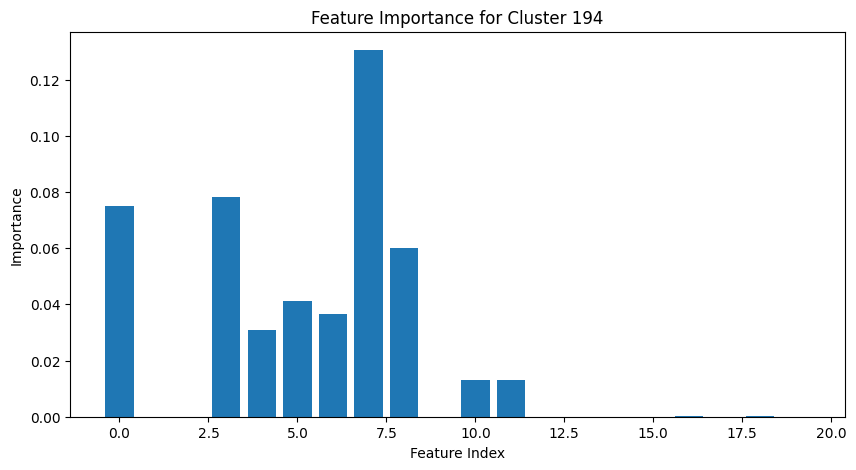

Cluster 195 does not have enough samples for stratified splitting. Skipping...
Cluster 196 does not have enough samples for stratified splitting. Skipping...
Cluster 197 does not have enough samples for stratified splitting. Skipping...
Cluster 198 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

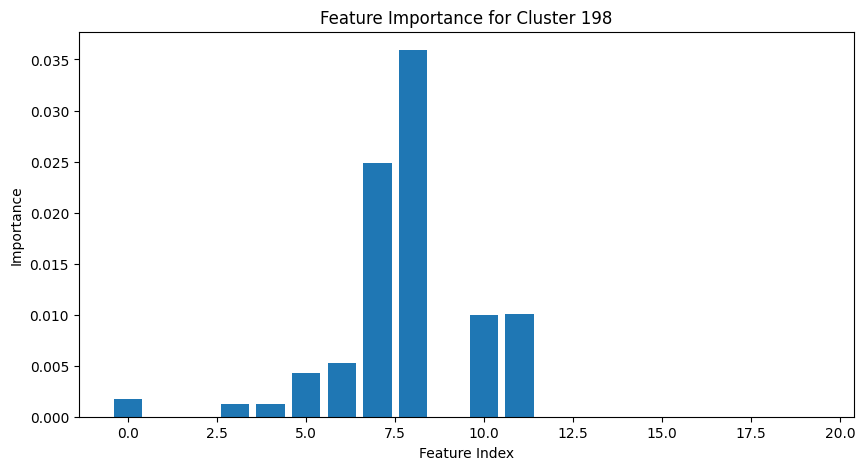

Cluster 199 does not have enough samples for stratified splitting. Skipping...
Cluster 200 does not have enough samples for stratified splitting. Skipping...
Cluster 201 - Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.85        11
           1       0.00      0.00      0.00         4

    accuracy                           0.73        15
   macro avg       0.37      0.50      0.42        15
weighted avg       0.54      0.73      0.62        15



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

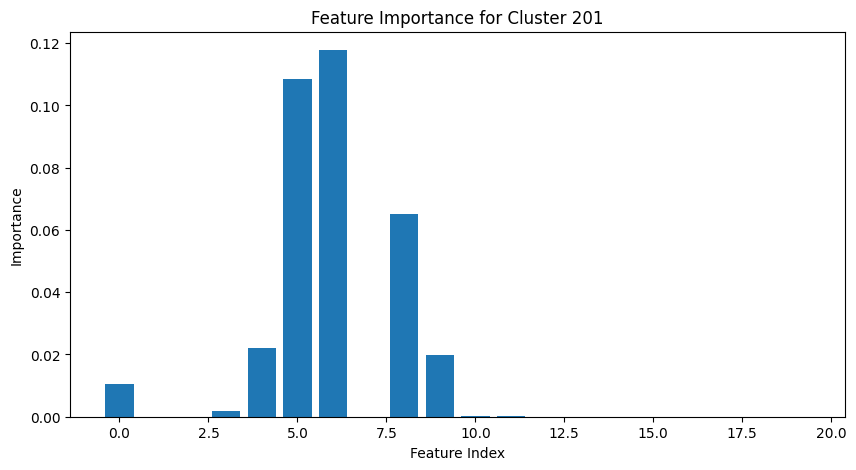

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 202 does not have enough samples for stratified splitting. Skipping...
Cluster 203 does not have enough samples for stratified splitting. Skipping...
Cluster 204 does not have enough samples for stratified splitting. Skipping...
Cluster 205 - Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        47
           1       0.00      0.00      0.00         7

    accuracy                           0.87        54
   macro avg       0.44      0.50      0.47        54
weighted avg       0.76      0.87      0.81        54



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


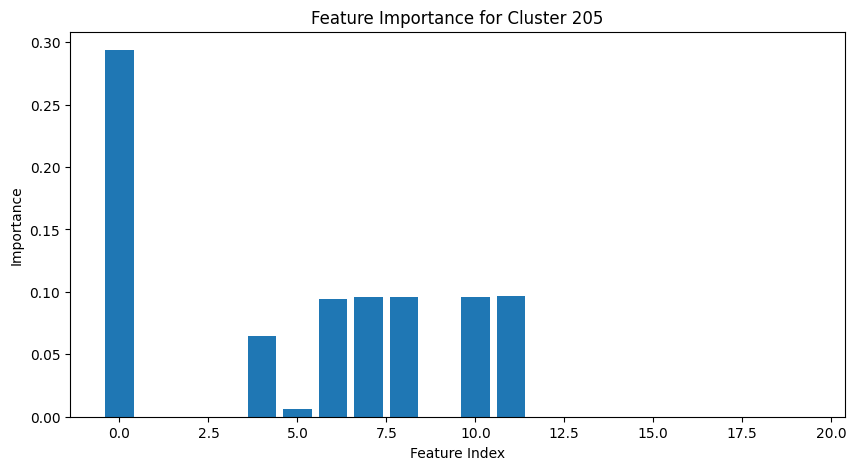

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 206 does not have enough samples for stratified splitting. Skipping...
Cluster 207 does not have enough samples for stratified splitting. Skipping...
Cluster 208 does not have enough samples for stratified splitting. Skipping...
Cluster 209 does not have enough samples for stratified splitting. Skipping...
Cluster 210 does not have enough samples for stratified splitting. Skipping...
Cluster 211 does not have enough samples for stratified splitting. Skipping...
Cluster 212 does not have enough samples for stratified splitting. Skipping...
Cluster 213 does not have enough samples for stratified splitting. Skipping...
Cluster 214 does not have enough samples for stratified splitting. Skipping...
Cluster 215 does not have enough samples for stratified splitting. Skipping...
Cluster 216 does not have enough samples for stratified splitting. Skipping...
Cluster 217 does not have enough samples for stratified splitting. Skipping...
Cluster 218 does not have enough samples for stratif

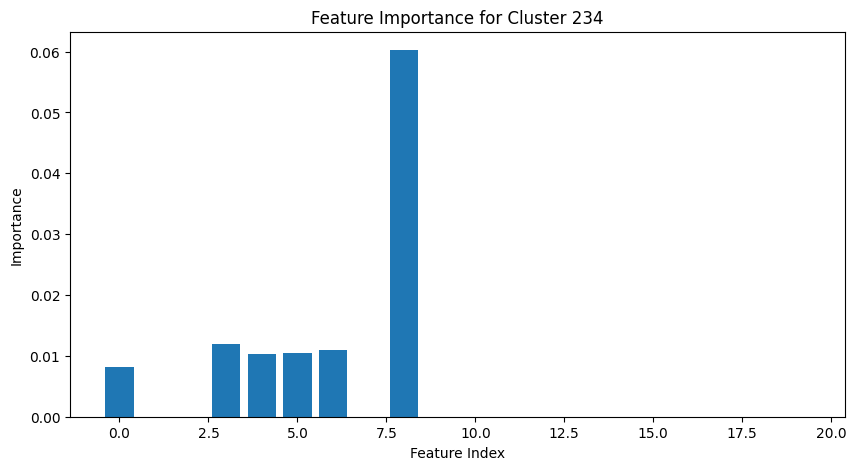

Cluster 235 does not have enough samples for stratified splitting. Skipping...
Cluster 236 does not have enough samples for stratified splitting. Skipping...
Cluster 237 does not have enough samples for stratified splitting. Skipping...
Cluster 238 does not have enough samples for stratified splitting. Skipping...
Cluster 239 does not have enough samples for stratified splitting. Skipping...
Cluster 240 does not have enough samples for stratified splitting. Skipping...
Cluster 241 does not have enough samples for stratified splitting. Skipping...
Cluster 242 does not have enough samples for stratified splitting. Skipping...
Cluster 243 does not have enough samples for stratified splitting. Skipping...
Cluster 244 does not have enough samples for stratified splitting. Skipping...
Cluster 245 does not have enough samples for stratified splitting. Skipping...
Cluster 246 does not have enough samples for stratified splitting. Skipping...
Cluster 247 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

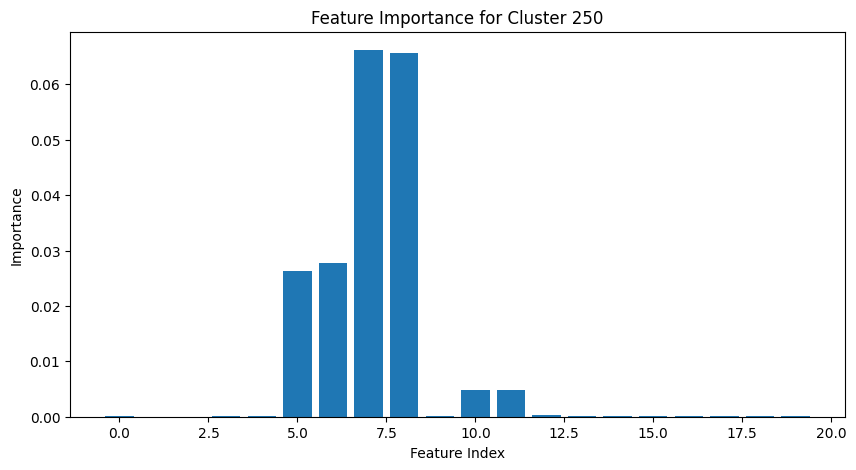

Cluster 251 does not have enough samples for stratified splitting. Skipping...
Cluster 252 does not have enough samples for stratified splitting. Skipping...
Cluster 253 does not have enough samples for stratified splitting. Skipping...
Cluster 254 does not have enough samples for stratified splitting. Skipping...
Cluster 255 does not have enough samples for stratified splitting. Skipping...
Cluster 256 does not have enough samples for stratified splitting. Skipping...
Cluster 257 does not have enough samples for stratified splitting. Skipping...
Cluster 258 does not have enough samples for stratified splitting. Skipping...
Cluster 259 does not have enough samples for stratified splitting. Skipping...
Cluster 260 does not have enough samples for stratified splitting. Skipping...
Cluster 261 does not have enough samples for stratified splitting. Skipping...
Cluster 262 does not have enough samples for stratified splitting. Skipping...
Cluster 263 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

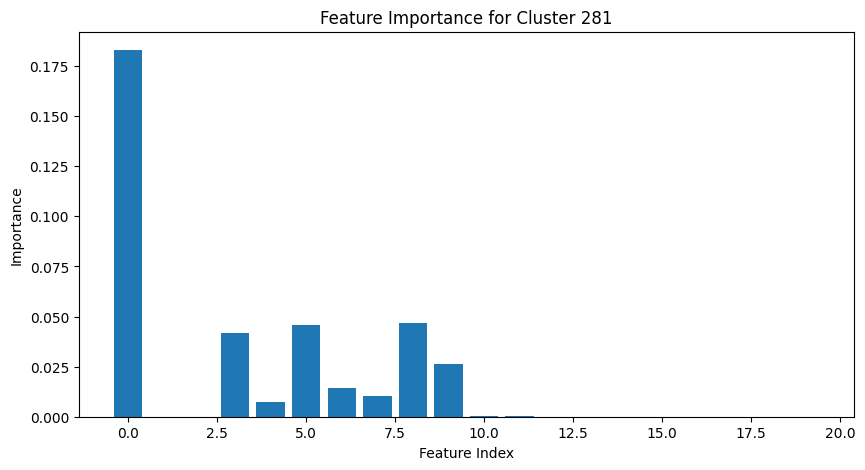

Cluster 282 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

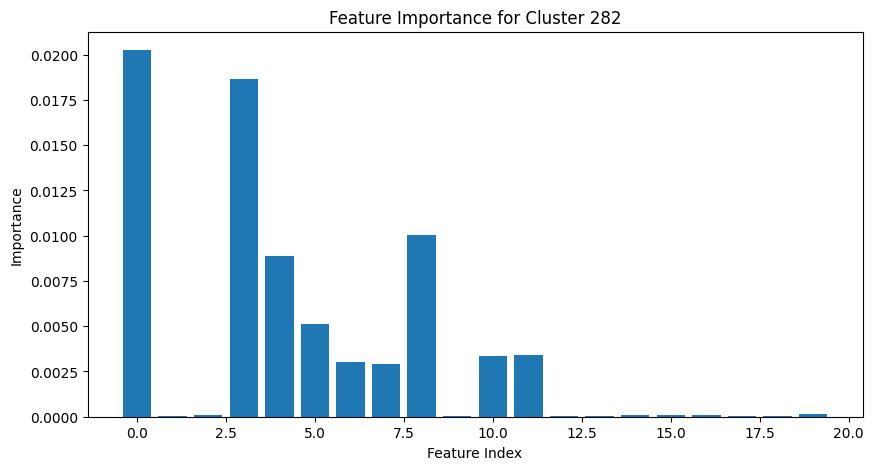

Cluster 283 does not have enough samples for stratified splitting. Skipping...
Cluster 284 - Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84         8
           1       0.00      0.00      0.00         3

    accuracy                           0.73        11
   macro avg       0.36      0.50      0.42        11
weighted avg       0.53      0.73      0.61        11



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

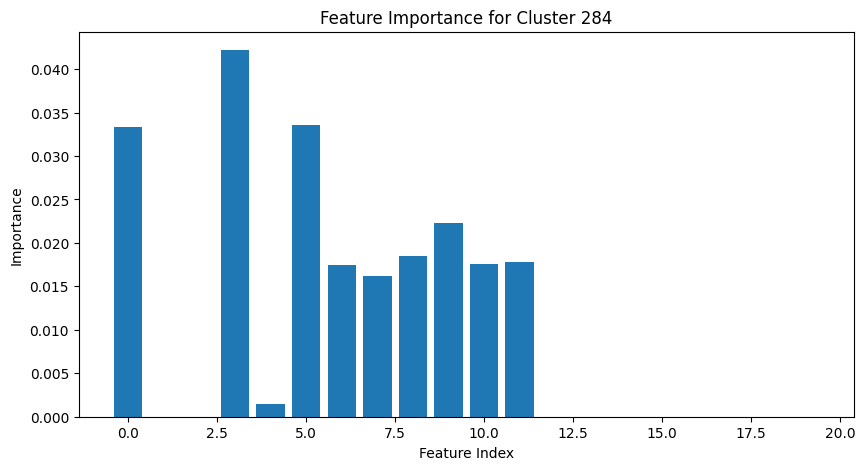

Cluster 285 does not have enough samples for stratified splitting. Skipping...
Cluster 286 does not have enough samples for stratified splitting. Skipping...
Cluster 287 does not have enough samples for stratified splitting. Skipping...
Cluster 288 does not have enough samples for stratified splitting. Skipping...
Cluster 289 does not have enough samples for stratified splitting. Skipping...
Cluster 290 does not have enough samples for stratified splitting. Skipping...
Cluster 291 does not have enough samples for stratified splitting. Skipping...
Cluster 292 does not have enough samples for stratified splitting. Skipping...
Cluster 293 does not have enough samples for stratified splitting. Skipping...
Cluster 294 - Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50 

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

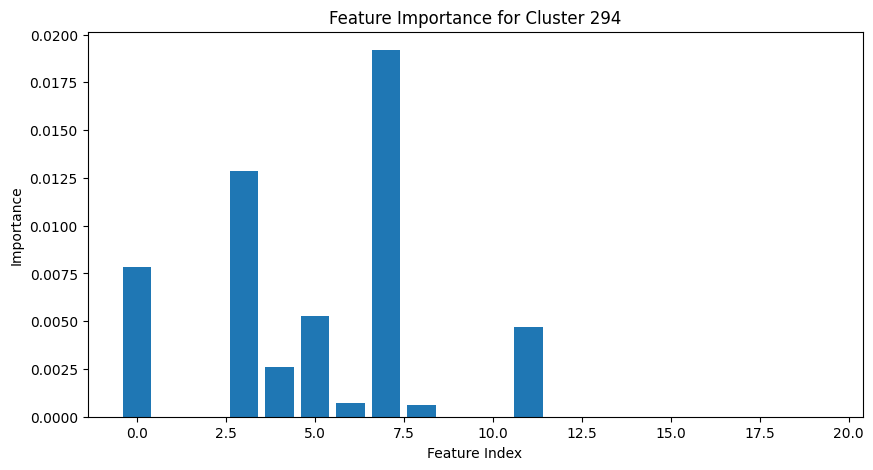

Cluster 295 does not have enough samples for stratified splitting. Skipping...
Cluster 296 does not have enough samples for stratified splitting. Skipping...
Cluster 297 - Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       0.00      0.00      0.00         1

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

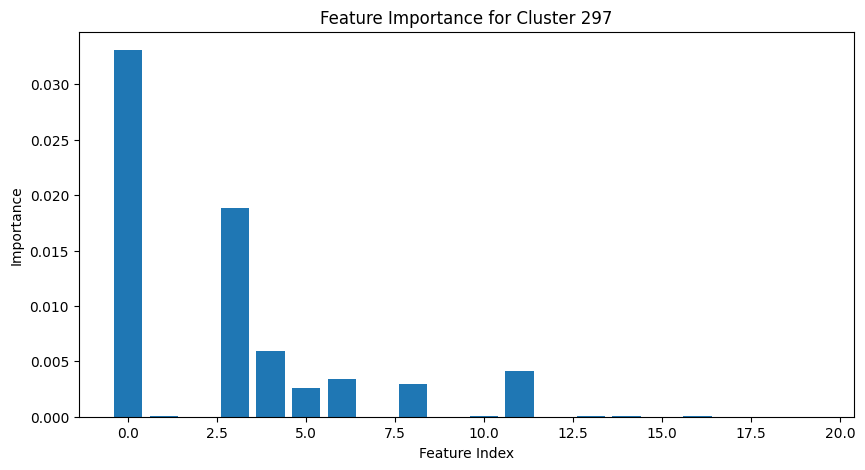

Cluster 298 - Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        23
           1       0.00      0.00      0.00         2

    accuracy                           0.92        25
   macro avg       0.46      0.50      0.48        25
weighted avg       0.85      0.92      0.88        25



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

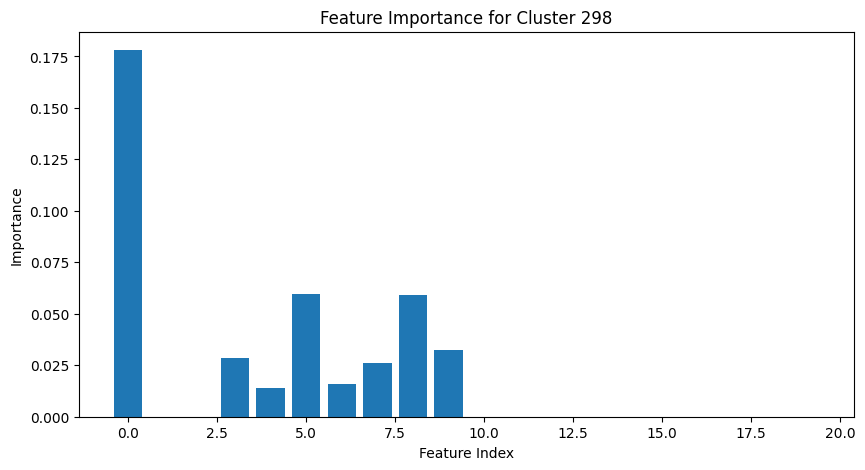

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 299 does not have enough samples for stratified splitting. Skipping...
Cluster 300 does not have enough samples for stratified splitting. Skipping...
Cluster 301 - Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         9
           1       0.00      0.00      0.00         3

    accuracy                           0.75        12
   macro avg       0.38      0.50      0.43        12
weighted avg       0.56      0.75      0.64        12



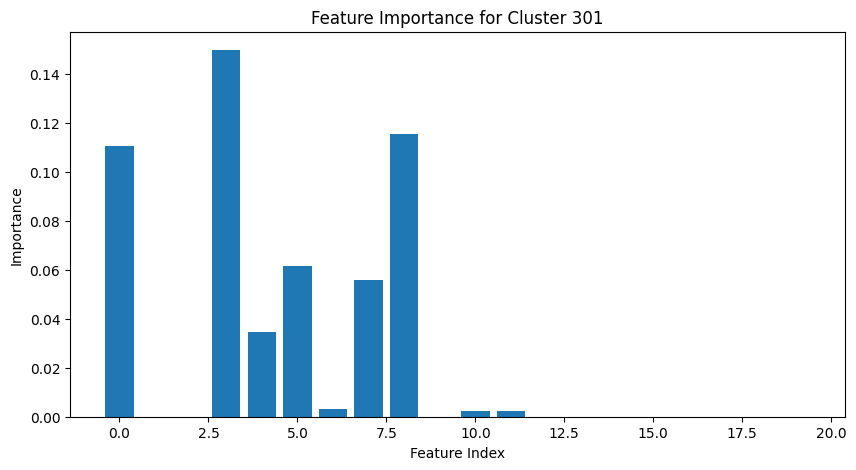

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 302 does not have enough samples for stratified splitting. Skipping...
Cluster 303 does not have enough samples for stratified splitting. Skipping...
Cluster 304 does not have enough samples for stratified splitting. Skipping...
Cluster 305 does not have enough samples for stratified splitting. Skipping...
Cluster 306 does not have enough samples for stratified splitting. Skipping...
Cluster 307 does not have enough samples for stratified splitting. Skipping...
Cluster 308 does not have enough samples for stratified splitting. Skipping...
Cluster 309 - Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.00      0.00      0.00         1

    accuracy                           0.93        15
   macro avg       0.47      0.50      0.48        15
weighted avg       0.87      0.93      0.90        15



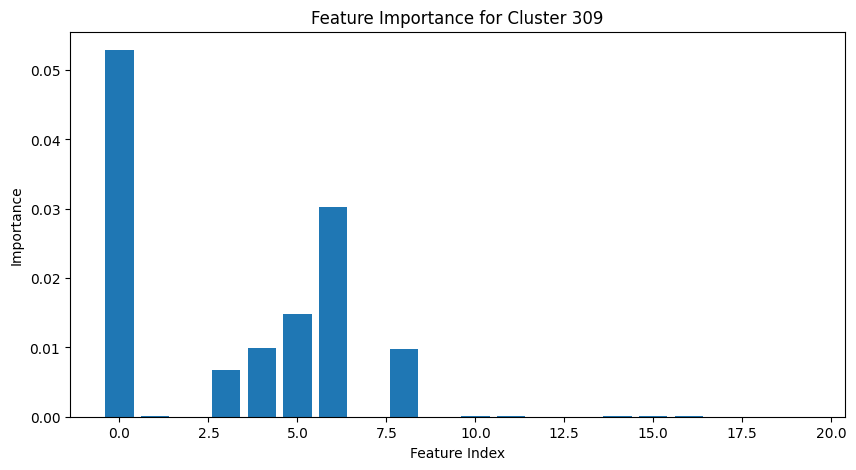

Cluster 310 does not have enough samples for stratified splitting. Skipping...
Cluster 311 - Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       0.00      0.00      0.00         2

    accuracy                           0.86        14
   macro avg       0.43      0.50      0.46        14
weighted avg       0.73      0.86      0.79        14



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

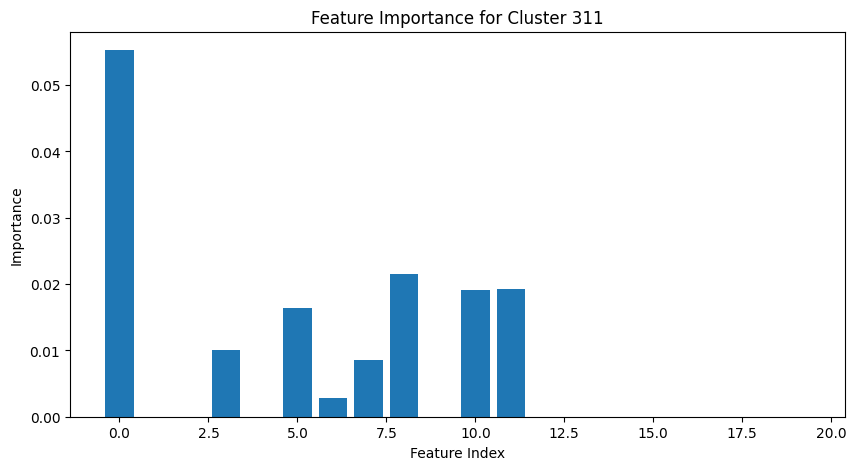

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 312 does not have enough samples for stratified splitting. Skipping...
Cluster 313 does not have enough samples for stratified splitting. Skipping...
Cluster 314 does not have enough samples for stratified splitting. Skipping...
Cluster 315 does not have enough samples for stratified splitting. Skipping...
Cluster 316 does not have enough samples for stratified splitting. Skipping...
Cluster 317 does not have enough samples for stratified splitting. Skipping...
Cluster 318 - Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       0.00      0.00      0.00         1

    accuracy                           0.94        16
   macro avg       0.47      0.50      0.48        16
weighted avg       0.88      0.94      0.91        16



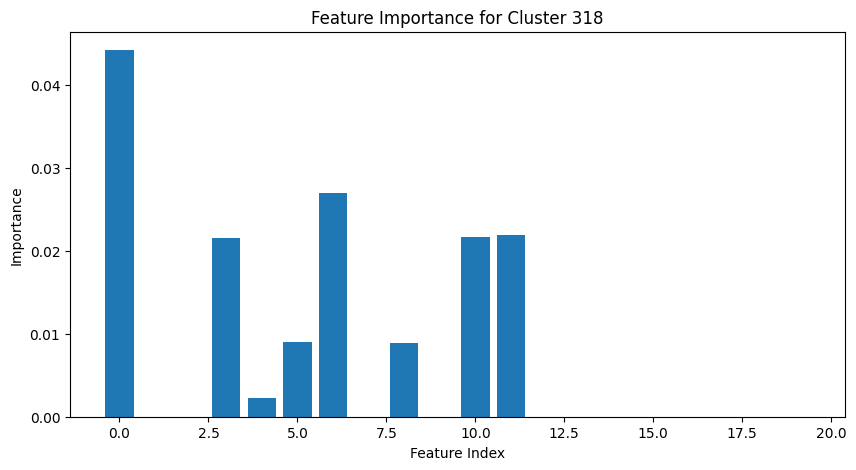

Cluster 319 does not have enough samples for stratified splitting. Skipping...
Cluster 320 does not have enough samples for stratified splitting. Skipping...
Cluster 321 does not have enough samples for stratified splitting. Skipping...
Cluster 322 does not have enough samples for stratified splitting. Skipping...
Cluster 323 does not have enough samples for stratified splitting. Skipping...
Cluster 324 does not have enough samples for stratified splitting. Skipping...
Cluster 325 does not have enough samples for stratified splitting. Skipping...
Cluster 326 does not have enough samples for stratified splitting. Skipping...
Cluster 327 does not have enough samples for stratified splitting. Skipping...
Cluster 328 does not have enough samples for stratified splitting. Skipping...
Cluster 329 does not have enough samples for stratified splitting. Skipping...
Cluster 330 does not have enough samples for stratified splitting. Skipping...
Cluster 331 - Classification Report:
              p

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

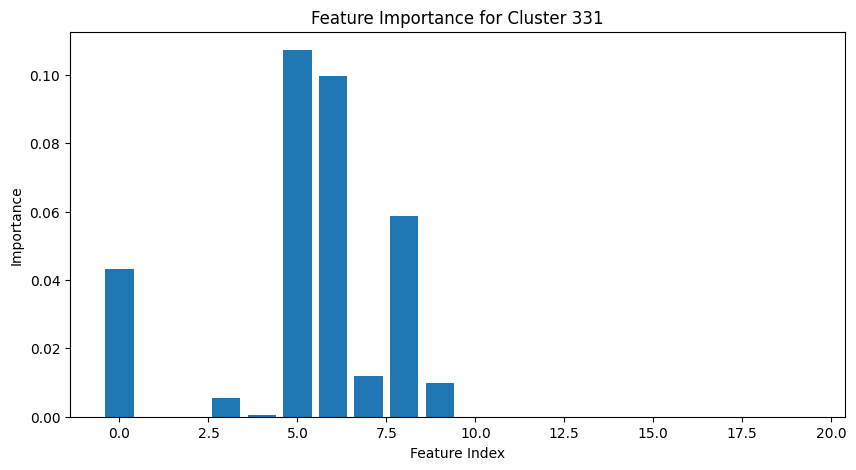

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 332 does not have enough samples for stratified splitting. Skipping...
Cluster 333 does not have enough samples for stratified splitting. Skipping...
Cluster 334 does not have enough samples for stratified splitting. Skipping...
Cluster 335 does not have enough samples for stratified splitting. Skipping...
Cluster 336 does not have enough samples for stratified splitting. Skipping...
Cluster 337 - Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       0.00      0.00      0.00         1

    accuracy                           0.89         9
   macro avg       0.44      0.50      0.47         9
weighted avg       0.79      0.89      0.84         9



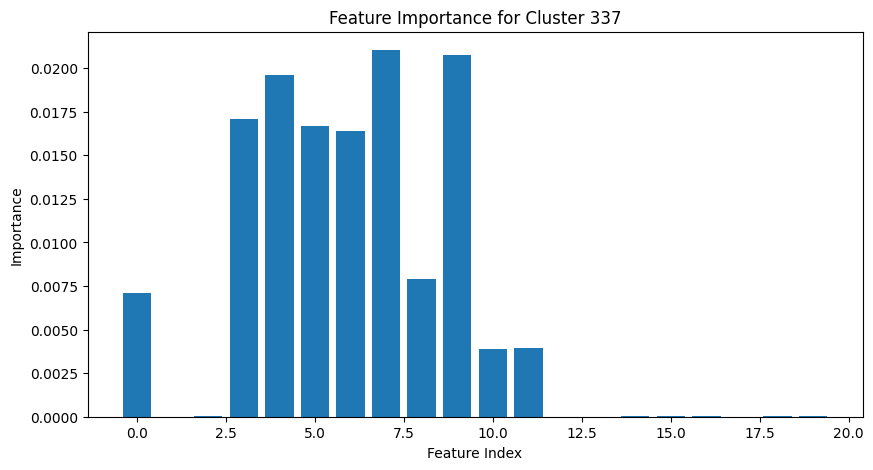

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 338 does not have enough samples for stratified splitting. Skipping...
Cluster 339 does not have enough samples for stratified splitting. Skipping...
Cluster 340 does not have enough samples for stratified splitting. Skipping...
Cluster 341 does not have enough samples for stratified splitting. Skipping...
Cluster 342 does not have enough samples for stratified splitting. Skipping...
Cluster 343 does not have enough samples for stratified splitting. Skipping...
Cluster 344 - Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       0.00      0.00      0.00         1

    accuracy                           0.95        20
   macro avg       0.47      0.50      0.49        20
weighted avg       0.90      0.95      0.93        20



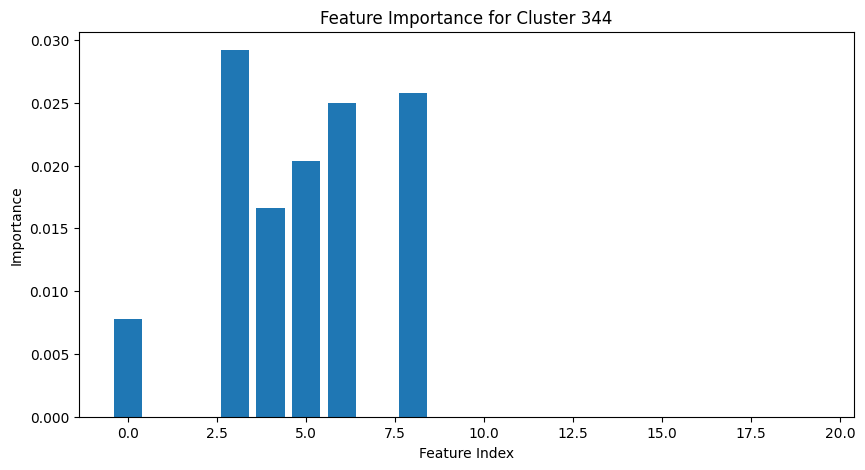

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 345 does not have enough samples for stratified splitting. Skipping...
Cluster 346 does not have enough samples for stratified splitting. Skipping...
Cluster 347 does not have enough samples for stratified splitting. Skipping...
Cluster 348 does not have enough samples for stratified splitting. Skipping...
Cluster 349 does not have enough samples for stratified splitting. Skipping...
Cluster 350 does not have enough samples for stratified splitting. Skipping...
Cluster 351 does not have enough samples for stratified splitting. Skipping...
Cluster 352 does not have enough samples for stratified splitting. Skipping...
Cluster 353 does not have enough samples for stratified splitting. Skipping...
Cluster 354 does not have enough samples for stratified splitting. Skipping...
Cluster 355 does not have enough samples for stratified splitting. Skipping...
Cluster 356 does not have enough samples for stratified splitting. Skipping...
Cluster 357 - Classification Report:
              p

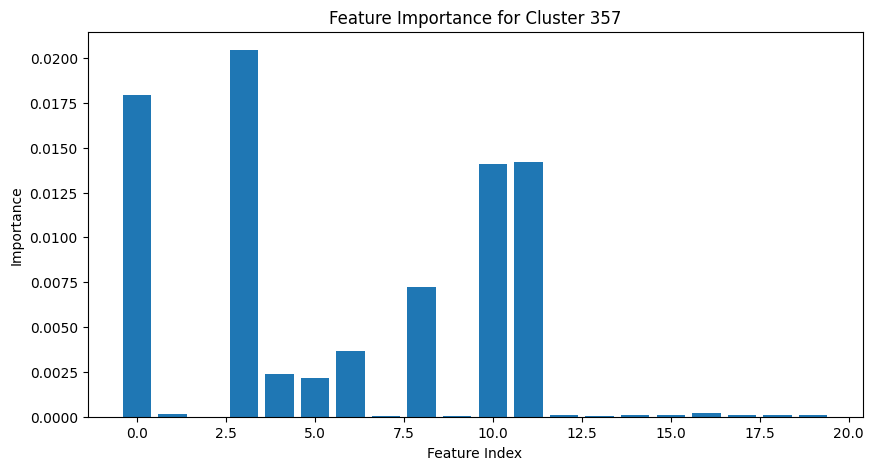

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 358 - Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        12
           1       0.00      0.00      0.00         3

    accuracy                           0.80        15
   macro avg       0.40      0.50      0.44        15
weighted avg       0.64      0.80      0.71        15



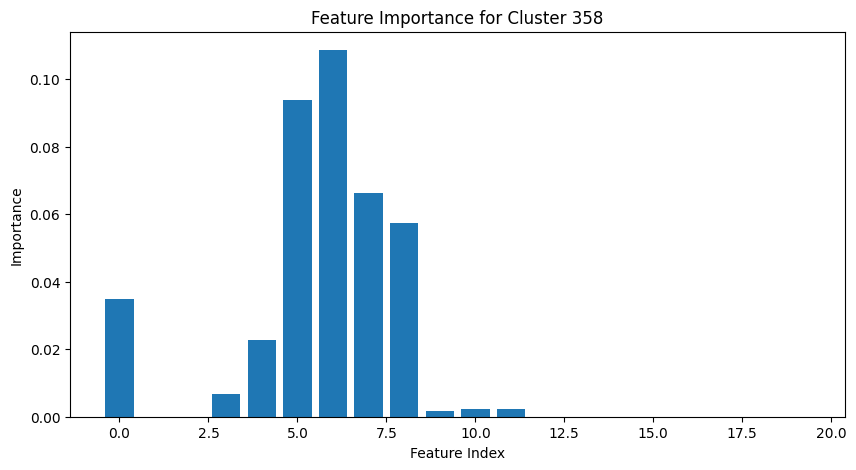

Cluster 359 does not have enough samples for stratified splitting. Skipping...
Cluster 360 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

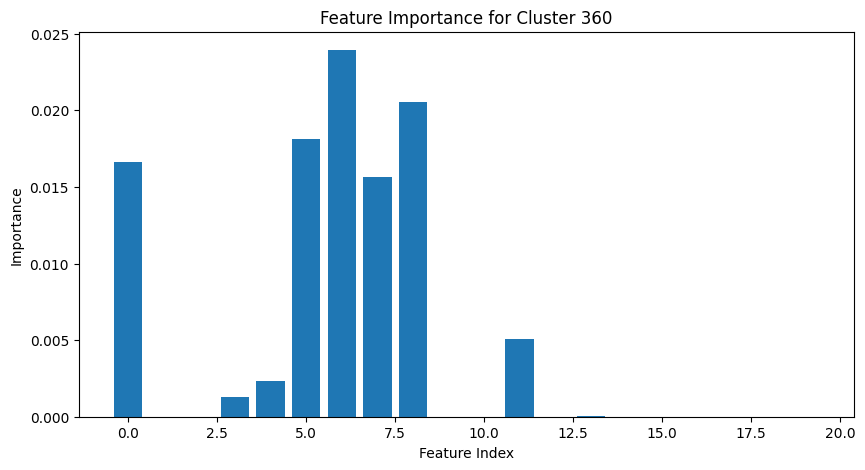

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 361 does not have enough samples for stratified splitting. Skipping...
Cluster 362 does not have enough samples for stratified splitting. Skipping...
Cluster 363 does not have enough samples for stratified splitting. Skipping...
Cluster 364 - Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        25
           1       0.00      0.00      0.00         7

    accuracy                           0.78        32
   macro avg       0.39      0.50      0.44        32
weighted avg       0.61      0.78      0.69        32



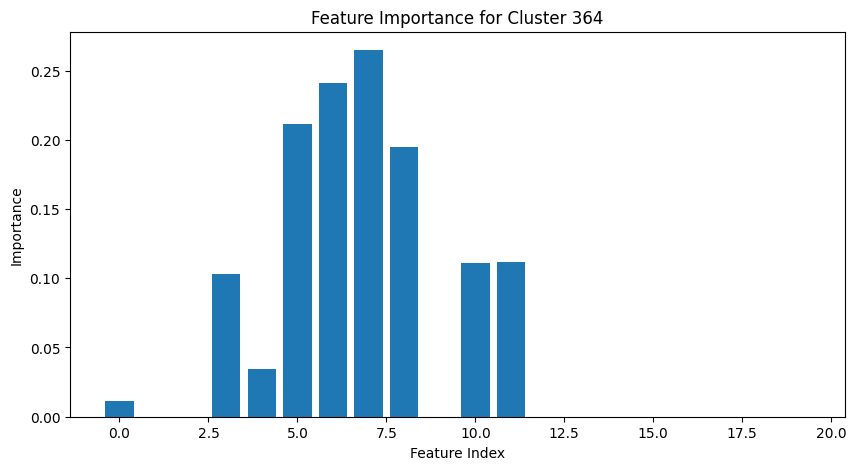

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 365 does not have enough samples for stratified splitting. Skipping...
Cluster 366 does not have enough samples for stratified splitting. Skipping...
Cluster 367 does not have enough samples for stratified splitting. Skipping...
Cluster 368 does not have enough samples for stratified splitting. Skipping...
Cluster 369 does not have enough samples for stratified splitting. Skipping...
Cluster 370 does not have enough samples for stratified splitting. Skipping...
Cluster 371 does not have enough samples for stratified splitting. Skipping...
Cluster 372 - Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.00      0.00      0.00         1

    accuracy                           0.93        15
   macro avg       0.47      0.50      0.48        15
weighted avg       0.87      0.93      0.90        15



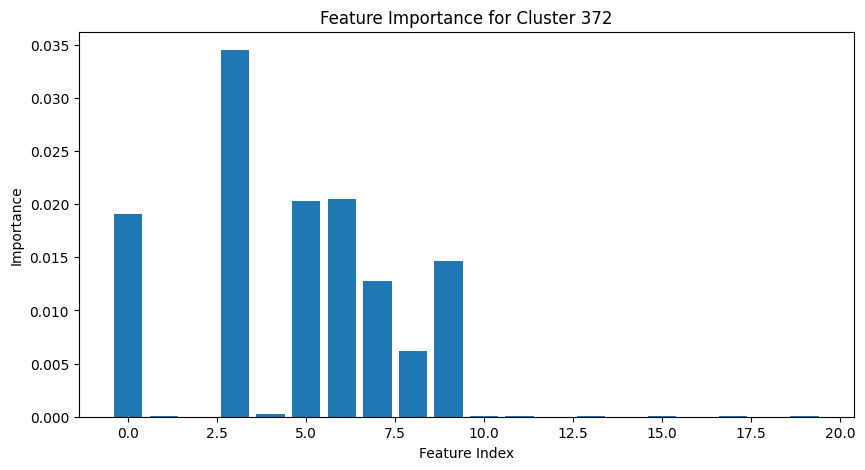

Cluster 373 does not have enough samples for stratified splitting. Skipping...
Cluster 374 does not have enough samples for stratified splitting. Skipping...
Cluster 375 does not have enough samples for stratified splitting. Skipping...
Cluster 376 does not have enough samples for stratified splitting. Skipping...
Cluster 377 does not have enough samples for stratified splitting. Skipping...
Cluster 378 does not have enough samples for stratified splitting. Skipping...
Cluster 379 does not have enough samples for stratified splitting. Skipping...
Cluster 380 does not have enough samples for stratified splitting. Skipping...
Cluster 381 does not have enough samples for stratified splitting. Skipping...
Cluster 382 does not have enough samples for stratified splitting. Skipping...
Cluster 383 does not have enough samples for stratified splitting. Skipping...
Cluster 384 does not have enough samples for stratified splitting. Skipping...
Cluster 385 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

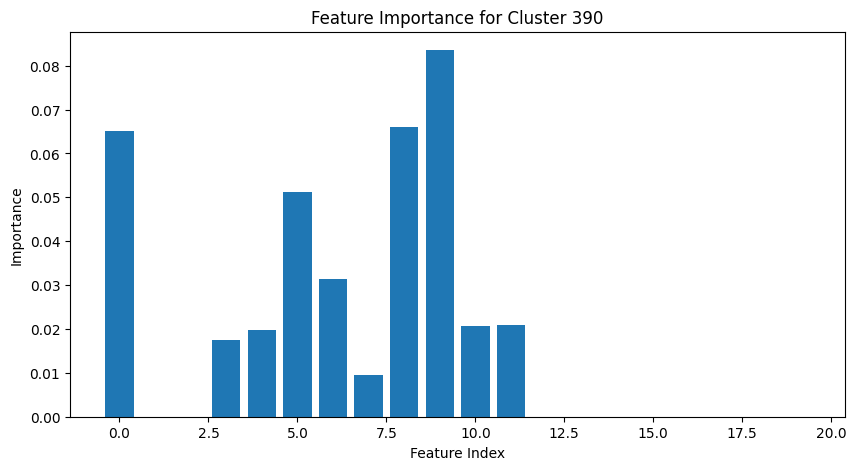

Cluster 391 does not have enough samples for stratified splitting. Skipping...
Cluster 392 does not have enough samples for stratified splitting. Skipping...
Cluster 393 does not have enough samples for stratified splitting. Skipping...
Cluster 394 does not have enough samples for stratified splitting. Skipping...
Cluster 395 does not have enough samples for stratified splitting. Skipping...
Cluster 396 does not have enough samples for stratified splitting. Skipping...
Cluster 397 does not have enough samples for stratified splitting. Skipping...
Cluster 398 does not have enough samples for stratified splitting. Skipping...
Cluster 399 does not have enough samples for stratified splitting. Skipping...
Cluster 400 does not have enough samples for stratified splitting. Skipping...
Cluster 401 does not have enough samples for stratified splitting. Skipping...
Cluster 402 does not have enough samples for stratified splitting. Skipping...
Cluster 403 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

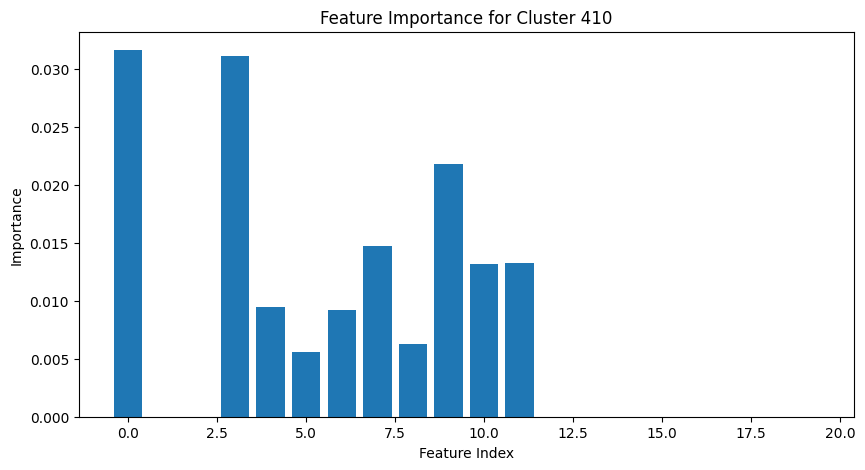

Cluster 411 does not have enough samples for stratified splitting. Skipping...
Cluster 412 does not have enough samples for stratified splitting. Skipping...
Cluster 413 does not have enough samples for stratified splitting. Skipping...
Cluster 414 does not have enough samples for stratified splitting. Skipping...
Cluster 415 does not have enough samples for stratified splitting. Skipping...
Cluster 416 does not have enough samples for stratified splitting. Skipping...
Cluster 417 does not have enough samples for stratified splitting. Skipping...
Cluster 418 does not have enough samples for stratified splitting. Skipping...
Cluster 419 does not have enough samples for stratified splitting. Skipping...
Cluster 420 does not have enough samples for stratified splitting. Skipping...
Cluster 421 does not have enough samples for stratified splitting. Skipping...
Cluster 422 does not have enough samples for stratified splitting. Skipping...
Cluster 423 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

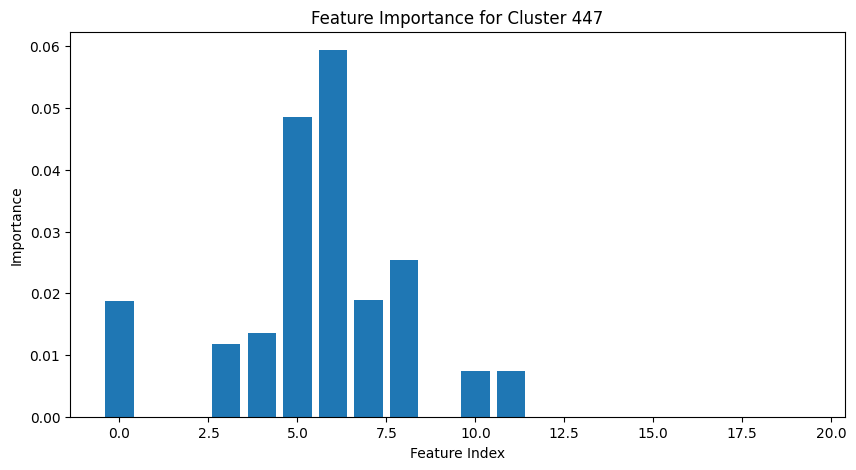

Cluster 448 does not have enough samples for stratified splitting. Skipping...
Cluster 449 does not have enough samples for stratified splitting. Skipping...
Cluster 450 does not have enough samples for stratified splitting. Skipping...
Cluster 451 - Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         9
           1       0.00      0.00      0.00         3

    accuracy                           0.75        12
   macro avg       0.38      0.50      0.43        12
weighted avg       0.56      0.75      0.64        12



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

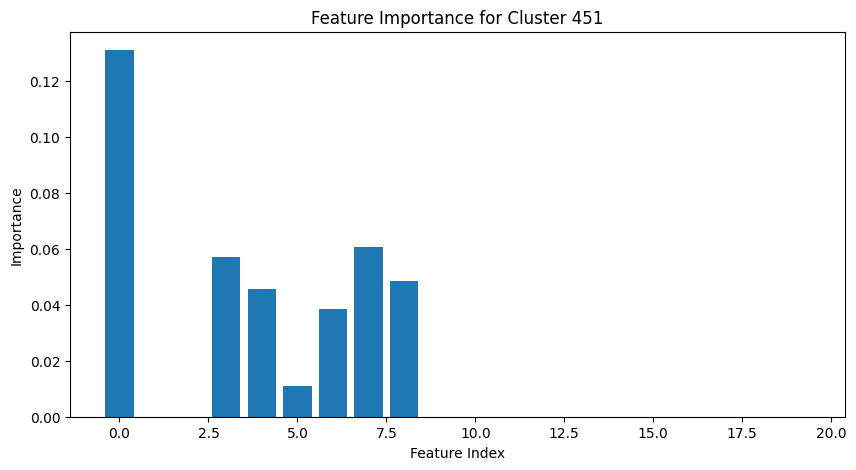

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 452 does not have enough samples for stratified splitting. Skipping...
Cluster 453 does not have enough samples for stratified splitting. Skipping...
Cluster 454 - Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       0.00      0.00      0.00         1

    accuracy                           0.94        17
   macro avg       0.47      0.50      0.48        17
weighted avg       0.89      0.94      0.91        17



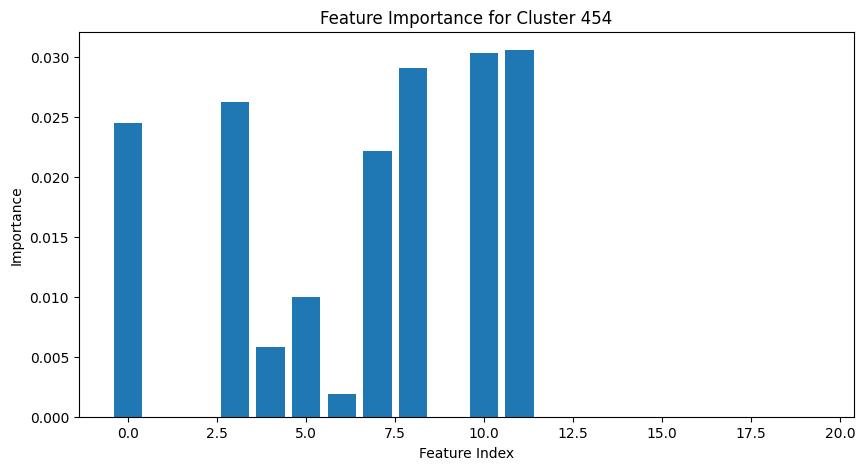

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 455 does not have enough samples for stratified splitting. Skipping...
Cluster 456 does not have enough samples for stratified splitting. Skipping...
Cluster 457 does not have enough samples for stratified splitting. Skipping...
Cluster 458 does not have enough samples for stratified splitting. Skipping...
Cluster 459 does not have enough samples for stratified splitting. Skipping...
Cluster 460 does not have enough samples for stratified splitting. Skipping...
Cluster 461 does not have enough samples for stratified splitting. Skipping...
Cluster 462 - Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



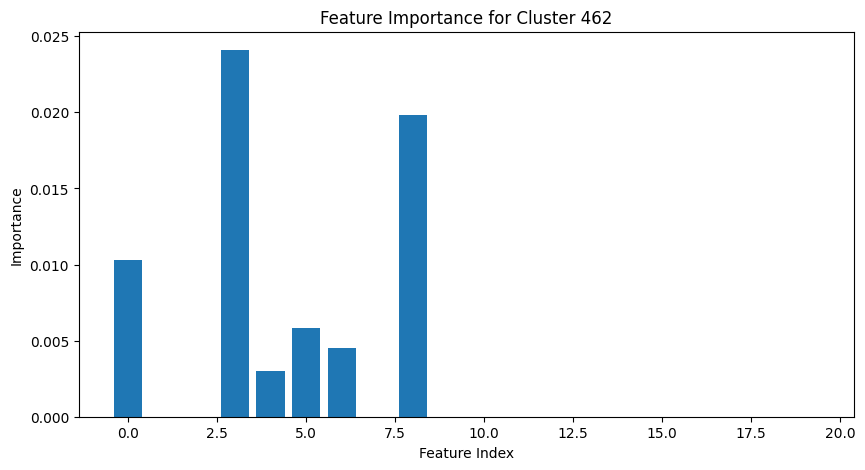

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 463 does not have enough samples for stratified splitting. Skipping...
Cluster 464 does not have enough samples for stratified splitting. Skipping...
Cluster 465 does not have enough samples for stratified splitting. Skipping...
Cluster 466 does not have enough samples for stratified splitting. Skipping...
Cluster 467 does not have enough samples for stratified splitting. Skipping...
Cluster 468 does not have enough samples for stratified splitting. Skipping...
Cluster 469 does not have enough samples for stratified splitting. Skipping...
Cluster 470 does not have enough samples for stratified splitting. Skipping...
Cluster 471 does not have enough samples for stratified splitting. Skipping...
Cluster 472 does not have enough samples for stratified splitting. Skipping...
Cluster 473 does not have enough samples for stratified splitting. Skipping...
Cluster 474 does not have enough samples for stratified splitting. Skipping...
Cluster 475 does not have enough samples for stratif

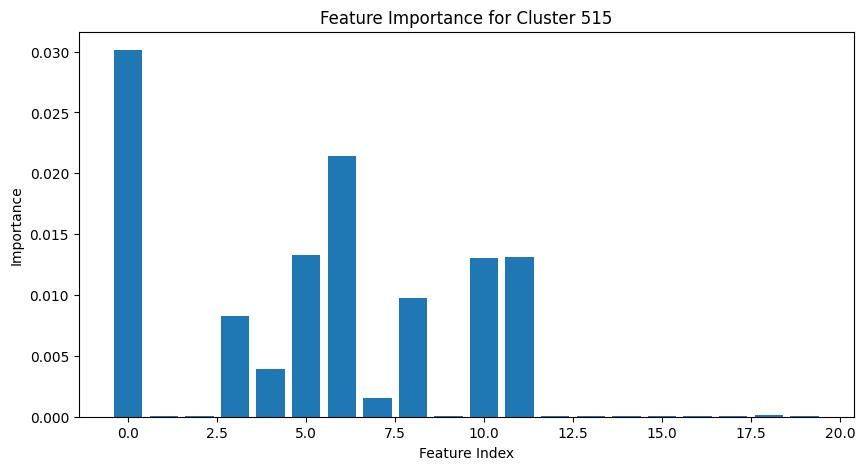

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 516 does not have enough samples for stratified splitting. Skipping...
Cluster 517 does not have enough samples for stratified splitting. Skipping...
Cluster 518 does not have enough samples for stratified splitting. Skipping...
Cluster 519 does not have enough samples for stratified splitting. Skipping...
Cluster 520 does not have enough samples for stratified splitting. Skipping...
Cluster 521 does not have enough samples for stratified splitting. Skipping...
Cluster 522 does not have enough samples for stratified splitting. Skipping...
Cluster 523 does not have enough samples for stratified splitting. Skipping...
Cluster 524 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



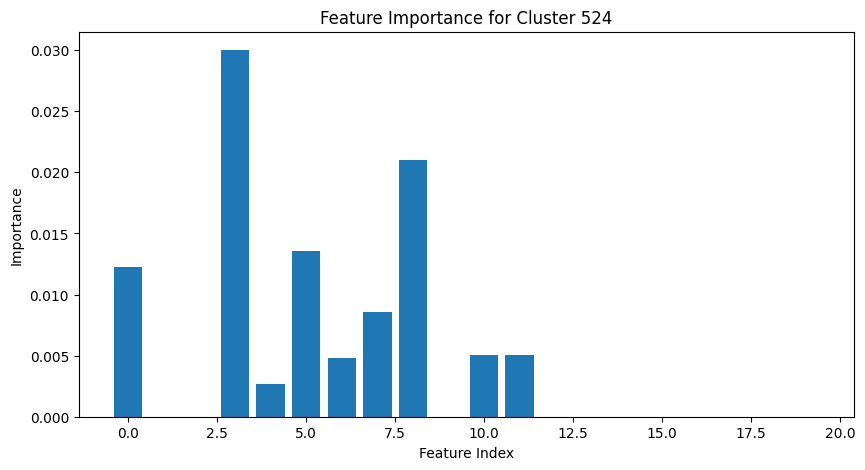

Cluster 525 does not have enough samples for stratified splitting. Skipping...
Cluster 526 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

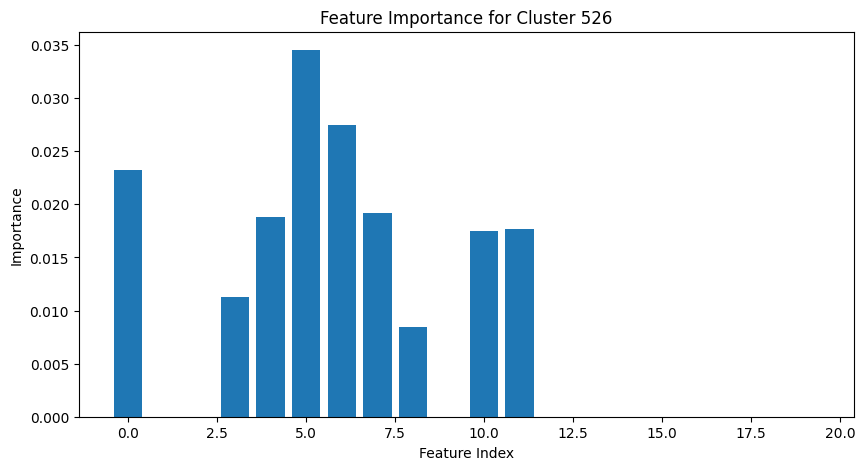

Cluster 527 does not have enough samples for stratified splitting. Skipping...
Cluster 528 does not have enough samples for stratified splitting. Skipping...
Cluster 529 - Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        14
           1       0.00      0.00      0.00         2

    accuracy                           0.88        16
   macro avg       0.44      0.50      0.47        16
weighted avg       0.77      0.88      0.82        16



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

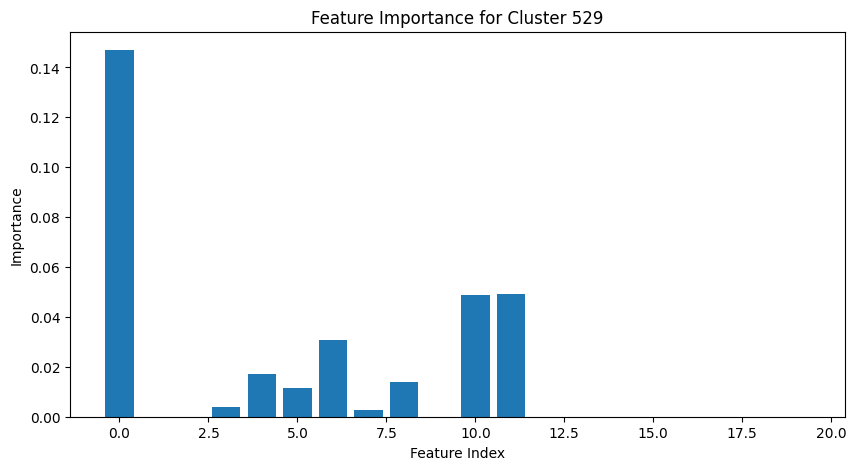

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 530 does not have enough samples for stratified splitting. Skipping...
Cluster 531 does not have enough samples for stratified splitting. Skipping...
Cluster 532 does not have enough samples for stratified splitting. Skipping...
Cluster 533 does not have enough samples for stratified splitting. Skipping...
Cluster 534 does not have enough samples for stratified splitting. Skipping...
Cluster 535 does not have enough samples for stratified splitting. Skipping...
Cluster 536 does not have enough samples for stratified splitting. Skipping...
Cluster 537 does not have enough samples for stratified splitting. Skipping...
Cluster 538 does not have enough samples for stratified splitting. Skipping...
Cluster 539 does not have enough samples for stratified splitting. Skipping...
Cluster 540 does not have enough samples for stratified splitting. Skipping...
Cluster 541 does not have enough samples for stratified splitting. Skipping...
Cluster 542 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


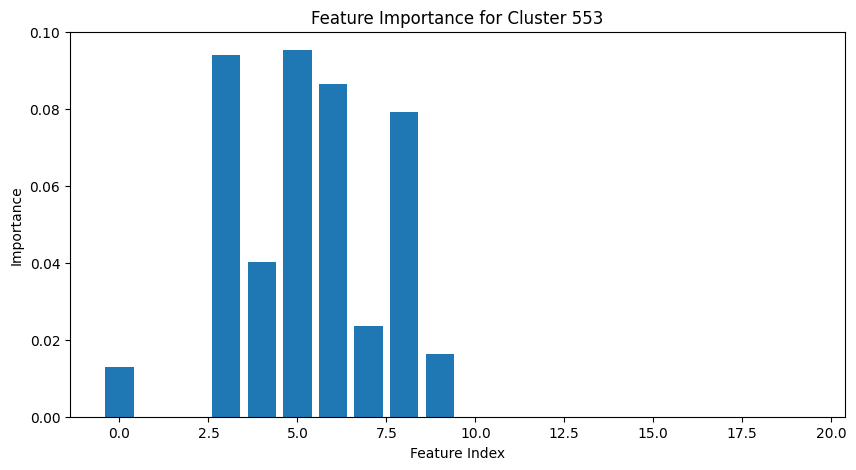

Cluster 554 does not have enough samples for stratified splitting. Skipping...
Cluster 555 does not have enough samples for stratified splitting. Skipping...
Cluster 556 - Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        20
           1       0.00      0.00      0.00         3

    accuracy                           0.87        23
   macro avg       0.43      0.50      0.47        23
weighted avg       0.76      0.87      0.81        23



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

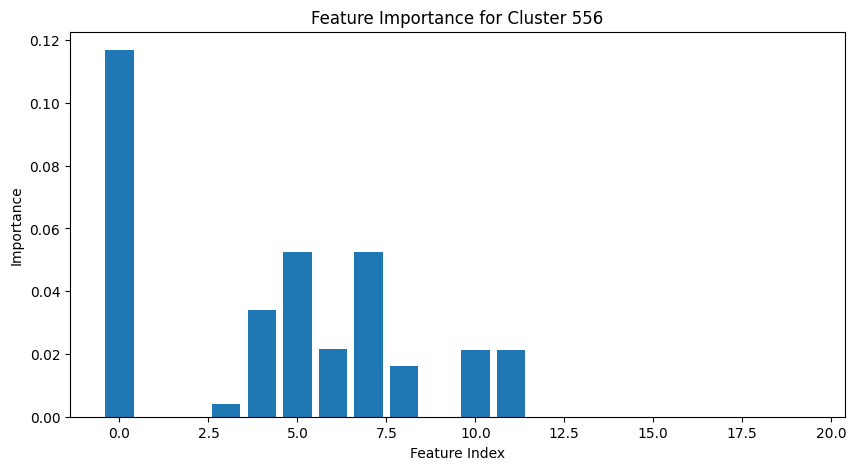

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 557 does not have enough samples for stratified splitting. Skipping...
Cluster 558 does not have enough samples for stratified splitting. Skipping...
Cluster 559 does not have enough samples for stratified splitting. Skipping...
Cluster 560 does not have enough samples for stratified splitting. Skipping...
Cluster 561 does not have enough samples for stratified splitting. Skipping...
Cluster 562 does not have enough samples for stratified splitting. Skipping...
Cluster 563 does not have enough samples for stratified splitting. Skipping...
Cluster 564 does not have enough samples for stratified splitting. Skipping...
Cluster 565 does not have enough samples for stratified splitting. Skipping...
Cluster 566 does not have enough samples for stratified splitting. Skipping...
Cluster 567 does not have enough samples for stratified splitting. Skipping...
Cluster 568 does not have enough samples for stratified splitting. Skipping...
Cluster 569 does not have enough samples for stratif

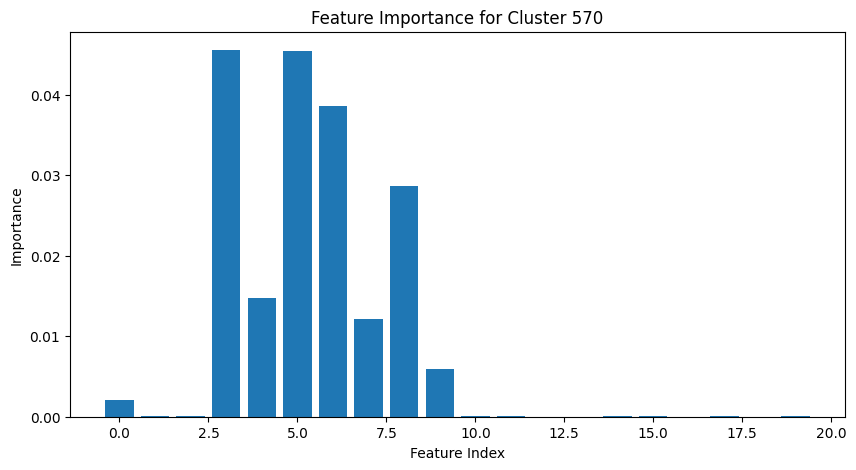

Cluster 571 does not have enough samples for stratified splitting. Skipping...
Cluster 572 does not have enough samples for stratified splitting. Skipping...
Cluster 573 does not have enough samples for stratified splitting. Skipping...
Cluster 574 does not have enough samples for stratified splitting. Skipping...
Cluster 575 does not have enough samples for stratified splitting. Skipping...
Cluster 576 does not have enough samples for stratified splitting. Skipping...
Cluster 577 does not have enough samples for stratified splitting. Skipping...
Cluster 578 does not have enough samples for stratified splitting. Skipping...
Cluster 579 does not have enough samples for stratified splitting. Skipping...
Cluster 580 does not have enough samples for stratified splitting. Skipping...
Cluster 581 does not have enough samples for stratified splitting. Skipping...
Cluster 582 does not have enough samples for stratified splitting. Skipping...
Cluster 583 - Classification Report:


C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.00      0.00      0.00         3

    accuracy                           0.62         8
   macro avg       0.31      0.50      0.38         8
weighted avg       0.39      0.62      0.48         8



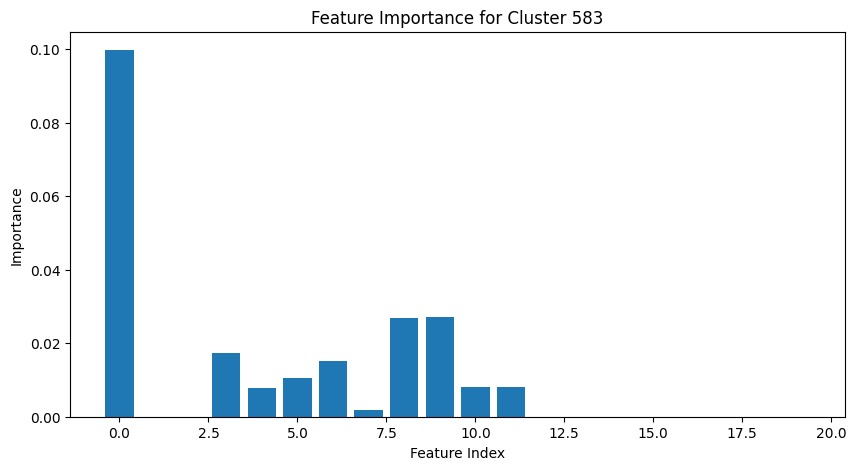

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 584 does not have enough samples for stratified splitting. Skipping...
Cluster 585 does not have enough samples for stratified splitting. Skipping...
Cluster 586 does not have enough samples for stratified splitting. Skipping...
Cluster 587 does not have enough samples for stratified splitting. Skipping...
Cluster 588 does not have enough samples for stratified splitting. Skipping...
Cluster 589 does not have enough samples for stratified splitting. Skipping...
Cluster 590 does not have enough samples for stratified splitting. Skipping...
Cluster 591 - Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       0.00      0.00      0.00         1

    accuracy                           0.89         9
   macro avg       0.44      0.50      0.47         9
weighted avg       0.79      0.89      0.84         9



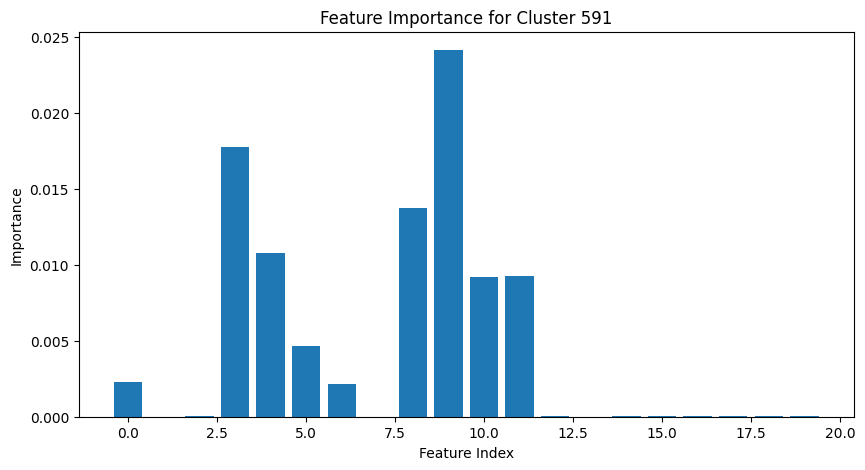

Cluster 592 does not have enough samples for stratified splitting. Skipping...
Cluster 593 does not have enough samples for stratified splitting. Skipping...
Cluster 594 does not have enough samples for stratified splitting. Skipping...
Cluster 595 does not have enough samples for stratified splitting. Skipping...
Cluster 596 does not have enough samples for stratified splitting. Skipping...
Cluster 597 does not have enough samples for stratified splitting. Skipping...
Cluster 598 - Classification Report:


              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

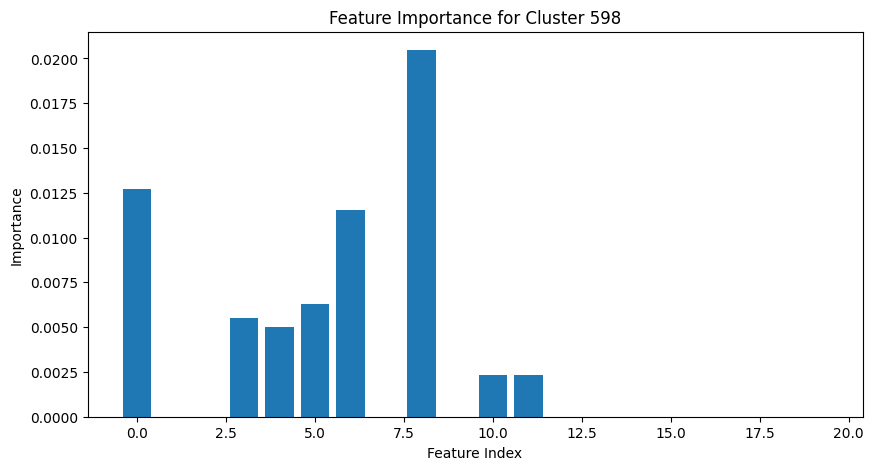

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 599 does not have enough samples for stratified splitting. Skipping...
Cluster 600 does not have enough samples for stratified splitting. Skipping...
Cluster 601 does not have enough samples for stratified splitting. Skipping...
Cluster 602 does not have enough samples for stratified splitting. Skipping...
Cluster 603 does not have enough samples for stratified splitting. Skipping...
Cluster 604 does not have enough samples for stratified splitting. Skipping...
Cluster 605 does not have enough samples for stratified splitting. Skipping...
Cluster 606 does not have enough samples for stratified splitting. Skipping...
Cluster 607 does not have enough samples for stratified splitting. Skipping...
Cluster 608 does not have enough samples for stratified splitting. Skipping...
Cluster 609 does not have enough samples for stratified splitting. Skipping...
Cluster 610 does not have enough samples for stratified splitting. Skipping...
Cluster 611 - Classification Report:
              p

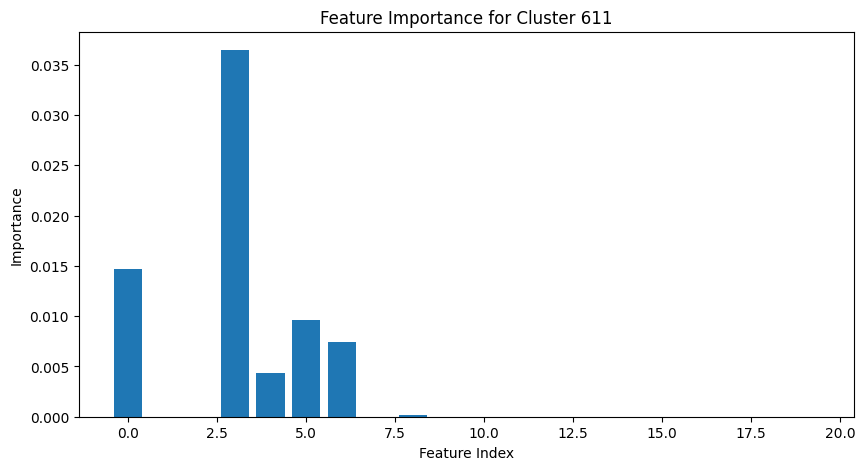

Cluster 612 does not have enough samples for stratified splitting. Skipping...
Cluster 613 does not have enough samples for stratified splitting. Skipping...
Cluster 614 does not have enough samples for stratified splitting. Skipping...
Cluster 615 does not have enough samples for stratified splitting. Skipping...
Cluster 616 does not have enough samples for stratified splitting. Skipping...
Cluster 617 does not have enough samples for stratified splitting. Skipping...
Cluster 618 does not have enough samples for stratified splitting. Skipping...
Cluster 619 does not have enough samples for stratified splitting. Skipping...
Cluster 620 does not have enough samples for stratified splitting. Skipping...
Cluster 621 does not have enough samples for stratified splitting. Skipping...
Cluster 622 does not have enough samples for stratified splitting. Skipping...
Cluster 623 does not have enough samples for stratified splitting. Skipping...
Cluster 624 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

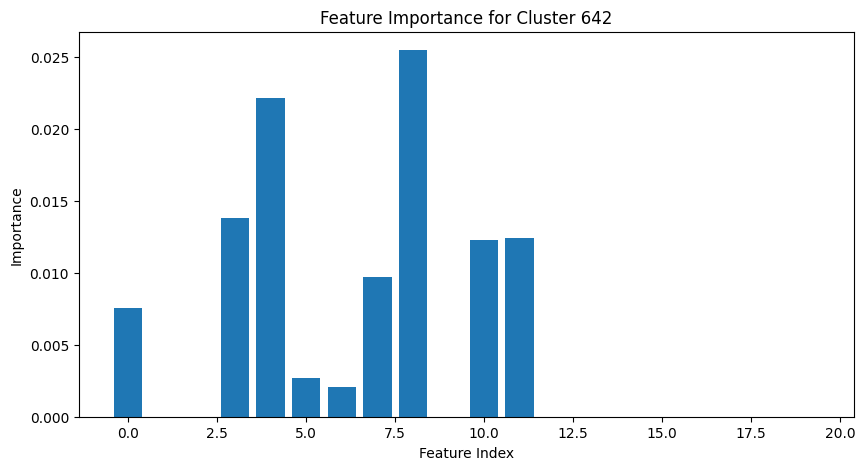

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 643 does not have enough samples for stratified splitting. Skipping...
Cluster 644 does not have enough samples for stratified splitting. Skipping...
Cluster 645 does not have enough samples for stratified splitting. Skipping...
Cluster 646 does not have enough samples for stratified splitting. Skipping...
Cluster 647 does not have enough samples for stratified splitting. Skipping...
Cluster 648 does not have enough samples for stratified splitting. Skipping...
Cluster 649 does not have enough samples for stratified splitting. Skipping...
Cluster 650 does not have enough samples for stratified splitting. Skipping...
Cluster 651 does not have enough samples for stratified splitting. Skipping...
Cluster 652 does not have enough samples for stratified splitting. Skipping...
Cluster 653 does not have enough samples for stratified splitting. Skipping...
Cluster 654 does not have enough samples for stratified splitting. Skipping...
Cluster 655 does not have enough samples for stratif

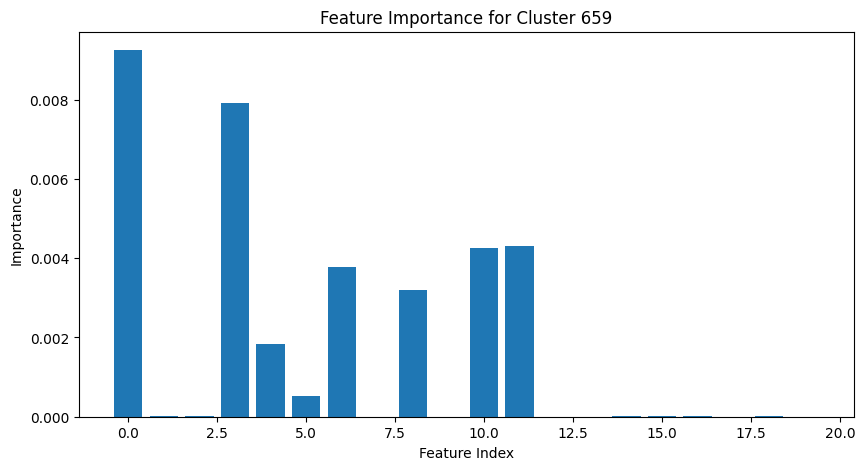

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 660 does not have enough samples for stratified splitting. Skipping...
Cluster 661 does not have enough samples for stratified splitting. Skipping...
Cluster 662 does not have enough samples for stratified splitting. Skipping...
Cluster 663 does not have enough samples for stratified splitting. Skipping...
Cluster 664 does not have enough samples for stratified splitting. Skipping...
Cluster 665 does not have enough samples for stratified splitting. Skipping...
Cluster 666 does not have enough samples for stratified splitting. Skipping...
Cluster 667 does not have enough samples for stratified splitting. Skipping...
Cluster 668 does not have enough samples for stratified splitting. Skipping...
Cluster 669 does not have enough samples for stratified splitting. Skipping...
Cluster 670 does not have enough samples for stratified splitting. Skipping...
Cluster 671 does not have enough samples for stratified splitting. Skipping...
Cluster 672 does not have enough samples for stratif

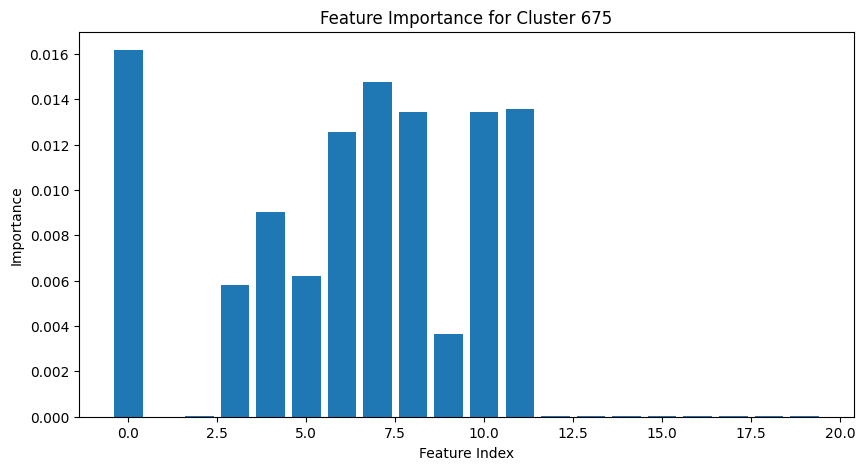

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 676 does not have enough samples for stratified splitting. Skipping...
Cluster 677 does not have enough samples for stratified splitting. Skipping...
Cluster 678 does not have enough samples for stratified splitting. Skipping...
Cluster 679 - Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



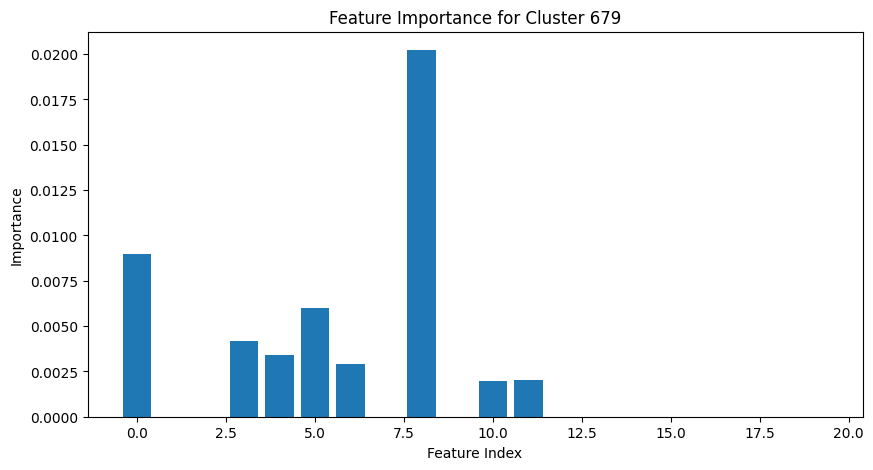

Cluster 680 does not have enough samples for stratified splitting. Skipping...
Cluster 681 does not have enough samples for stratified splitting. Skipping...
Cluster 682 - Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.00      0.00      0.00         2

    accuracy                           0.83        12
   macro avg       0.42      0.50      0.45        12
weighted avg       0.69      0.83      0.76        12



C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

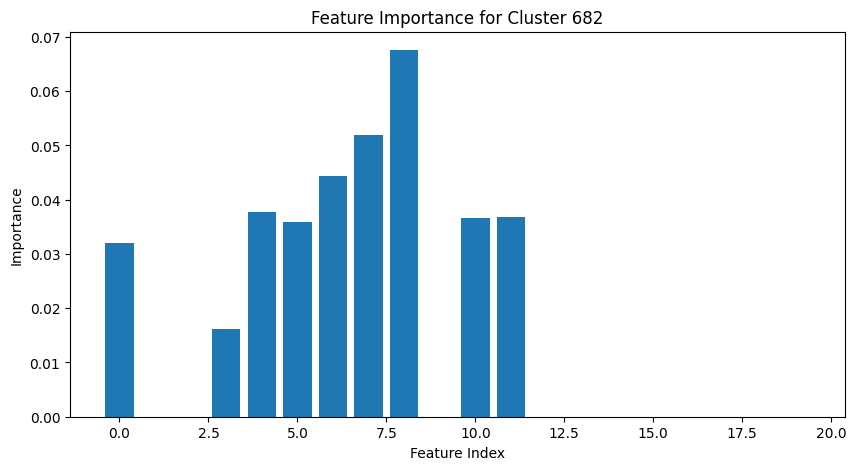

Cluster 683 does not have enough samples for stratified splitting. Skipping...
Cluster 684 does not have enough samples for stratified splitting. Skipping...
Cluster 685 does not have enough samples for stratified splitting. Skipping...
Cluster 686 does not have enough samples for stratified splitting. Skipping...
Cluster 687 does not have enough samples for stratified splitting. Skipping...
Cluster 688 does not have enough samples for stratified splitting. Skipping...
Cluster 689 does not have enough samples for stratified splitting. Skipping...
Cluster 690 does not have enough samples for stratified splitting. Skipping...
Cluster 691 does not have enough samples for stratified splitting. Skipping...
Cluster 692 does not have enough samples for stratified splitting. Skipping...
Cluster 693 does not have enough samples for stratified splitting. Skipping...
Cluster 694 does not have enough samples for stratified splitting. Skipping...
Cluster 695 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

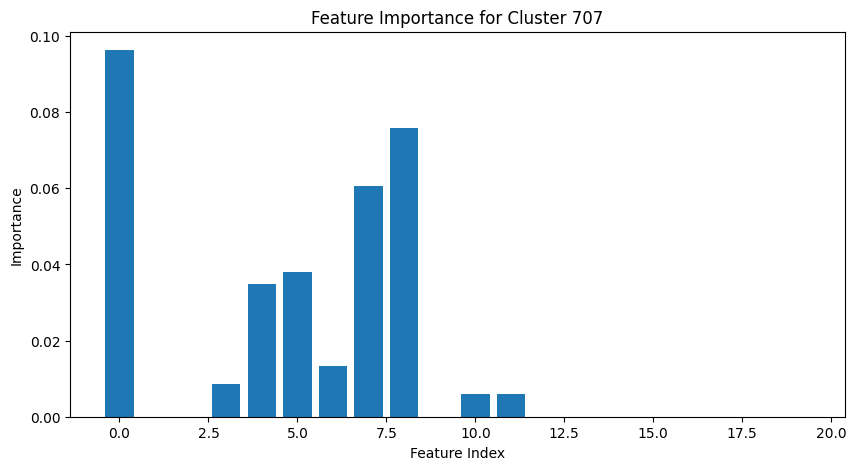

Cluster 708 does not have enough samples for stratified splitting. Skipping...
Cluster 709 does not have enough samples for stratified splitting. Skipping...
Cluster 710 does not have enough samples for stratified splitting. Skipping...
Cluster 711 does not have enough samples for stratified splitting. Skipping...
Cluster 712 does not have enough samples for stratified splitting. Skipping...
Cluster 713 does not have enough samples for stratified splitting. Skipping...
Cluster 714 does not have enough samples for stratified splitting. Skipping...
Cluster 715 does not have enough samples for stratified splitting. Skipping...
Cluster 716 does not have enough samples for stratified splitting. Skipping...
Cluster 717 does not have enough samples for stratified splitting. Skipping...
Cluster 718 does not have enough samples for stratified splitting. Skipping...
Cluster 719 does not have enough samples for stratified splitting. Skipping...
Cluster 720 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

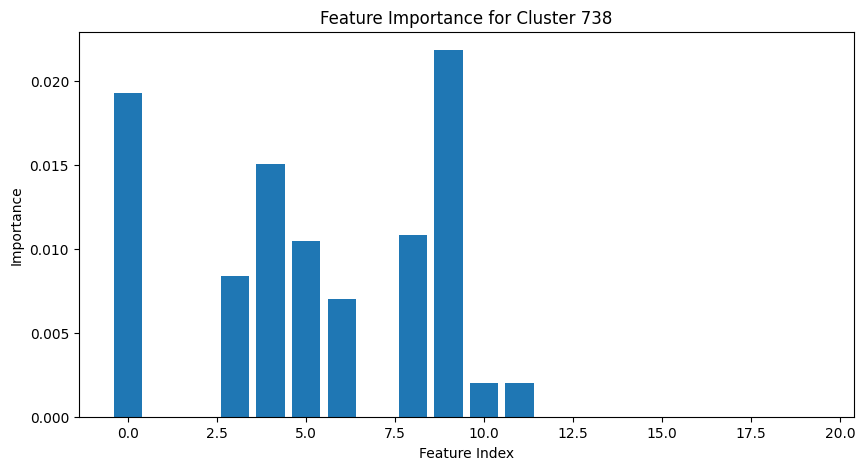

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 739 does not have enough samples for stratified splitting. Skipping...
Cluster 740 does not have enough samples for stratified splitting. Skipping...
Cluster 741 does not have enough samples for stratified splitting. Skipping...
Cluster 742 does not have enough samples for stratified splitting. Skipping...
Cluster 743 does not have enough samples for stratified splitting. Skipping...
Cluster 744 does not have enough samples for stratified splitting. Skipping...
Cluster 745 does not have enough samples for stratified splitting. Skipping...
Cluster 746 does not have enough samples for stratified splitting. Skipping...
Cluster 747 does not have enough samples for stratified splitting. Skipping...
Cluster 748 does not have enough samples for stratified splitting. Skipping...
Cluster 749 does not have enough samples for stratified splitting. Skipping...
Cluster 750 does not have enough samples for stratified splitting. Skipping...
Cluster 751 - Classification Report:
              p

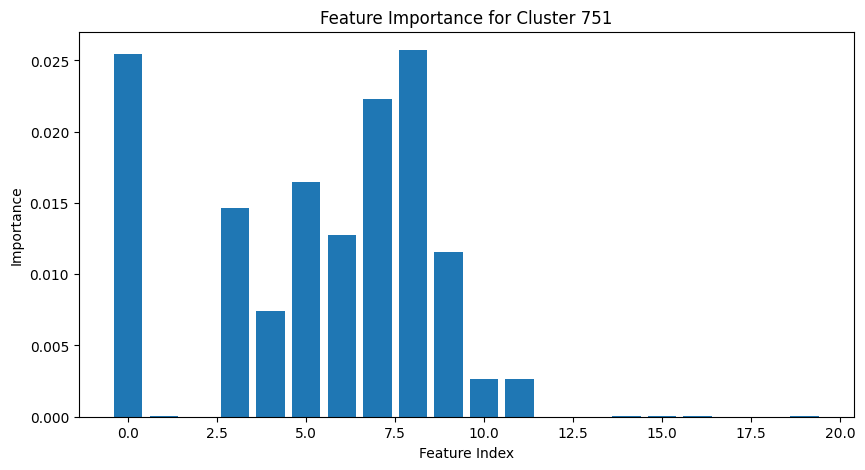

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 752 does not have enough samples for stratified splitting. Skipping...
Cluster 753 does not have enough samples for stratified splitting. Skipping...
Cluster 754 does not have enough samples for stratified splitting. Skipping...
Cluster 755 does not have enough samples for stratified splitting. Skipping...
Cluster 756 does not have enough samples for stratified splitting. Skipping...
Cluster 757 does not have enough samples for stratified splitting. Skipping...
Cluster 758 does not have enough samples for stratified splitting. Skipping...
Cluster 759 does not have enough samples for stratified splitting. Skipping...
Cluster 760 does not have enough samples for stratified splitting. Skipping...
Cluster 761 does not have enough samples for stratified splitting. Skipping...
Cluster 762 does not have enough samples for stratified splitting. Skipping...
Cluster 763 does not have enough samples for stratified splitting. Skipping...
Cluster 764 - Classification Report:
              p

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


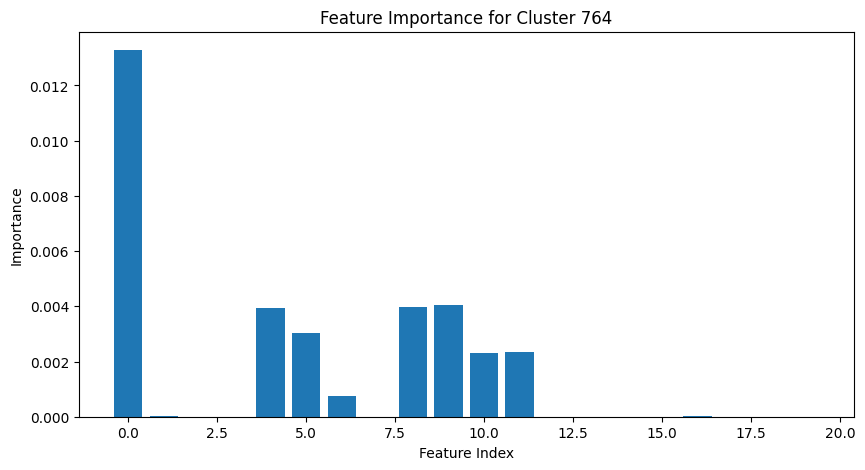

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 765 does not have enough samples for stratified splitting. Skipping...
Cluster 766 does not have enough samples for stratified splitting. Skipping...
Cluster 767 does not have enough samples for stratified splitting. Skipping...
Cluster 768 does not have enough samples for stratified splitting. Skipping...
Cluster 769 does not have enough samples for stratified splitting. Skipping...
Cluster 770 does not have enough samples for stratified splitting. Skipping...
Cluster 771 does not have enough samples for stratified splitting. Skipping...
Cluster 772 does not have enough samples for stratified splitting. Skipping...
Cluster 773 does not have enough samples for stratified splitting. Skipping...
Cluster 774 does not have enough samples for stratified splitting. Skipping...
Cluster 775 does not have enough samples for stratified splitting. Skipping...
Cluster 776 - Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


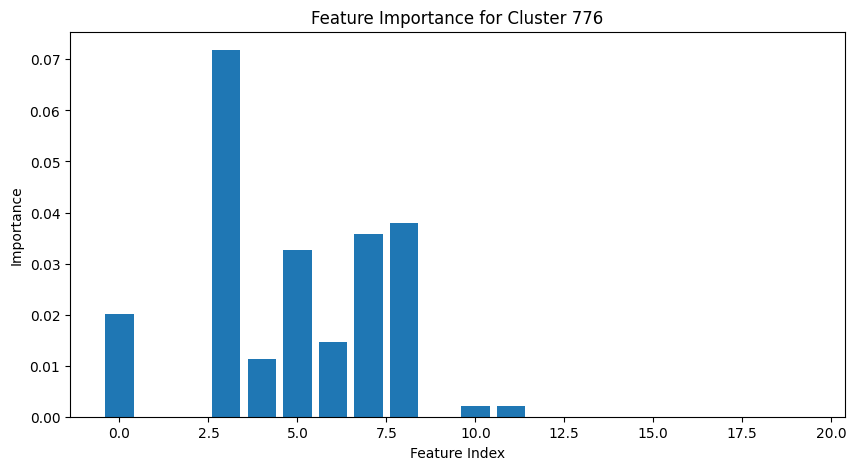

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 777 does not have enough samples for stratified splitting. Skipping...
Cluster 778 does not have enough samples for stratified splitting. Skipping...
Cluster 779 does not have enough samples for stratified splitting. Skipping...
Cluster 780 does not have enough samples for stratified splitting. Skipping...
Cluster 781 does not have enough samples for stratified splitting. Skipping...
Cluster 782 does not have enough samples for stratified splitting. Skipping...
Cluster 783 - Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



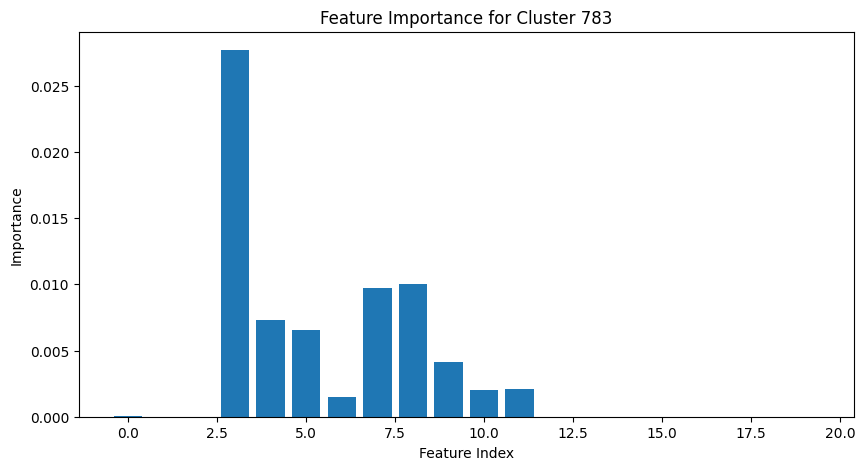

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 784 does not have enough samples for stratified splitting. Skipping...
Cluster 785 does not have enough samples for stratified splitting. Skipping...
Cluster 786 does not have enough samples for stratified splitting. Skipping...
Cluster 787 does not have enough samples for stratified splitting. Skipping...
Cluster 788 does not have enough samples for stratified splitting. Skipping...
Cluster 789 does not have enough samples for stratified splitting. Skipping...
Cluster 790 does not have enough samples for stratified splitting. Skipping...
Cluster 791 does not have enough samples for stratified splitting. Skipping...
Cluster 792 does not have enough samples for stratified splitting. Skipping...
Cluster 793 does not have enough samples for stratified splitting. Skipping...
Cluster 794 - Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       0.00      0.00      0.00         1

    accur

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


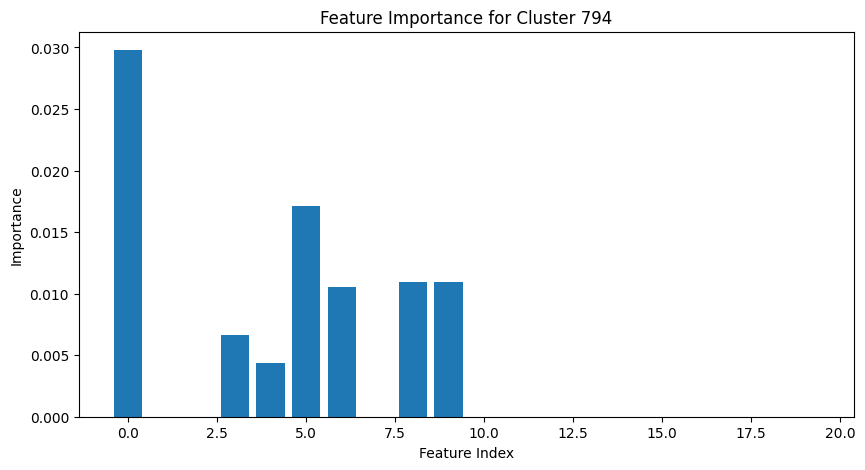

Cluster 795 does not have enough samples for stratified splitting. Skipping...
Cluster 796 does not have enough samples for stratified splitting. Skipping...
Cluster 797 does not have enough samples for stratified splitting. Skipping...
Cluster 798 does not have enough samples for stratified splitting. Skipping...
Cluster 799 does not have enough samples for stratified splitting. Skipping...
Cluster 800 does not have enough samples for stratified splitting. Skipping...
Cluster 801 does not have enough samples for stratified splitting. Skipping...
Cluster 802 does not have enough samples for stratified splitting. Skipping...
Cluster 803 does not have enough samples for stratified splitting. Skipping...
Cluster 804 does not have enough samples for stratified splitting. Skipping...
Cluster 805 does not have enough samples for stratified splitting. Skipping...
Cluster 806 does not have enough samples for stratified splitting. Skipping...
Cluster 807 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

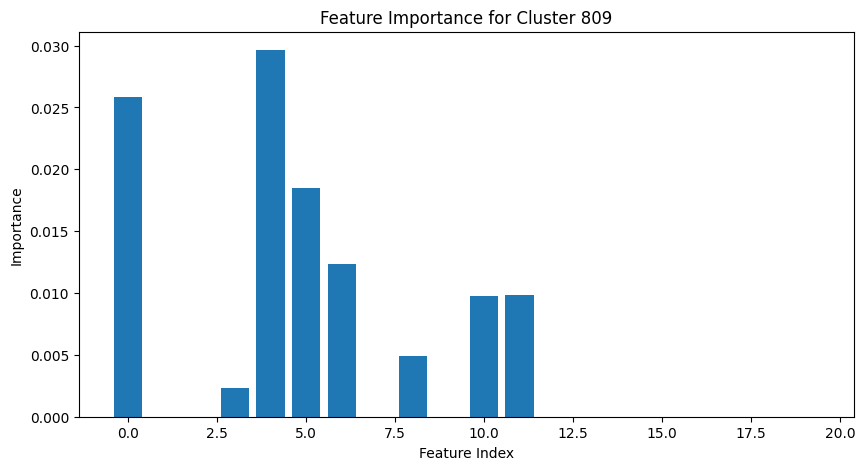

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 810 does not have enough samples for stratified splitting. Skipping...
Cluster 811 does not have enough samples for stratified splitting. Skipping...
Cluster 812 does not have enough samples for stratified splitting. Skipping...
Cluster 813 does not have enough samples for stratified splitting. Skipping...
Cluster 814 does not have enough samples for stratified splitting. Skipping...
Cluster 815 does not have enough samples for stratified splitting. Skipping...
Cluster 816 does not have enough samples for stratified splitting. Skipping...
Cluster 817 does not have enough samples for stratified splitting. Skipping...
Cluster 818 does not have enough samples for stratified splitting. Skipping...
Cluster 819 does not have enough samples for stratified splitting. Skipping...
Cluster 820 does not have enough samples for stratified splitting. Skipping...
Cluster 821 does not have enough samples for stratified splitting. Skipping...
Cluster 822 does not have enough samples for stratif

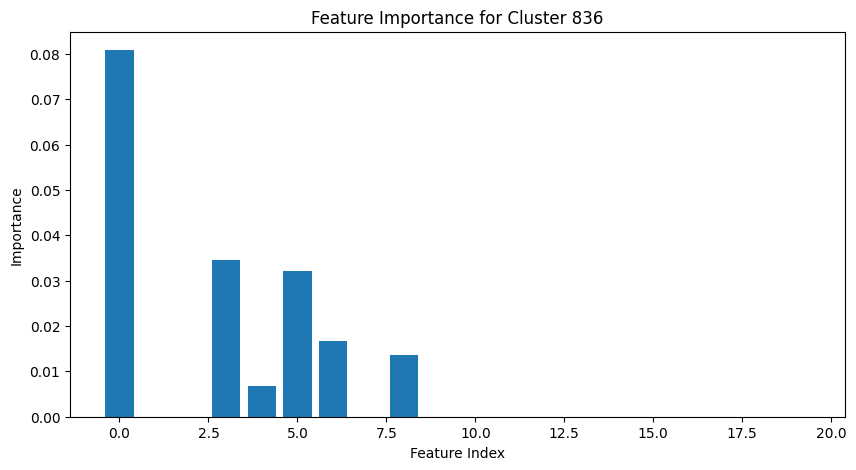

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

Cluster 837 does not have enough samples for stratified splitting. Skipping...
Cluster 838 does not have enough samples for stratified splitting. Skipping...
Cluster 839 does not have enough samples for stratified splitting. Skipping...
Cluster 840 - Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



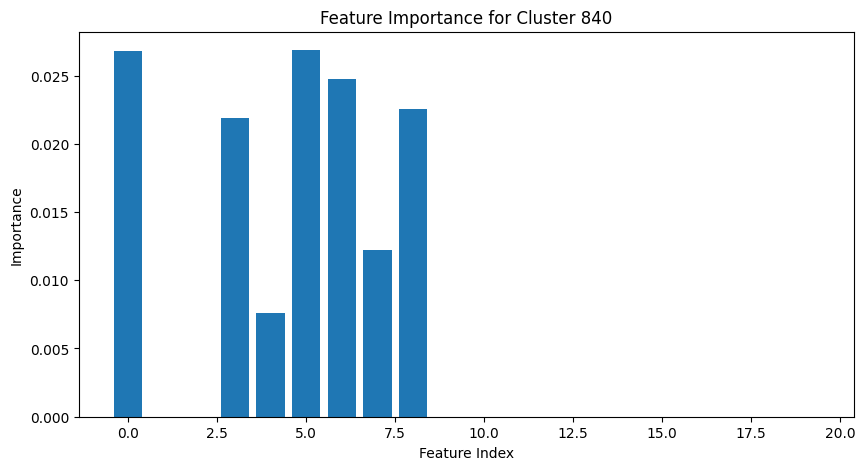

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 841 does not have enough samples for stratified splitting. Skipping...
Cluster 842 does not have enough samples for stratified splitting. Skipping...
Cluster 843 does not have enough samples for stratified splitting. Skipping...
Cluster 844 does not have enough samples for stratified splitting. Skipping...
Cluster 845 does not have enough samples for stratified splitting. Skipping...
Cluster 846 does not have enough samples for stratified splitting. Skipping...
Cluster 847 does not have enough samples for stratified splitting. Skipping...
Cluster 848 does not have enough samples for stratified splitting. Skipping...
Cluster 849 does not have enough samples for stratified splitting. Skipping...
Cluster 850 does not have enough samples for stratified splitting. Skipping...
Cluster 851 does not have enough samples for stratified splitting. Skipping...
Cluster 852 does not have enough samples for stratified splitting. Skipping...
Cluster 853 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


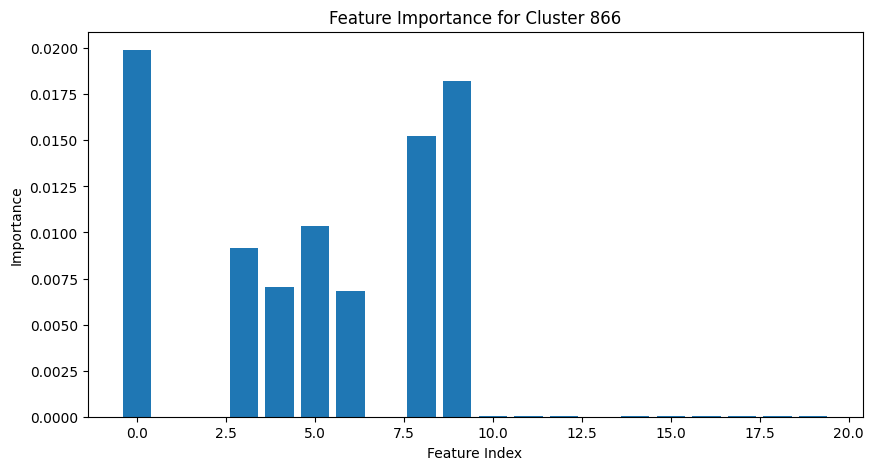

Cluster 867 does not have enough samples for stratified splitting. Skipping...
Cluster 868 does not have enough samples for stratified splitting. Skipping...
Cluster 869 does not have enough samples for stratified splitting. Skipping...
Cluster 870 does not have enough samples for stratified splitting. Skipping...
Cluster 871 does not have enough samples for stratified splitting. Skipping...
Cluster 872 does not have enough samples for stratified splitting. Skipping...
Cluster 873 does not have enough samples for stratified splitting. Skipping...
Cluster 874 does not have enough samples for stratified splitting. Skipping...
Cluster 875 does not have enough samples for stratified splitting. Skipping...
Cluster 876 does not have enough samples for stratified splitting. Skipping...
Cluster 877 does not have enough samples for stratified splitting. Skipping...
Cluster 878 does not have enough samples for stratified splitting. Skipping...
Cluster 879 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

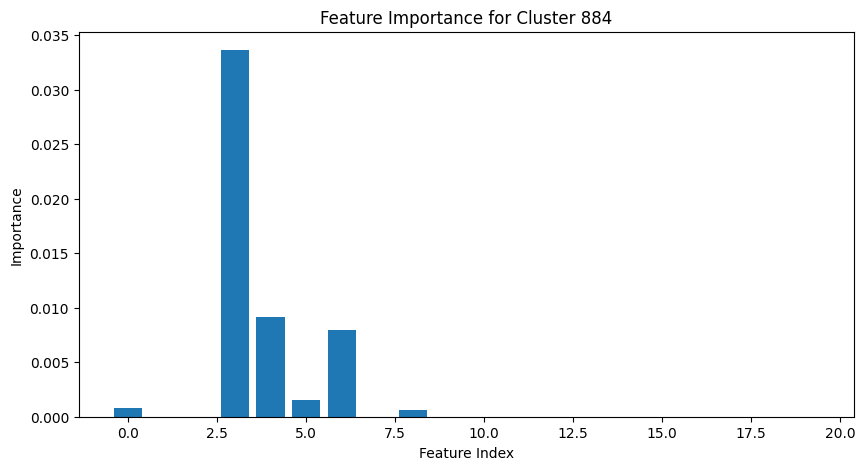

Cluster 885 does not have enough samples for stratified splitting. Skipping...
Cluster 886 does not have enough samples for stratified splitting. Skipping...
Cluster 887 does not have enough samples for stratified splitting. Skipping...
Cluster 888 does not have enough samples for stratified splitting. Skipping...
Cluster 889 does not have enough samples for stratified splitting. Skipping...
Cluster 890 does not have enough samples for stratified splitting. Skipping...
Cluster 891 does not have enough samples for stratified splitting. Skipping...
Cluster 892 does not have enough samples for stratified splitting. Skipping...
Cluster 893 does not have enough samples for stratified splitting. Skipping...
Cluster 894 does not have enough samples for stratified splitting. Skipping...
Cluster 895 - Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accur

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

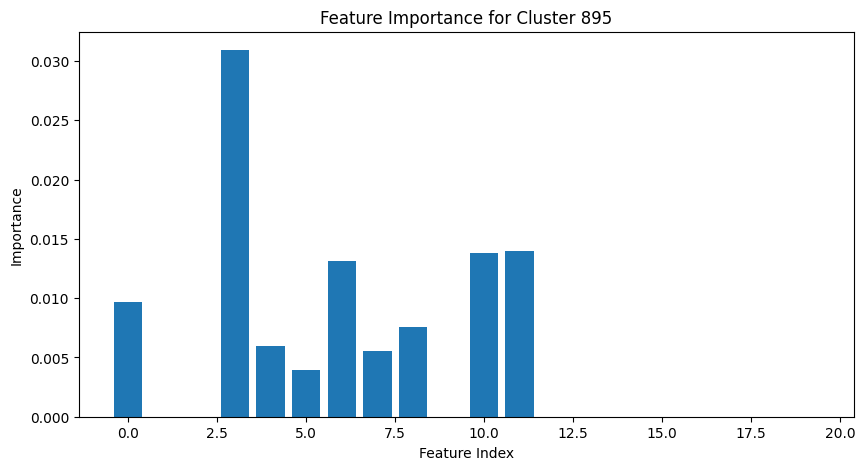

Cluster 896 does not have enough samples for stratified splitting. Skipping...
Cluster 897 does not have enough samples for stratified splitting. Skipping...
Cluster 898 does not have enough samples for stratified splitting. Skipping...
Cluster 899 does not have enough samples for stratified splitting. Skipping...
Cluster 900 does not have enough samples for stratified splitting. Skipping...
Cluster 901 does not have enough samples for stratified splitting. Skipping...
Cluster 902 does not have enough samples for stratified splitting. Skipping...
Cluster 903 does not have enough samples for stratified splitting. Skipping...
Cluster 904 does not have enough samples for stratified splitting. Skipping...
Cluster 905 - Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50 

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

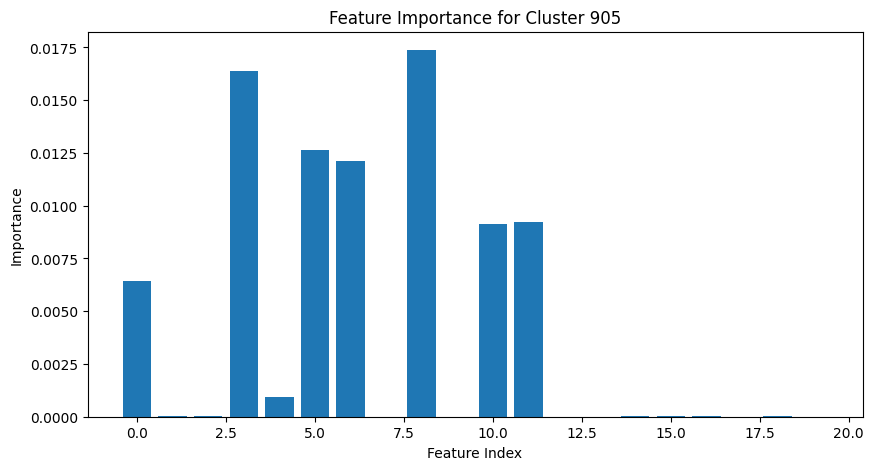

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Cluster 906 does not have enough samples for stratified splitting. Skipping...
Cluster 907 does not have enough samples for stratified splitting. Skipping...
Cluster 908 does not have enough samples for stratified splitting. Skipping...
Cluster 909 does not have enough samples for stratified splitting. Skipping...
Cluster 910 does not have enough samples for stratified splitting. Skipping...
Cluster 911 does not have enough samples for stratified splitting. Skipping...
Cluster 912 does not have enough samples for stratified splitting. Skipping...
Cluster 913 does not have enough samples for stratified splitting. Skipping...
Cluster 914 does not have enough samples for stratified splitting. Skipping...
Cluster 915 does not have enough samples for stratified splitting. Skipping...
Cluster 916 does not have enough samples for stratified splitting. Skipping...
Cluster 917 does not have enough samples for stratified splitting. Skipping...
Cluster 918 does not have enough samples for stratif

C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\OneDrive\Desktop\MTP\MTP_codes\DurgaMTP\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


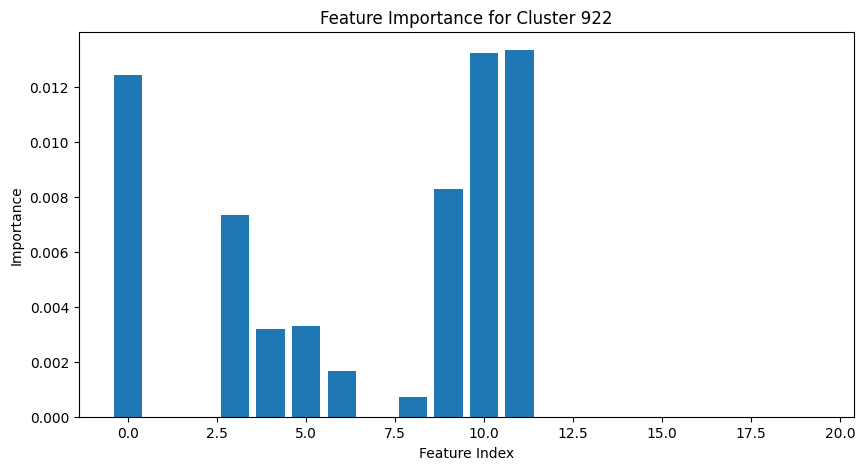

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# Step 8: Additional model evaluation and feature importance analysis
for cluster in np.unique(clusters):
    if cluster == -1:
        continue  # Skip noise points (DBSCAN outliers)

    # Filter data for the current cluster
    X_cluster = X_selected[clusters == cluster]
    y_cluster = y[clusters == cluster]  # Replace `y` with the appropriate target variable

    unique_classes, class_counts = np.unique(y_cluster, return_counts=True)
    if len(unique_classes) < 2 or class_counts.min() < 2:
        print(f"Cluster {cluster} does not have enough samples for stratified splitting. Skipping...")
        continue

    # Split the data into training and testing sets for each cluster
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_cluster,
            y_cluster,
            test_size=0.3,
            random_state=42,
            stratify=y_cluster,
        )
    except ValueError:
        # Use non-stratified splitting as a fallback
        print(
            f"Cluster {cluster} - using non-stratified split due to insufficient class distribution."
        )
        X_train, X_test, y_train, y_test = train_test_split(
            X_cluster, y_cluster, test_size=0.3, random_state=42
        )

    # Train the model
    model = LogisticRegression(max_iter=500, C=0.1, penalty="l2", random_state=42)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Print classification report
    print(f"Cluster {cluster} - Classification Report:")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UndefinedMetricWarning)
        print(classification_report(y_test, y_pred, zero_division=0))

    # Plot feature importance if the model supports it
    if hasattr(model, "coef_"):
        feature_importance = np.abs(model.coef_[0])
        plt.figure(figsize=(10, 5))
        plt.bar(range(len(feature_importance)), feature_importance)
        plt.title(f"Feature Importance for Cluster {cluster}")
        plt.xlabel("Feature Index")
        plt.ylabel("Importance")
        plt.show()



In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Initialize arrays to store the true labels and predictions for all clusters
all_true_labels = []
all_pred_labels = []

# Iterate through each cluster to train the model and make predictions
for cluster in np.unique(clusters):
    if cluster == -1:
        continue  # Skip noise points (DBSCAN outliers)

    # Filter data for the current cluster
    X_cluster = X_selected[clusters == cluster]
    y_cluster = y[clusters == cluster]  # Replace `y` with the appropriate target variable

    unique_classes, class_counts = np.unique(y_cluster, return_counts=True)
    if len(unique_classes) < 2 or class_counts.min() < 2:
        print(f"Cluster {cluster} does not have enough samples for stratified splitting. Skipping...")
        continue

    # Split the data into training and testing sets for each cluster
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_cluster,
            y_cluster,
            test_size=0.3,
            random_state=42,
            stratify=y_cluster,
        )
    except ValueError:
        # Use non-stratified splitting as a fallback
        print(
            f"Cluster {cluster} - using non-stratified split due to insufficient class distribution."
        )
        X_train, X_test, y_train, y_test = train_test_split(
            X_cluster, y_cluster, test_size=0.3, random_state=42
        )

    # Train the model
    model = LogisticRegression(max_iter=500, C=0.1, penalty="l2", random_state=42)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Collect the true labels and predictions
    all_true_labels.extend(y_test)
    all_pred_labels.extend(y_pred)

    # Print individual cluster accuracy (optional)
    print(f"Cluster {cluster} - Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Calculate overall accuracy
overall_accuracy = accuracy_score(all_true_labels, all_pred_labels)
print(f"Overall Accuracy: {overall_accuracy:.4f}")

# Print the overall classification report (optional)
print("Overall Classification Report:")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UndefinedMetricWarning)
    print(classification_report(all_true_labels, all_pred_labels, zero_division=0))


Cluster 0 - Accuracy: 0.9434
Cluster 1 does not have enough samples for stratified splitting. Skipping...
Cluster 2 does not have enough samples for stratified splitting. Skipping...
Cluster 3 - Accuracy: 0.9623
Cluster 4 does not have enough samples for stratified splitting. Skipping...
Cluster 5 does not have enough samples for stratified splitting. Skipping...
Cluster 6 does not have enough samples for stratified splitting. Skipping...
Cluster 7 - Accuracy: 0.6250
Cluster 8 - Accuracy: 0.9139
Cluster 9 does not have enough samples for stratified splitting. Skipping...
Cluster 10 - Accuracy: 0.8704
Cluster 11 does not have enough samples for stratified splitting. Skipping...
Cluster 12 does not have enough samples for stratified splitting. Skipping...
Cluster 13 - Accuracy: 1.0000
Cluster 14 does not have enough samples for stratified splitting. Skipping...
Cluster 15 - Accuracy: 0.9843
Cluster 16 does not have enough samples for stratified splitting. Skipping...
Cluster 17 does not 

Cluster 25 - Accuracy: 0.8529
Cluster 26 - Accuracy: 0.8333
Cluster 27 does not have enough samples for stratified splitting. Skipping...
Cluster 28 - Accuracy: 0.8146
Cluster 29 does not have enough samples for stratified splitting. Skipping...
Cluster 30 - Accuracy: 0.9724
Cluster 31 does not have enough samples for stratified splitting. Skipping...
Cluster 32 - Accuracy: 0.8571
Cluster 33 - Accuracy: 0.9216
Cluster 34 does not have enough samples for stratified splitting. Skipping...
Cluster 35 does not have enough samples for stratified splitting. Skipping...
Cluster 36 does not have enough samples for stratified splitting. Skipping...
Cluster 37 - Accuracy: 0.8000
Cluster 38 does not have enough samples for stratified splitting. Skipping...
Cluster 39 does not have enough samples for stratified splitting. Skipping...
Cluster 40 does not have enough samples for stratified splitting. Skipping...
Cluster 41 does not have enough samples for stratified splitting. Skipping...
Cluster 42

Cluster 75 - Accuracy: 0.9038
Cluster 76 does not have enough samples for stratified splitting. Skipping...
Cluster 77 does not have enough samples for stratified splitting. Skipping...
Cluster 78 does not have enough samples for stratified splitting. Skipping...
Cluster 79 does not have enough samples for stratified splitting. Skipping...
Cluster 80 does not have enough samples for stratified splitting. Skipping...
Cluster 81 does not have enough samples for stratified splitting. Skipping...
Cluster 82 does not have enough samples for stratified splitting. Skipping...
Cluster 83 - Accuracy: 0.9556
Cluster 84 does not have enough samples for stratified splitting. Skipping...
Cluster 85 does not have enough samples for stratified splitting. Skipping...
Cluster 86 - Accuracy: 0.8824
Cluster 87 does not have enough samples for stratified splitting. Skipping...
Cluster 88 - Accuracy: 0.9474
Cluster 89 does not have enough samples for stratified splitting. Skipping...
Cluster 90 does not ha

Cluster 124 - Accuracy: 0.8621
Cluster 125 does not have enough samples for stratified splitting. Skipping...
Cluster 126 does not have enough samples for stratified splitting. Skipping...
Cluster 127 does not have enough samples for stratified splitting. Skipping...
Cluster 128 - Accuracy: 0.7556
Cluster 129 does not have enough samples for stratified splitting. Skipping...
Cluster 130 does not have enough samples for stratified splitting. Skipping...
Cluster 131 does not have enough samples for stratified splitting. Skipping...
Cluster 132 does not have enough samples for stratified splitting. Skipping...
Cluster 133 does not have enough samples for stratified splitting. Skipping...
Cluster 134 does not have enough samples for stratified splitting. Skipping...
Cluster 135 does not have enough samples for stratified splitting. Skipping...
Cluster 136 does not have enough samples for stratified splitting. Skipping...
Cluster 137 does not have enough samples for stratified splitting. Sk

Cluster 205 - Accuracy: 0.8704
Cluster 206 does not have enough samples for stratified splitting. Skipping...
Cluster 207 does not have enough samples for stratified splitting. Skipping...
Cluster 208 does not have enough samples for stratified splitting. Skipping...
Cluster 209 does not have enough samples for stratified splitting. Skipping...
Cluster 210 does not have enough samples for stratified splitting. Skipping...
Cluster 211 does not have enough samples for stratified splitting. Skipping...
Cluster 212 does not have enough samples for stratified splitting. Skipping...
Cluster 213 does not have enough samples for stratified splitting. Skipping...
Cluster 214 does not have enough samples for stratified splitting. Skipping...
Cluster 215 does not have enough samples for stratified splitting. Skipping...
Cluster 216 does not have enough samples for stratified splitting. Skipping...
Cluster 217 does not have enough samples for stratified splitting. Skipping...
Cluster 218 does not 

Cluster 299 does not have enough samples for stratified splitting. Skipping...
Cluster 300 does not have enough samples for stratified splitting. Skipping...
Cluster 301 - Accuracy: 0.7500
Cluster 302 does not have enough samples for stratified splitting. Skipping...
Cluster 303 does not have enough samples for stratified splitting. Skipping...
Cluster 304 does not have enough samples for stratified splitting. Skipping...
Cluster 305 does not have enough samples for stratified splitting. Skipping...
Cluster 306 does not have enough samples for stratified splitting. Skipping...
Cluster 307 does not have enough samples for stratified splitting. Skipping...
Cluster 308 does not have enough samples for stratified splitting. Skipping...
Cluster 309 - Accuracy: 0.9333
Cluster 310 does not have enough samples for stratified splitting. Skipping...
Cluster 311 - Accuracy: 0.8571
Cluster 312 does not have enough samples for stratified splitting. Skipping...
Cluster 313 does not have enough sampl

Cluster 406 does not have enough samples for stratified splitting. Skipping...
Cluster 407 does not have enough samples for stratified splitting. Skipping...
Cluster 408 does not have enough samples for stratified splitting. Skipping...
Cluster 409 does not have enough samples for stratified splitting. Skipping...
Cluster 410 - Accuracy: 0.8571
Cluster 411 does not have enough samples for stratified splitting. Skipping...
Cluster 412 does not have enough samples for stratified splitting. Skipping...
Cluster 413 does not have enough samples for stratified splitting. Skipping...
Cluster 414 does not have enough samples for stratified splitting. Skipping...
Cluster 415 does not have enough samples for stratified splitting. Skipping...
Cluster 416 does not have enough samples for stratified splitting. Skipping...
Cluster 417 does not have enough samples for stratified splitting. Skipping...
Cluster 418 does not have enough samples for stratified splitting. Skipping...
Cluster 419 does not 

Cluster 554 does not have enough samples for stratified splitting. Skipping...
Cluster 555 does not have enough samples for stratified splitting. Skipping...
Cluster 556 - Accuracy: 0.8696
Cluster 557 does not have enough samples for stratified splitting. Skipping...
Cluster 558 does not have enough samples for stratified splitting. Skipping...
Cluster 559 does not have enough samples for stratified splitting. Skipping...
Cluster 560 does not have enough samples for stratified splitting. Skipping...
Cluster 561 does not have enough samples for stratified splitting. Skipping...
Cluster 562 does not have enough samples for stratified splitting. Skipping...
Cluster 563 does not have enough samples for stratified splitting. Skipping...
Cluster 564 does not have enough samples for stratified splitting. Skipping...
Cluster 565 does not have enough samples for stratified splitting. Skipping...
Cluster 566 does not have enough samples for stratified splitting. Skipping...
Cluster 567 does not 

Cluster 675 - Accuracy: 0.7143
Cluster 676 does not have enough samples for stratified splitting. Skipping...
Cluster 677 does not have enough samples for stratified splitting. Skipping...
Cluster 678 does not have enough samples for stratified splitting. Skipping...
Cluster 679 - Accuracy: 0.6667
Cluster 680 does not have enough samples for stratified splitting. Skipping...
Cluster 681 does not have enough samples for stratified splitting. Skipping...
Cluster 682 - Accuracy: 0.8333
Cluster 683 does not have enough samples for stratified splitting. Skipping...
Cluster 684 does not have enough samples for stratified splitting. Skipping...
Cluster 685 does not have enough samples for stratified splitting. Skipping...
Cluster 686 does not have enough samples for stratified splitting. Skipping...
Cluster 687 does not have enough samples for stratified splitting. Skipping...
Cluster 688 does not have enough samples for stratified splitting. Skipping...
Cluster 689 does not have enough sampl

Cluster 826 does not have enough samples for stratified splitting. Skipping...
Cluster 827 does not have enough samples for stratified splitting. Skipping...
Cluster 828 does not have enough samples for stratified splitting. Skipping...
Cluster 829 does not have enough samples for stratified splitting. Skipping...
Cluster 830 does not have enough samples for stratified splitting. Skipping...
Cluster 831 does not have enough samples for stratified splitting. Skipping...
Cluster 832 does not have enough samples for stratified splitting. Skipping...
Cluster 833 does not have enough samples for stratified splitting. Skipping...
Cluster 834 does not have enough samples for stratified splitting. Skipping...
Cluster 835 does not have enough samples for stratified splitting. Skipping...
Cluster 836 - Accuracy: 0.8571
Cluster 837 does not have enough samples for stratified splitting. Skipping...
Cluster 838 does not have enough samples for stratified splitting. Skipping...
Cluster 839 does not 